
# Paper figures — the adiabatic boundary term

Figures 1–6 of the $O(1)$-gradient-deviation study (`QEP_GPT-12.pdf`).

**Division of labour.** This notebook holds only *light* data generation and the plotting.
Anything that solves a Schrödinger equation lives in a script:

| Figure | data | plotted here |
|---|---|---|
| 1 — the two schedules, and $B_{10}(\tau)$ | generated in-notebook (analytic curves + $2\times2$ `eigh`, no evolution) | yes |
| 2 — prep fidelity vs $T$ | `code/run_boundary.py prep_fid_vs_T` → `data/bd_prep_fid_vs_T.npz` | yes |
| 3 — parameter gradient vs $T$ | `code/run_boundary.py grad_vs_T` → `data/bd_grad_vs_T.npz` | yes |
| 4 — the `parametrized_ascend` family vs $\lambda$ | generated in-notebook (analytic + autodiff, no evolution) | yes |
| 5 — parameter gradient vs $T$, across $\lambda$ (central difference) | `code/run_boundary.py grad_vs_T_lam` → `data/bd_grad_vs_T_lam.npz` | yes |
| 6 — the same, with the **real QEP** gradient | `code/run_boundary.py qep_grad_vs_T_lam` → `data/bd_qep_grad_vs_T_lam.npz` | yes |

Figures 1–3 contrast the two schedules that the note itself uses, where the criterion is $f'(0)$.
Figures 4–5 go one derivative further: the `parametrized_ascend` family keeps $f'(0)=f'(1)=0$ for
every $\lambda$ and tunes the boundary *curvature* $f''(0)=\lambda$ instead, so every member
converges while $\lambda$ sets the residual $\sim\lambda/T$. Figure 6 then swaps the finite-difference
estimator for the real QEP two-phase gradient, which adds a $T$-independent $O(\beta)$ floor.

| 13 — training trajectories over $T\times$schedule | generated in-cell, **cached** (`data/train_multi_init_paths_TS.npz`); twin: `code/train_experiments.py multi_init_paths_TS` | yes |

| 14-15 — training with fewer probe fields | generated in-cell, **cached** (`data/train_probe_sets_TS.npz`); twin: `code/train_experiments.py probe_sets_TS` | yes |

| 16 — probe-set trajectories, stiff schedule | reuses `data/train_probe_sets_TS.npz` | yes |
| 17 — average cost vs epoch (own probe set) | computed in-cell (~5 s); twin: `code/train_experiments.py probe_sets_costs` | yes |

To regenerate the data: `cd code && PYTHONPATH=. python -u run_boundary.py all` (~2 min).
`code/draw_boundary_figs.py` is the scripted twin of the plot cells below.

**The claim.** After one integration by parts the first-order adiabatic amplitude is a pure
*boundary* term,

$$a^{(1)}_n(1)\;\sim\;-i\hbar\Big[B_{n0}(1)\,e^{iT(\gamma_n-\gamma_0)}-B_{n0}(0)\Big],
\qquad
B_{n0}(\tau)=\frac{\langle\phi_n|\partial_\tau H|\phi_0\rangle}{(E_0-E_n)^2},$$

so everything hinges on $\partial_\tau H$ **at the endpoints**. For this project's ramp

$$H(\tau)=-\big[A_0+(A-A_0)f(\tau)\big]\sigma^z-\big[B_0+(B-B_0)f(\tau)\big]\sigma^x
\;\;\Longrightarrow\;\;
\partial_\tau H=-f'(\tau)\big[(A-A_0)\sigma^z+(B-B_0)\sigma^x\big],$$

the boundary coefficient is **exactly proportional to the schedule slope** $f'(\tau)$.

Figure 2 measures the **state** error, which decays for either schedule. Figure 3 measures the
**gradient**, where the stiff schedule keeps an $O(1)$ bias that never decays — because
$\partial_\theta$ hits the dynamical phase $e^{-iT\gamma}$ and pulls out a factor $T$.
Throughout: $f_x=0$, start $(A_0,B_0)=(1,0)$, end $(A,B)=(0.8,1.5)$.


## Setup

In [27]:

# Run this first.
import os, sys
import numpy as np
import jax, jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt

# resolve paths whether the notebook is run from H_detecting/ or from H_detecting/code/
HERE = os.getcwd()
ROOT = HERE if os.path.isdir(os.path.join(HERE, "data")) else os.path.dirname(HERE)
CODE, DATA, FIG = (os.path.join(ROOT, d) for d in ("code", "data", "figures"))
os.makedirs(FIG, exist_ok=True)
if CODE not in sys.path:
    sys.path.insert(0, CODE)
import qep                                     # ramp / A0 / B0, and the Figure 13 training run

mpl.rcParams.update({"font.size": 15, "axes.labelsize": 16, "axes.titlesize": 14,
                     "legend.fontsize": 11, "xtick.labelsize": 13, "ytick.labelsize": 13,
                     "lines.linewidth": 2.0, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3})

# Two series throughout: stiff / smooth. Separated by colour AND dash pattern, so identity never
# rests on colour alone. The pair passes the categorical CVD checks (OKLab dE 20.4 protan,
# 28.6 normal vision, both >= 3:1 on a light surface).
C     = {"linear": "#C0392B", "smooth": "#1F6FB2"}
DASH  = {"linear": (0, (5, 2)), "smooth": "-"}
NAME  = {"linear": r"stiff  $f(x)=x$", "smooth": r"smooth  $f(x)=\frac{1}{2}(1-\cos\pi x)$"}
SHORT = {"linear": "stiff", "smooth": "smooth"}
INK, MUTED = "#1a1a19", "0.45"
SCHEDS = ("linear", "smooth")                  # = networks.ascend_func_st, networks.ascend_func

P = np.array([0.8, 1.5])                       # the (A,B) the ramp ends at (= the study target h)

def L(n):
    """Load a driver-produced dataset from data/."""
    return np.load(os.path.join(DATA, n + ".npz"))

def save(fig, n):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIG, n + "." + ext))
    print("saved figures/" + n)

def local_slope(T, y, ratio=1.6):
    """d log y / d log T from a sliding fit over a window of constant width in log T.

    A plain finite difference is useless here: dT=0.25 against T~100 makes d log T ~ 2e-3, so the
    envelope's residual ripple swamps the derivative. Evaluated only where the window fits fully
    inside the sampled range (NaN elsewhere, so nothing is drawn from a truncated fit).
    """
    lt, ly, r = np.log(T), np.log(y), np.sqrt(ratio)
    out = np.full(T.shape, np.nan)
    for i, t in enumerate(T):
        if t / r < T[0] or t * r > T[-1]:
            continue
        m = (T >= t / r) & (T <= t * r)
        if m.sum() >= 8:
            out[i] = np.polyfit(lt[m], ly[m], 1)[0]
    return out

print("root:", ROOT)


root: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/H_detecting



## Figure 1 — the two schedules, and the boundary coefficient they produce

`ascend_func` and `ascend_func_st` of `../networks.py`, bit-identical to `qep.ramp(x, "smooth")`
and `qep.ramp(x, "linear")`. Panel 3 is the actual object of Eq. (34) of the note,
$|B_{10}(\tau)|$, along the ramp.

This is the one figure whose data is generated here: analytic curves plus a $2\times2$ `eigh` at
each $\tau$ — no time evolution, so it costs nothing.


In [28]:

# --- Figure 1: generate the (simple) data --------------------------------------------------
SZ_N = np.array([[1, 0], [0, -1]], float)      # plain-numpy Paulis
SX_N = np.array([[0, 1], [1, 0]], float)

x = np.linspace(0.0, 1.0, 1001)
f1 = {"x": x}
for s in SCHEDS:
    f1[f"f_{s}"] = np.array(qep.ramp(jnp.asarray(x), s))

# analytic slopes (jnp.clip inside qep.ramp makes autodiff unreliable exactly at x=0,1)
f1["df_linear"] = np.ones_like(x)
f1["df_smooth"] = 0.5 * np.pi * np.sin(np.pi * x)

# ...but verify them against autodiff of the shipped qep.ramp on the interior
for s in SCHEDS:
    xi = jnp.linspace(0.02, 0.98, 97)
    ad = np.array(jax.vmap(jax.grad(lambda z: qep.ramp(z, s)))(xi))
    err = float(np.max(np.abs(ad - np.interp(np.array(xi), x, f1[f"df_{s}"]))))
    assert err < 1e-9, (s, err)
    print(f"{s:6s}: max|autodiff f' - analytic f'| = {err:.2e}")

# boundary coefficient  B_10(tau) = <phi_1|d_tau H|phi_0> / (E_0-E_1)^2  along the ramp
dA, dB = P[0] - qep.A0, P[1] - qep.B0
for s in SCHEDS:
    lam = np.array(qep.ramp(jnp.asarray(x), s))
    A, B = qep.A0 + dA * lam, qep.B0 + dB * lam
    Bc = np.empty_like(x)
    for i in range(len(x)):
        dtH = -f1[f"df_{s}"][i] * (dA * SZ_N + dB * SX_N)
        w, v = np.linalg.eigh(-A[i] * SZ_N - B[i] * SX_N)
        Bc[i] = abs(v[:, 1].conj() @ dtH @ v[:, 0]) / (w[0] - w[1]) ** 2
    f1[f"B10_{s}"] = Bc
    print(f"{s:6s}: |B_10(0)| = {Bc[0]:.4f},  |B_10(1)| = {Bc[-1]:.4f}")


linear: max|autodiff f' - analytic f'| = 0.00e+00
smooth: max|autodiff f' - analytic f'| = 5.27e-16
linear: |B_10(0)| = 0.3750,  |B_10(1)| = 0.0763
smooth: |B_10(0)| = 0.0000,  |B_10(1)| = 0.0000


saved figures/bd_schedule_shapes


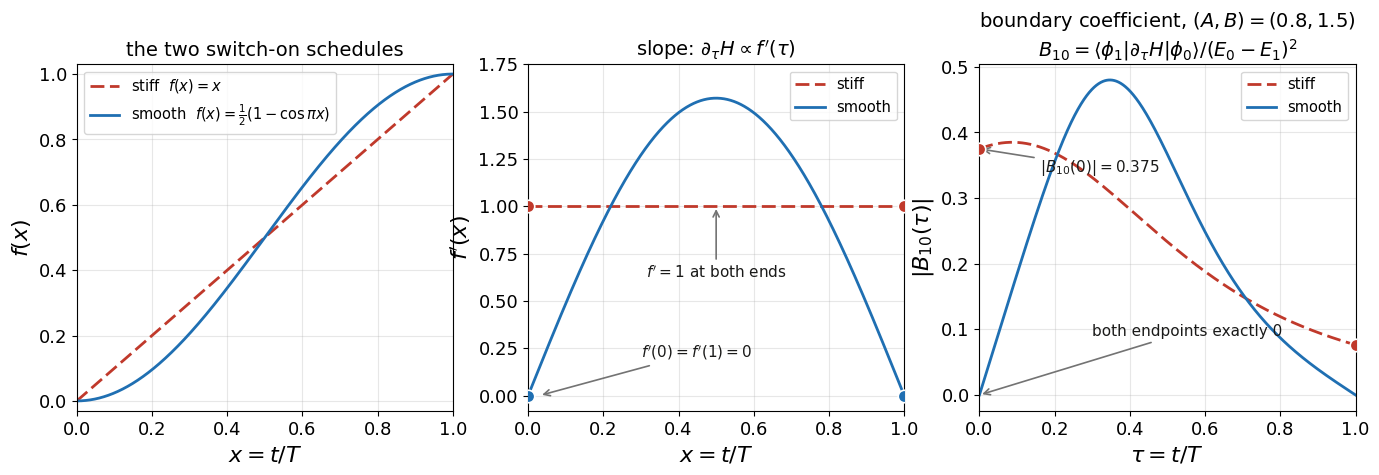

In [29]:

# --- Figure 1: plot ------------------------------------------------------------------------
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16.5, 4.5))

for s in SCHEDS:
    a1.plot(x, f1[f"f_{s}"], color=C[s], ls=DASH[s], label=NAME[s])
a1.set_xlabel(r"$x=t/T$"); a1.set_ylabel(r"$f(x)$")
a1.set_title("the two switch-on schedules")
a1.legend(loc="upper left", fontsize=10.5); a1.set_xlim(0, 1); a1.set_ylim(-0.03, 1.03)

for s in SCHEDS:
    a2.plot(x, f1[f"df_{s}"], color=C[s], ls=DASH[s], label=SHORT[s])
    a2.plot([0, 1], [f1[f"df_{s}"][0], f1[f"df_{s}"][-1]], "o", color=C[s], ms=9,
            mec="w", mew=1.2, zorder=5)
a2.annotate(r"$f'=1$ at both ends", (0.5, 1.0), xytext=(0.5, 0.62), ha="center",
            color=INK, fontsize=11, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
a2.annotate(r"$f'(0)=f'(1)=0$", (0.03, 0.0), xytext=(0.30, 0.20),
            color=INK, fontsize=11, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
a2.set_xlabel(r"$x=t/T$"); a2.set_ylabel(r"$f'(x)$")
a2.set_title(r"slope: $\partial_\tau H \propto f'(\tau)$")
a2.legend(loc="upper right", fontsize=10.5); a2.set_xlim(0, 1); a2.set_ylim(-0.08, 1.75)

for s in SCHEDS:
    a3.plot(x, f1[f"B10_{s}"], color=C[s], ls=DASH[s], label=SHORT[s])
a3.plot([0, 1], [f1["B10_linear"][0], f1["B10_linear"][-1]], "o", color=C["linear"],
        ms=9, mec="w", mew=1.2, zorder=5)
a3.annotate(r"$|B_{10}(0)|=%.3f$" % f1["B10_linear"][0], (0.0, f1["B10_linear"][0]),
            xytext=(0.16, 0.34), color=INK, fontsize=11,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
a3.annotate("both endpoints exactly 0", (0.0, 0.0), xytext=(0.30, 0.09),
            color=INK, fontsize=11, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
a3.set_xlabel(r"$\tau=t/T$"); a3.set_ylabel(r"$|B_{10}(\tau)|$")
a3.set_title(r"boundary coefficient, $(A,B)=(%.1f,%.1f)$" % (P[0], P[1]) + "\n"
             + r"$B_{10}=\langle\phi_1|\partial_\tau H|\phi_0\rangle/(E_0-E_1)^2$")
a3.legend(loc="upper right", fontsize=10.5); a3.set_xlim(0, 1)

save(fig, "bd_schedule_shapes")



## Figure 2 — the bias it leaves on the prepared ground state

Data: `code/run_boundary.py prep_fid_vs_T` → `data/bd_prep_fid_vs_T.npz`. It evolves one qubit
from $H(0)=-\sigma^z$ to $(A,B)=(0.8,1.5)$ with $f_x=0$ on a dense grid ($dT=0.25$, $T=3\ldots160$)
and overlaps the final state with the exact ground state of $-A\sigma^z-B\sigma^x$.

Prediction: $|a^{(1)}|/T$ is the excited admixture, so $1-F=|a^{(1)}|^2/T^2$ gives
$1-F\sim T^{-2}$ for stiff (the $B_{n0}(0)\ne0$ term survives) and $1-F\sim T^{-4}$ for smooth
(the whole boundary term cancels, so the next order takes over) — Campos Venuti–Lidar boundary
cancellation, i.e. §4.4 of the note at $N=1$.

Two numerical requirements, both in the driver: **`tol=1e-13`**, not the study-wide `1e-9` (the
smooth $T^{-4}$ curve reaches $1.4\times10^{-9}$ by $T=160$, where a `1e-9` solver reports
$7.6\times10^{-8}$ — 53× too large — and the exponent flattens to $\approx-2$); and a **dense,
linearly spaced** $T$ grid, since the period is $\approx2.5$ and log spacing aliases it.


linear: exponent on T>=20: -2.002   oscillation period 2.553 predicted, 2.551 measured
smooth: exponent on T>=20: -4.004   oscillation period 2.492 predicted, 2.495 measured
saved figures/bd_prep_fid_vs_T


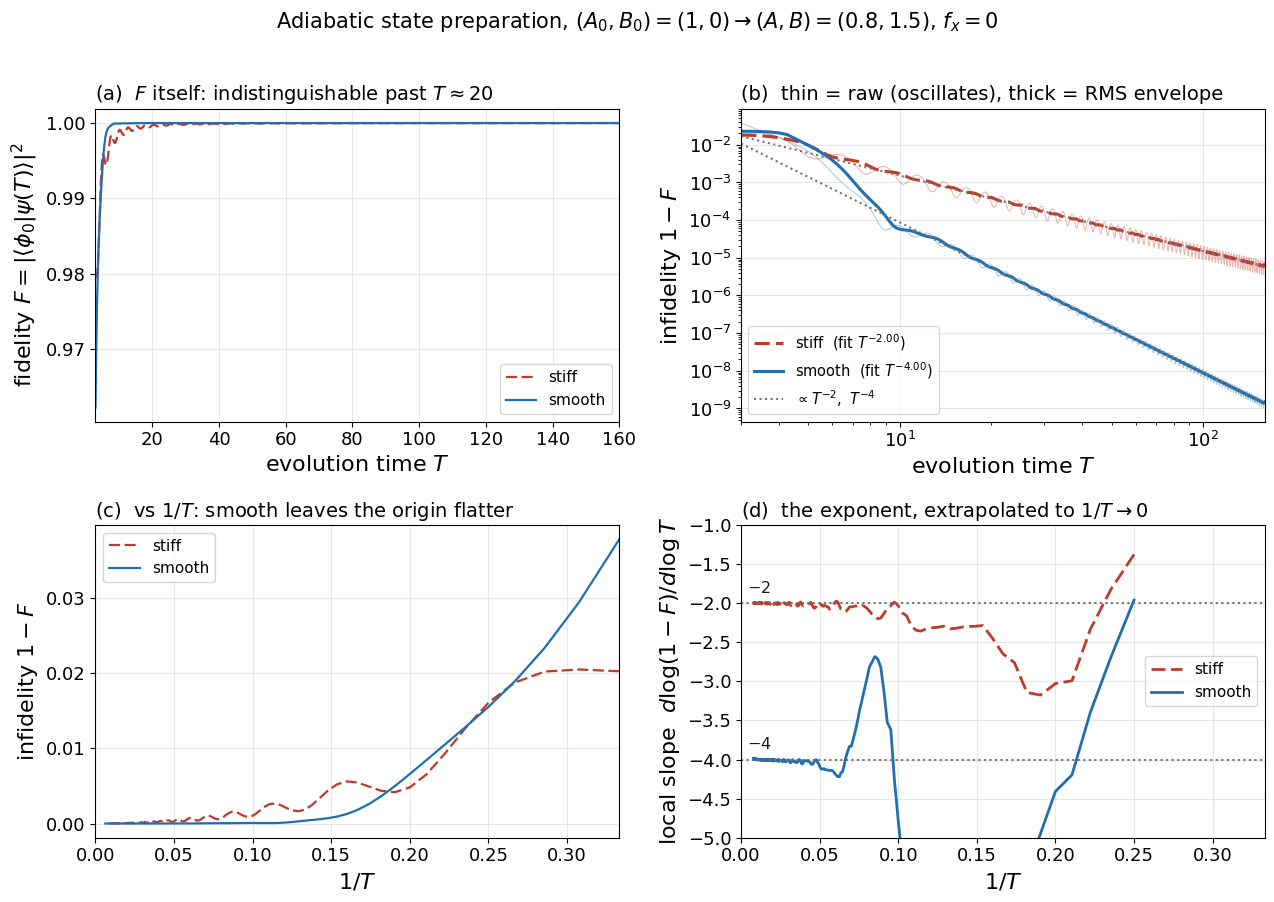

In [30]:

# --- Figure 2: plot (data from run_boundary.py) --------------------------------------------
d2 = L("bd_prep_fid_vs_T")
T = d2["T"]; p2 = d2["points"][0]; s0 = d2["start"]
for s in SCHEDS:
    print(f"{s:6s}: exponent on T>={float(d2['fit_Tmin']):g}: {float(d2[f'slope_{s}_p0']):+.3f}"
          f"   oscillation period {float(d2[f'period_{s}_p0']):.3f} predicted,"
          f" {float(d2[f'period_meas_{s}_p0']):.3f} measured")

fig, ((a1, a2), (a3, a4)) = plt.subplots(2, 2, figsize=(13.0, 9.0))

# (a) the fidelity itself -- and why it is not enough
for s in SCHEDS:
    a1.plot(T, 1.0 - d2[f"inf_{s}_p0"], color=C[s], ls=DASH[s], lw=1.6, label=SHORT[s])
a1.set_xlabel(r"evolution time $T$")
a1.set_ylabel(r"fidelity $F=|\langle\phi_0|\psi(T)\rangle|^2$")
a1.set_title(r"(a)  $F$ itself: indistinguishable past $T\approx20$", loc="left")
a1.legend(loc="lower right", fontsize=11); a1.set_xlim(T[0], T[-1])

# (b) infidelity vs T, log-log: raw + RMS envelope + power-law guides
for s in SCHEDS:
    a2.loglog(T, d2[f"inf_{s}_p0"], color=C[s], lw=0.8, alpha=0.35)
    a2.loglog(T, d2[f"env_{s}_p0"], color=C[s], ls=DASH[s], lw=2.2,
              label=r"%s  (fit $T^{%+.2f}$)" % (SHORT[s], d2[f"slope_{s}_p0"]))
for s, n in (("linear", 2.0), ("smooth", 4.0)):
    k = np.argmin(np.abs(T - 40.0))
    a2.loglog(T, d2[f"env_{s}_p0"][k] * (T / T[k]) ** (-n), color=MUTED, ls=":", lw=1.5,
              label=(r"$\propto T^{-2},\ T^{-4}$" if n == 2 else None))
a2.set_xlabel(r"evolution time $T$"); a2.set_ylabel(r"infidelity $1-F$")
a2.set_title("(b)  thin = raw (oscillates), thick = RMS envelope", loc="left")
a2.legend(loc="lower left", fontsize=10.5); a2.set_xlim(T[0], T[-1])

# (c) the same data against 1/T -- the T->infinity limit is the origin
for s in SCHEDS:
    a3.plot(1.0 / T, d2[f"inf_{s}_p0"], color=C[s], ls=DASH[s], lw=1.6, label=SHORT[s])
a3.set_xlabel(r"$1/T$"); a3.set_ylabel(r"infidelity $1-F$")
a3.set_title(r"(c)  vs $1/T$: smooth leaves the origin flatter", loc="left")
a3.legend(loc="upper left", fontsize=11); a3.set_xlim(0.0, 1.0 / T[0])

# (d) local exponent of the envelope -> -2 vs -4 as 1/T -> 0
for s in SCHEDS:
    a4.plot(1.0 / T, local_slope(T, d2[f"env_{s}_p0"]), color=C[s], ls=DASH[s], lw=2.0,
            label=SHORT[s])
for n in (-2.0, -4.0):
    a4.axhline(n, color=MUTED, ls=":", lw=1.5)
    a4.text(0.004, n + 0.13, r"$%d$" % n, color=INK, fontsize=11.5, ha="left")
a4.set_xlabel(r"$1/T$"); a4.set_ylabel(r"local slope  $d\log(1-F)/d\log T$")
a4.set_title(r"(d)  the exponent, extrapolated to $1/T\to0$", loc="left")
a4.legend(loc="center right", fontsize=11)
a4.set_xlim(0.0, 1.0 / T[0]); a4.set_ylim(-5.0, -1.0)

fig.suptitle(r"Adiabatic state preparation, $(A_0,B_0)=(%.0f,%.0f)\to(A,B)=(%.1f,%.1f)$, $f_x=0$"
             % (s0[0], s0[1], p2[0], p2[1]), fontsize=15, y=1.005)
fig.tight_layout()
save(fig, "bd_prep_fid_vs_T")



## Figure 3 — the parameter gradient vs $T$

Data: `code/run_boundary.py grad_vs_T` → `data/bd_grad_vs_T.npz`. Same model, same
$(A,B)=(0.8,1.5)$, same $f_x=0$; the driver differentiates the output
$y=\langle\sigma^z\rangle$ with respect to the parameters by central difference — the note's own
estimator ("the difference of $\langle\sigma^z\rangle$ between $\theta-\Delta\theta$ and
$\theta+\Delta\theta$"). The exact ground state gives a closed form to compare against:

$$y_{\rm ex}=\frac{A}{\sqrt{A^2+B^2}}
\quad\Longrightarrow\quad
\frac{\partial y}{\partial A}=\frac{B^2}{R^3},\qquad
\frac{\partial y}{\partial B}=-\frac{AB}{R^3},\qquad R=\sqrt{A^2+B^2}.$$

**This is where the $O(1)$ claim bites.** Eq. (33) of the note gives the deviation as

$$2\,\mathrm{Re}\sum_{n\neq0}\hbar\big(\partial_\theta\gamma_n-\partial_\theta\gamma_0\big)
B_{n0}(0,\theta)\,e^{-iT(\gamma_n-\gamma_0)}\,O_{i,n0}(1,\theta),$$

which is $O(1)$ and **oscillates in $T$ without decaying** whenever $B_{n0}(0)\neq0$ — because
$\partial_\theta$ hits the dynamical phase $e^{-iT\gamma}$ and pulls out a factor $T$ that cancels
the $1/T$ of the amplitude. Contrast Figure 2, where the *state* error decayed for both schedules.


exact grad: analytic [ 0.45796865 -0.24424995]  central-diff [ 0.45796865 -0.24424995]
stiff : envelope T^-0.001   mean rel deviation on T>=20: 0.8789   period 2.553 predicted, 2.551 measured
smooth: envelope T^-1.001   mean rel deviation on T>=20: 0.0322   period 2.492 predicted, 2.495 measured
saved figures/bd_grad_vs_T


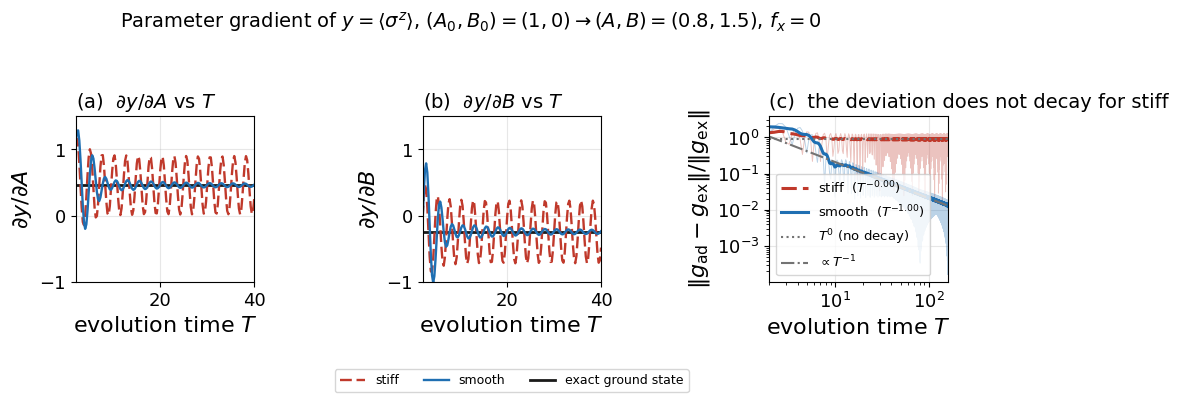

In [31]:
# --- Figure 3: plot (data from run_boundary.py) --------------------------------------------
# Written out one curve at a time rather than looping over the schedules: there are exactly two
# series and each panel styles them individually, so an explicit call per curve is what you edit.
d3 = L("bd_grad_vs_T")
TG   = d3["T"]
gex  = d3["g_exact"]
p3   = d3["p"]
s0   = d3["start"]
tmin = float(d3["fit_Tmin"])
m    = TG >= tmin

g_stiff    = d3["grad_linear"]
g_smooth   = d3["grad_smooth"]
dev_stiff  = d3["dev_linear"]
dev_smooth = d3["dev_smooth"]
env_stiff  = d3["env_linear"]
env_smooth = d3["env_smooth"]
sl_stiff   = float(d3["slope_linear"])
sl_smooth  = float(d3["slope_smooth"])

print("exact grad: analytic", np.round(gex, 8), " central-diff", np.round(d3["g_exact_numeric"], 8))
print(f"stiff : envelope T^{sl_stiff:+.3f}   mean rel deviation on T>={tmin:g}:"
      f" {env_stiff[m].mean():.4f}   period {float(d3['period_linear']):.3f} predicted,"
      f" {float(d3['period_meas_linear']):.3f} measured")
print(f"smooth: envelope T^{sl_smooth:+.3f}   mean rel deviation on T>={tmin:g}:"
      f" {env_smooth[m].mean():.4f}   period {float(d3['period_smooth']):.3f} predicted,"
      f" {float(d3['period_meas_smooth']):.3f} measured")

TW = 40.0                                      # window for the value panels

# Legend position of panel (b), as an (x, y) pair in AXES coordinates: (0, 0) is the panel's
# bottom-left corner, (1, 1) its top-right. `loc` below names which corner of the legend BOX is
# pinned to this point -- with loc="lower center" the pair is where the legend's bottom-centre
# goes. So raise y to lift it, change x to slide it sideways; values outside [0, 1] put it
# outside the axes (e.g. (0.5, -0.30) hangs it under the x-axis label).
# The a2.set_ylim below only exists to clear space for the DEFAULT position -- drop it if you
# move the legend out of the data.
LEG_B_XY = (0.5, 0.02)
w  = TG <= TW
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(10, 6.0))

# (a) dy/dA
a1.plot(TG[w], g_stiff[w, 0], color=C["linear"], ls=DASH["linear"], lw=1.7, label=NAME["linear"])
a1.plot(TG[w], g_smooth[w, 0], color=C["smooth"], ls=DASH["smooth"], lw=1.7, label=NAME["smooth"])
a1.axhline(gex[0], color=INK, lw=2.0, zorder=1, label="exact ground state")
a1.set_xlabel(r"evolution time $T$"); a1.set_ylabel(r"$\partial y/\partial A$")
a1.set_title(r"(a)  $\partial y/\partial A$ vs $T$", loc="left")
a1.set_xlim(TG[0], TW); #a1.legend(fontsize=9.5, loc="best")
a1.set_ylim(-1, 1.5)

# (b) dy/dB
a2.plot(TG[w], g_stiff[w, 1], color=C["linear"], ls=DASH["linear"], lw=1.7, label=SHORT["linear"])
a2.plot(TG[w], g_smooth[w, 1], color=C["smooth"], ls=DASH["smooth"], lw=1.7, label=SHORT["smooth"])
a2.axhline(gex[1], color=INK, lw=2.0, zorder=1, label="exact ground state")
a2.set_xlabel(r"evolution time $T$"); a2.set_ylabel(r"$\partial y/\partial B$")
a2.set_title(r"(b)  $\partial y/\partial B$ vs $T$", loc="left")
a2.set_ylim(-1, 1.5)                       # room for the one-row legend
a2.set_xlim(TG[0], TW)
a2.legend(fontsize=9, ncol=3, loc="lower center", bbox_to_anchor=(0.5,-0.7))

# (c) relative deviation: raw (thin) + RMS envelope (thick)
a3.loglog(TG, dev_stiff, color=C["linear"], lw=0.7, alpha=0.3)
a3.loglog(TG, dev_smooth, color=C["smooth"], lw=0.7, alpha=0.3)
a3.loglog(TG, env_stiff, color=C["linear"], ls=DASH["linear"], lw=2.2,
          label=r"stiff  ($T^{%+.2f}$)" % sl_stiff)
a3.loglog(TG, env_smooth, color=C["smooth"], ls=DASH["smooth"], lw=2.2,
          label=r"smooth  ($T^{%+.2f}$)" % sl_smooth)
a3.axhline(env_stiff[m].mean(), color=MUTED, ls=":", lw=1.5, label=r"$T^{0}$ (no decay)")
k = int(np.argmin(np.abs(TG - 40.0)))
a3.loglog(TG, env_smooth[k] * (TG / TG[k]) ** -1.0, color=MUTED, ls="-.", lw=1.5,
          label=r"$\propto T^{-1}$")
a3.set_xlabel(r"evolution time $T$")
a3.set_ylabel(r"$\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$")
a3.set_title("(c)  the deviation does not decay for stiff", loc="left")
a3.legend(fontsize=9.5, loc="lower left"); a3.set_xlim(TG[0], TG[-1])

fig.suptitle(r"Parameter gradient of $y=\langle\sigma^z\rangle$, "
             r"$(A_0,B_0)=(%.0f,%.0f)\to(A,B)=(%.1f,%.1f)$, $f_x=0$"
             % (s0[0], s0[1], p3[0], p3[1]), fontsize=14, y=1.02)
fig.tight_layout()
save(fig, "bd_grad_vs_T")


## Figure 4 — the `parametrized_ascend` family: what $\lambda$ changes

Figures 1–3 compare exactly two schedules, and the criterion separating them is $f'(0)$. This
family interpolates *inside* the smooth class: it holds $f_\lambda'(0)=f_\lambda'(1)=0$ for
**every** $\lambda$ — so $B_{n0}(0)=B_{n0}(1)=0$ always and the $O(1)$ term of Eq. (33) is
cancelled throughout — while making the boundary *curvature* exactly $f_\lambda''(0)=+\lambda$,
$f_\lambda''(1)=-\lambda$. With

$$B_\lambda(x)=\frac{(1-e^{-\lambda x})(1-e^{-\lambda(1-x)})}{1-e^{-\lambda}},\qquad
I_\lambda=\int_0^1\!B_\lambda=\coth\frac{\lambda}{2}-\frac{2}{\lambda},$$

$$f_\lambda(x)=H_\lambda(x)+(1-I_\lambda)\,S(x),\qquad
H_\lambda(x)=\int_0^x\!B_\lambda,\qquad S(x)=10x^3-15x^4+6x^5 .$$

Two limits anchor the family, and both matter for reading Figure 5:

* $\lambda\to\infty$ gives the **linear** ramp $f(x)=x$ — the stiff schedule of Figures 1–3.
* $\lambda\to0$ gives the **quintic smoothstep** $S(x)$, since $B_\lambda\to\lambda x(1-x)\to0$
  and $I_\lambda\to\lambda/6\to0$. That is *not* an abrupt function: $S$ has $S'=S''=0$ at both
  ends, and the peak interior slope only rises from $\pi/2=1.571$ (the standard ramp) to
  $\max S'=15/8=1.875$ before saturating. So squeezing the boundary flat does steepen the
  interior, but by a bounded $19\%$.

The standard ramp $\tfrac12(1-\cos\pi x)$ has $f''(0)=\pi^2/2\approx4.93$, so it is essentially
this family's $\lambda\approx5$ member. Rather than rely on that, the cosine ramp is plotted as
its own series (thick black) in Figures 4–6 alongside $\lambda=0.1,0.5,1,5,20,100$ and the stiff
ramp, so how closely it tracks $\lambda=5$ can be read off directly.

No evolution here, so this cell costs nothing.


lam=   0.10: f(1)=1.000000  f'(0)=0.0e+00  f''(0)=0.10000  max f'=1.86875
lam=   0.50: f(1)=1.000000  f'(0)=0.0e+00  f''(0)=0.50000  max f'=1.84375
lam=   1.00: f(1)=1.000000  f'(0)=0.0e+00  f''(0)=1.00000  max f'=1.81251
lam=   5.00: f(1)=1.000000  f'(0)=-2.2e-16  f''(0)=5.00000  max f'=1.57284
lam=  20.00: f(1)=1.000000  f'(0)=0.0e+00  f''(0)=20.00000  max f'=1.18741
lam= 100.00: f(1)=1.000000  f'(0)=0.0e+00  f''(0)=100.00000  max f'=1.03750

cosine ramp: f''(0) = pi^2/2 = 4.93480, max f' = pi/2 = 1.57080   |  max S' = 1.875
max|f_(lam=0.1) - S(x)| = 8.94e-04   (the lambda->0 limit)
max|f_(lam=5)  - cos ramp| = 1.96e-04   (lam=5 ~ pi^2/2)
saved figures/fig_lam_schedules


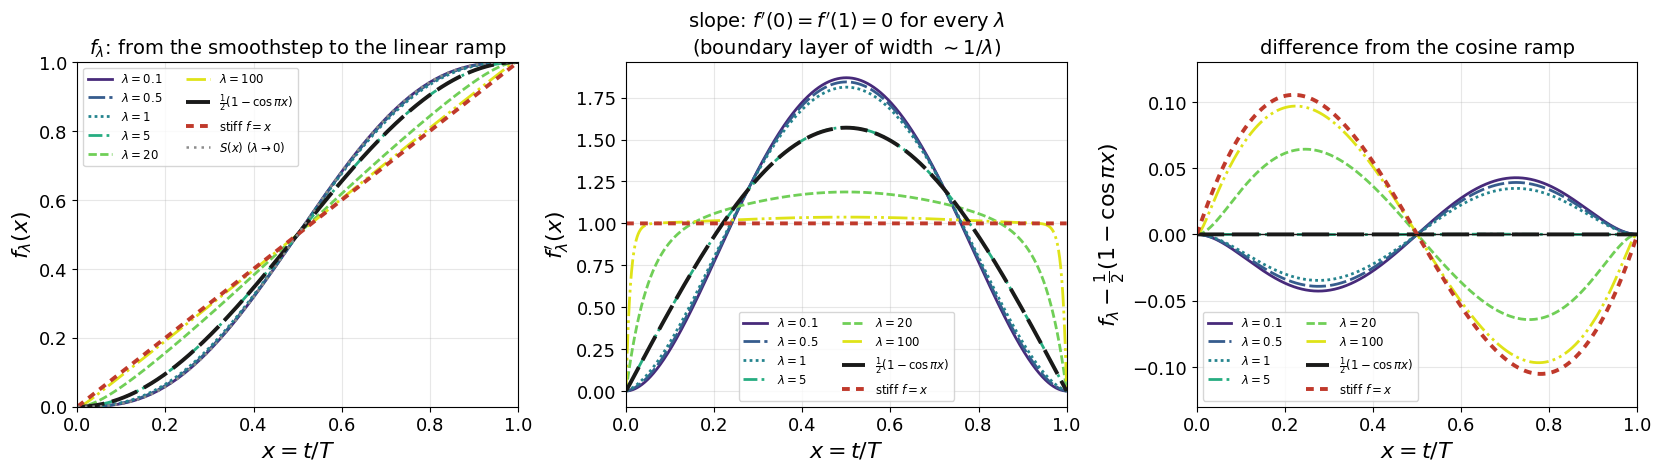

In [32]:
# --- Figures 4-6: shared schedule set, palette and curve-drawer ------------------------------
# Eight series throughout: the six lambda members, then the two schedules the note itself uses.
LAM_SET = (0.1, 0.5, 1.0, 5.0, 20.0, 100.0)

# lambda is an ORDERED variable, so it gets a sequential map; the dash pattern is a redundant
# encoding alongside colour. The two reference schedules are deliberately NOT the notebook's
# usual smooth=blue: against a 6-member viridis family, blue lands on the low-lambda end -- which
# is exactly where the cosine ramp has to stay readable, since it IS essentially the lambda~4.93
# member. They get ink and red instead, drawn thicker, so they read as references either way.
LC = [mpl.colors.to_hex(c) for c in plt.cm.viridis(np.linspace(0.12, 0.95, len(LAM_SET)))]
LD = ["-", (0, (6, 1.5)), (0, (1, 1.2)), (0, (5, 1.5, 1, 1.5)), (0, (3, 1.2)),
      (0, (7, 1.5, 1, 1.5, 1, 1.5))]
LLAB = [r"$\lambda=%g$" % l for l in LAM_SET]
CREF = {"smooth": INK, "linear": C["linear"]}
DREF = {"smooth": (0, (7, 2)), "linear": (0, (2, 1.6))}

def series_items():
    """(tag, colour, dash, linewidth, label) for all eight curves, in a fixed order."""
    it = [(f"lam{j}", LC[j], LD[j], 1.6, LLAB[j]) for j in range(len(LAM_SET))]
    it += [("smooth", CREF["smooth"], DREF["smooth"], 2.8, r"$f_{cos}$"),
           ("linear", CREF["linear"], DREF["linear"], 2.8, r"stiff $f=x$")]
    return it

def draw_series(d, ax, kind, comp=None, zmask=None, labeller=None):
    """Plot all eight series on `ax`. kind='value' -> gradient component `comp` vs T over `zmask`;
    kind='env' -> the decay envelope on log-log. Exponents go in the legend label."""
    for tag, col, ds, lw, text in series_items():
        lab = labeller(tag, text) if labeller else \
              text + r"  ($T^{%+.2f}$)" % float(d[f"slope_{tag}"])
        if kind == "value":
            ax.plot(d["T"][zmask], d[f"grad_{tag}"][zmask, comp], color=col, ls=ds, lw=lw,
                    label=lab)
        else:
            ax.loglog(d["T"], d[f"env_{tag}"], color=col, ls=ds, lw=lw, label=lab)

# --- Figure 4: the schedule family itself (no evolution) ------------------------------------
xg = np.linspace(0.0, 1.0, 1201)
Sq = 10 * xg ** 3 - 15 * xg ** 4 + 6 * xg ** 5      # the lambda -> 0 limit
cosr = 0.5 * (1 - np.cos(np.pi * xg))               # the cosine ramp
f4 = {}
for j, l in enumerate(LAM_SET):
    f4[f"f{j}"] = np.array(qep.parametrized_ascend(jnp.asarray(xg), float(l)))
    f4[f"d{j}"] = np.array(jax.vmap(jax.grad(
        lambda z, ll=float(l): qep.parametrized_ascend(z, ll)))(jnp.asarray(xg)))
    d2 = float(jax.grad(jax.grad(
        lambda z, ll=float(l): qep.parametrized_ascend(z, ll)))(0.0))
    print(f"lam={l:7.2f}: f(1)={f4[f'f{j}'][-1]:.6f}  f'(0)={f4[f'd{j}'][0]:.1e}"
          f"  f''(0)={d2:.5f}  max f'={f4[f'd{j}'].max():.5f}")
print(f"\ncosine ramp: f''(0) = pi^2/2 = {np.pi**2/2:.5f}, max f' = pi/2 = {np.pi/2:.5f}"
      f"   |  max S' = 1.875")
print(f"max|f_(lam=0.1) - S(x)| = {np.max(np.abs(f4['f0'] - Sq)):.2e}   (the lambda->0 limit)")
print(f"max|f_(lam=5)  - cos ramp| = {np.max(np.abs(f4['f3'] - cosr)):.2e}   (lam=5 ~ pi^2/2)")

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16.5, 4.6), layout="constrained")
for j in range(len(LAM_SET)):
    a1.plot(xg, f4[f"f{j}"], color=LC[j], ls=LD[j], label=LLAB[j])
    a2.plot(xg, f4[f"d{j}"], color=LC[j], ls=LD[j], label=LLAB[j])
    a3.plot(xg, f4[f"f{j}"] - cosr, color=LC[j], ls=LD[j], label=LLAB[j])
for ax, yc, yl in ((a1, cosr, xg),
                   (a2, 0.5 * np.pi * np.sin(np.pi * xg), np.ones_like(xg)),
                   (a3, np.zeros_like(xg), xg - cosr)):
    ax.plot(xg, yc, color=CREF["smooth"], ls=DREF["smooth"], lw=2.8,
            label=r"$\frac{1}{2}(1-\cos\pi x)$")
    ax.plot(xg, yl, color=CREF["linear"], ls=DREF["linear"], lw=2.8, label=r"stiff $f=x$")
a1.plot(xg, Sq, color="0.55", ls=(0, (1, 2)), lw=1.8, label=r"$S(x)$ ($\lambda\to0$)")
a1.set_xlabel(r"$x=t/T$"); a1.set_ylabel(r"$f_\lambda(x)$")
a1.set_title(r"$f_\lambda$: from the smoothstep to the linear ramp")
a1.legend(loc="upper left", fontsize=8.5, ncol=2); a1.set_xlim(0, 1); a1.set_ylim(0, 1)
a2.set_xlabel(r"$x=t/T$"); a2.set_ylabel(r"$f_\lambda'(x)$")
a2.set_title(r"slope: $f'(0)=f'(1)=0$ for every $\lambda$" "\n"
             r"(boundary layer of width $\sim1/\lambda$)")
a2.legend(loc="lower center", fontsize=8.5, ncol=2); a2.set_xlim(0, 1)
a3.axhline(0.0, color=INK, lw=1.0)
a3.set_xlabel(r"$x=t/T$"); a3.set_ylabel(r"$f_\lambda-\frac{1}{2}(1-\cos\pi x)$")
a3.set_title("difference from the cosine ramp")
a3.legend(loc="lower left", fontsize=8.5, ncol=2)
a3.set_xlim(0, 1); a3.set_ylim(-0.13, 0.13)

save(fig, "fig_lam_schedules")


## Figure 5 — Figure 1(b) of the note, repeated across $\lambda$

Data: `code/run_boundary.py grad_vs_T_lam` → `data/bd_grad_vs_T_lam.npz`. Identical to Figure 3 in
model, estimator and tolerance — $(A,B)=(0.8,1.5)$, $f_x=0$, central difference of
$y=\langle\sigma^z\rangle$, `tol=1e-13`, $dT=0.25$ — with the two schedules joined by six
members of the $f_\lambda$ family ($\lambda=0.1,0.5,1,5,20,100$); the cosine and stiff ramps are
kept as references, the latter being the one that does *not* converge.

**Why the gradient of the output, not of a cost.** At $(A,B)=(0.8,1.5)$ the model *is* the study
target $h$, so $y=y_\tau$, the error signal $\varepsilon=y-y_\tau$ vanishes and the QEP **cost**
gradient is identically zero. The non-degenerate object — and the one the note's Fig. 1(b) actually
plots — is $\partial_\theta\langle\sigma^z\rangle$, with the closed form

$$\frac{\partial y}{\partial A}=\frac{B^2}{R^3}=0.45797,\qquad
\frac{\partial y}{\partial B}=-\frac{AB}{R^3}=-0.24425,\qquad R=\sqrt{A^2+B^2}=1.7 .$$

**What to expect.** Every $\lambda$ has $f'(0)=0$, so the $O(1)$ boundary term is cancelled and
every curve must converge; only the stiff reference should not. What $\lambda$ sets is the
*residual*: the leading survivor is $\propto f''(0)/T=\lambda/T$, so a larger $\lambda$ means a
larger oscillation at the same $T$, crossing over to stiff behaviour once $\lambda\gtrsim T$.
Panels (a)–(b) are a zoomed **linear** window, because the oscillation period ($\approx2.49$ here)
is two orders of magnitude shorter than the decay scale and no single axis shows both; panel (c)
carries the full range as an envelope.

### How the envelope in panel (c) is defined

The raw deviation oscillates in $T$ at fixed amplitude-times-power-law, so the *trend* lives in its
amplitude, not in its value at any single $T$: a single-$T$ reading can land on a node and be
arbitrarily small. Panel (c) therefore plots a **rolling RMS over one oscillation period**. Both
steps are in `code/run_boundary.py` (`envelope()` and `dgamma()`); nothing is fitted here.

**1. The pointwise relative deviation.** With $g_{\rm ad}(T)$ the central-difference gradient and
$g_{\rm ex}$ the analytic exact-ground-state value, both 2-vectors in $(A,B)$,

$${\rm dev}(T)=\frac{\lVert g_{\rm ad}(T)-g_{\rm ex}\rVert_2}{\lVert g_{\rm ex}\rVert_2}.$$

This is the thin, rapidly oscillating quantity; it is what panel (c) smooths.

**2. The window width — one dynamical-phase period, computed not guessed.** The surviving boundary
term of Eq. (33) carries $e^{-iT(\gamma_1-\gamma_0)}$, so ${\rm dev}$ oscillates in $T$ with period
$2\pi/\Delta\gamma$, where $\Delta\gamma$ is the dimensionless phase accumulated over the ramp,

$$\Delta\gamma=\int_0^1\!\big(E_1-E_0\big)\,d\tau=\int_0^1\! 2\sqrt{A(\tau)^2+B(\tau)^2}\;d\tau,
\qquad
\begin{aligned}A(\tau)&=A_0+(A-A_0)f_\lambda(\tau)\\ B(\tau)&=B_0+(B-B_0)f_\lambda(\tau)\end{aligned}$$

evaluated by `dgamma()` on a $2\times10^5$-point trapezoid. It depends (weakly) on the schedule, so
it is recomputed per series: $\Delta\gamma=2.462\ldots2.544$ over $\lambda=100\to0.3$, i.e. period
$2.55\ldots2.47$, which at $dT=0.25$ gives a window of

$$w=\text{round}\!\left(\frac{2\pi/\Delta\gamma}{dT}\right)\ \to\ \textbf{11 samples}$$

for every curve ($w$ is forced odd and $\ge3$ so the window is centred). *Independent check:* the
measured spacing of the maxima of the **signed** component deviation is $2.4909$ against the
predicted $2.4919$ — 0.04%. (The window is sized by the *phase* period; $\lVert\cdot\rVert$ makes
${\rm dev}$ rectified, so its own period is half that and the window spans about two of its
oscillations.)

**3. The rolling RMS.** With $m=(w-1)/2$,

$${\rm env}(T_i)=\sqrt{\frac{1}{w}\sum_{k=-m}^{m}{\rm dev}(T_{i+k})^2},$$

implemented as a convolution of ${\rm dev}^2$ with a length-$w$ boxcar; the array is
reflection-padded so the window stays full width at both ends rather than shrinking there.

**Two things to keep in mind when reading the exponents.** For a pure sinusoid of amplitude $a$ the
RMS over a full period is $a/\sqrt2$, so the envelope sits a constant $0.707$ below the peak
amplitude — it tracks the amplitude faithfully and the *fitted power law is unaffected*, but the
absolute level is not the peak. And RMS is used rather than peak-detection because it needs no
maxima-finding and degrades gracefully where the oscillation is not yet clean (small $T$). The
$T^{\pm}$ exponents quoted in the legend are least-squares fits of $\log{\rm env}$ against
$\log T$ over $T\ge20$ (`fit_Tmin`), i.e. on the envelope, never on the raw curve.


exact grad: [ 0.45796865 -0.24424995]   (fx = 0.0 , tol = 1e-13 )
$\lambda=0.1$               : dev 1.322e+00 (T=2) -> 5.923e-04 (T=160);  envelope T^-1.940
$\lambda=0.5$               : dev 1.323e+00 (T=2) -> 1.928e-03 (T=160);  envelope T^-1.442
$\lambda=1$                 : dev 1.324e+00 (T=2) -> 3.271e-03 (T=160);  envelope T^-1.182
$\lambda=5$                 : dev 1.329e+00 (T=2) -> 1.845e-02 (T=160);  envelope T^-1.000
$\lambda=20$                : dev 1.326e+00 (T=2) -> 6.368e-02 (T=160);  envelope T^-0.962
$\lambda=100$               : dev 1.309e+00 (T=2) -> 2.510e-01 (T=160);  envelope T^-0.615
$f_{cos}$                   : dev 1.329e+00 (T=2) -> 1.819e-02 (T=160);  envelope T^-1.001
stiff $f=x$                 : dev 1.301e+00 (T=2) -> 5.155e-01 (T=160);  envelope T^-0.001
saved figures/fig_lam_grad_vs_T


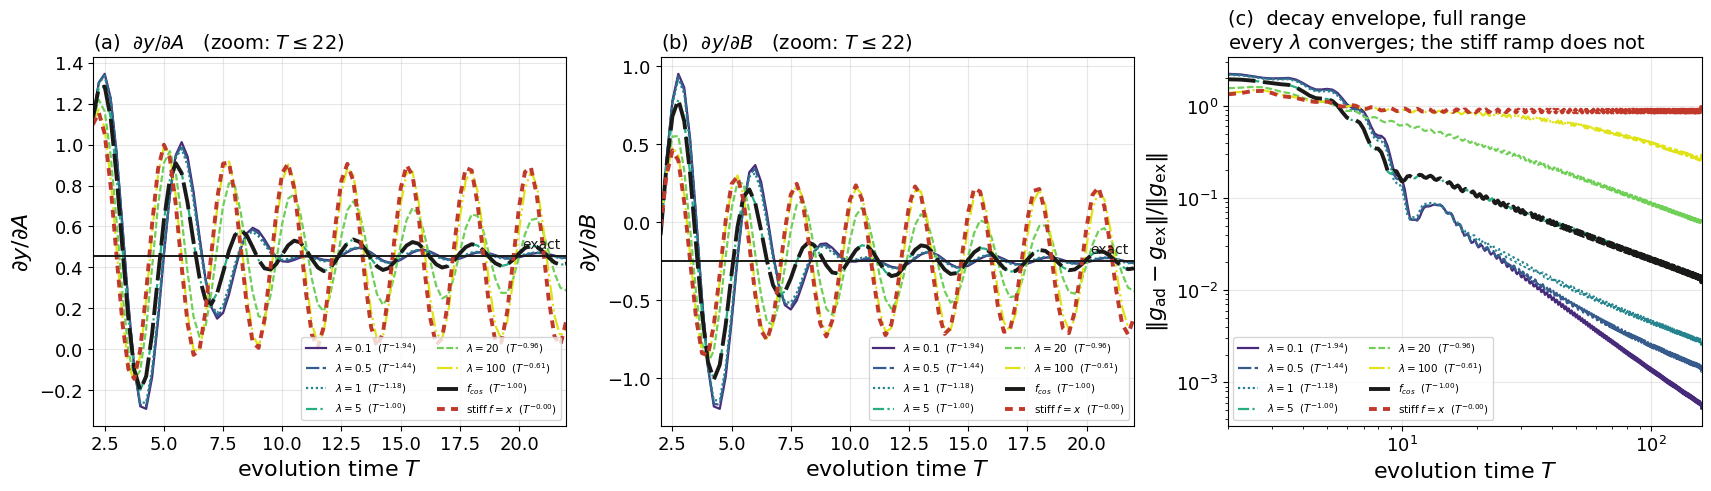

In [33]:
# --- Figure 5: plot (data from run_boundary.py grad_vs_T_lam) -------------------------------
d5 = L("bd_grad_vs_T_lam")
gex5 = d5["g_exact"]
print("exact grad:", np.round(gex5, 8), "  (fx =", float(d5["fx"]), ", tol =", float(d5["tol"]), ")")
for tag, _, _, _, text in series_items():
    print(f"{text:28s}: dev {d5[f'dev_{tag}'][0]:.3e} (T={d5['T'][0]:g})"
          f" -> {d5[f'dev_{tag}'][-1]:.3e} (T={d5['T'][-1]:g});"
          f"  envelope T^{float(d5[f'slope_{tag}']):+.3f}")

TZ = 22.0                                       # zoom window for the value panels
z5 = d5["T"] <= TZ
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17.0, 4.8), layout="constrained")
for ax, comp, sym, tag in ((a1, 0, r"\partial y/\partial A", "(a)"),
                           (a2, 1, r"\partial y/\partial B", "(b)")):
    draw_series(d5, ax, "value", comp=comp, zmask=z5)
    ax.axhline(gex5[comp], color=INK, lw=1.4)
    ax.annotate("exact", xy=(TZ, gex5[comp]), xytext=(-4, 5), textcoords="offset points",
                ha="right", fontsize=10, color=INK)
    ax.set_xlim(d5["T"][0], TZ)
    ax.set_xlabel(r"evolution time $T$"); ax.set_ylabel(r"$%s$" % sym)
    ax.set_title(r"%s  $%s$   (zoom: $T\leq%g$)" % (tag, sym, TZ), loc="left")
    ax.legend(fontsize=7.5, loc="lower right", ncol=2)

draw_series(d5, a3, "env")
a3.set_xlabel(r"evolution time $T$")
a3.set_ylabel(r"$\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$")
a3.set_title("(c)  decay envelope, full range" "\n"
             r"every $\lambda$ converges; the stiff ramp does not", loc="left")
a3.legend(fontsize=7.5, loc="lower left", ncol=2); a3.set_xlim(d5["T"][0], d5["T"][-1])

save(fig, "fig_lam_grad_vs_T")


## Figure 6 — the same, with the **real QEP** gradient

Data: `code/run_boundary.py qep_grad_vs_T_lam` → `data/bd_qep_grad_vs_T_lam.npz`. Same point, same
eight schedules, same $T$ grid and tolerance as Figure 5 — only the estimator changes.

**The estimator.** Figure 5 obtains $\partial y/\partial\theta$ by a central difference *in the
parameter*: four extra free evolutions per $T$, no nudge at all. Here it comes from the QEP
two-phase formula with a **bare nudge** (error signal $=1$),

$$g_{\rm QEP}=\frac{\langle\partial_\theta H\rangle_{\beta}-\langle\partial_\theta H\rangle_{\rm free}}{\beta},
\qquad \partial_AH=-\sigma^z,\quad \partial_BH=-\sigma^x,\quad \beta=0.02 .$$

Onsager reciprocity (Eq. 6 of the note) says $\partial\langle O_i\rangle/\partial\theta
=\partial\langle\partial_\theta H\rangle/\partial\lambda_i$ at $\lambda_i=0$, so nudging along the
*measured* operator $\sigma^z$ and differencing $\langle\partial_\theta H\rangle$ returns the same
$\partial y/\partial\theta$ Figure 5 plots — and against the same analytic reference. Note the
whole 2-vector comes from **one pair of evolutions**, versus four solves for the central
difference: QEP is the cheaper estimator, which is the point of it.

Why the *output* gradient rather than a cost gradient: at $(A,B)=(0.8,1.5)$ the model **is** the
target $h$, so $\varepsilon=y-y_\tau=0$ and the QEP cost gradient is identically zero there.

**What is new here — a second error source.** The nudge is one-sided, hence $O(\beta)$, and that
bias is **independent of $T$**. So each curve descends under the adiabatic law of Figure 5 only
until it meets its own $\beta$ floor, then flattens. The floor is measured directly, with *exact*
equilibria at the same $\beta$; because exact diagonalisation ignores the schedule entirely it is
the same number for all eight series, $7.61\times10^{-3}$ at $\beta=0.02$, and one line serves the
whole panel.

The practical consequence is the crossover: for $\lambda\lesssim1$ the QEP gradient is
$\beta$-limited well before $T=160$, so buying more evolution time is wasted unless $\beta$ is
reduced too; for $\lambda\gtrsim5$ the adiabatic error still dominates and longer $T$ does help.

**Reading the exponents.** The legend fits are taken only where the envelope is clear of the floor
($>2\times$); curves that never get clear are labelled $\beta$-limited rather than given a
meaningless slope. Even so, a curve that meets the floor early has too short a clean window for a
reliable asymptotic exponent — so **read exponents from Figure 5, and achievable accuracy from
here**.


exact grad: [ 0.45796865 -0.24424995]   beta = 0.02   O(beta) floor = 7.6109e-03
(the floor is identical for every series, as it must be: exact diagonalisation does not see the schedule)
$\lambda=0.1$               : dev 1.513e+00 -> 7.656e-03   ratio to floor at T=160:   1.01x
$\lambda=0.5$               : dev 1.507e+00 -> 7.375e-03   ratio to floor at T=160:   0.97x
$\lambda=1$                 : dev 1.498e+00 -> 7.547e-03   ratio to floor at T=160:   0.99x
$\lambda=5$                 : dev 1.435e+00 -> 1.028e-02   ratio to floor at T=160:   1.35x
$\lambda=20$                : dev 1.323e+00 -> 4.989e-02   ratio to floor at T=160:   6.55x
$\lambda=100$               : dev 1.263e+00 -> 2.215e-01   ratio to floor at T=160:  29.10x
$f_{cos}$                   : dev 1.435e+00 -> 1.020e-02   ratio to floor at T=160:   1.34x
stiff $f=x$                 : dev 1.245e+00 -> 7.772e-01   ratio to floor at T=160: 102.11x
saved figures/fig_lam_qep_grad_vs_T


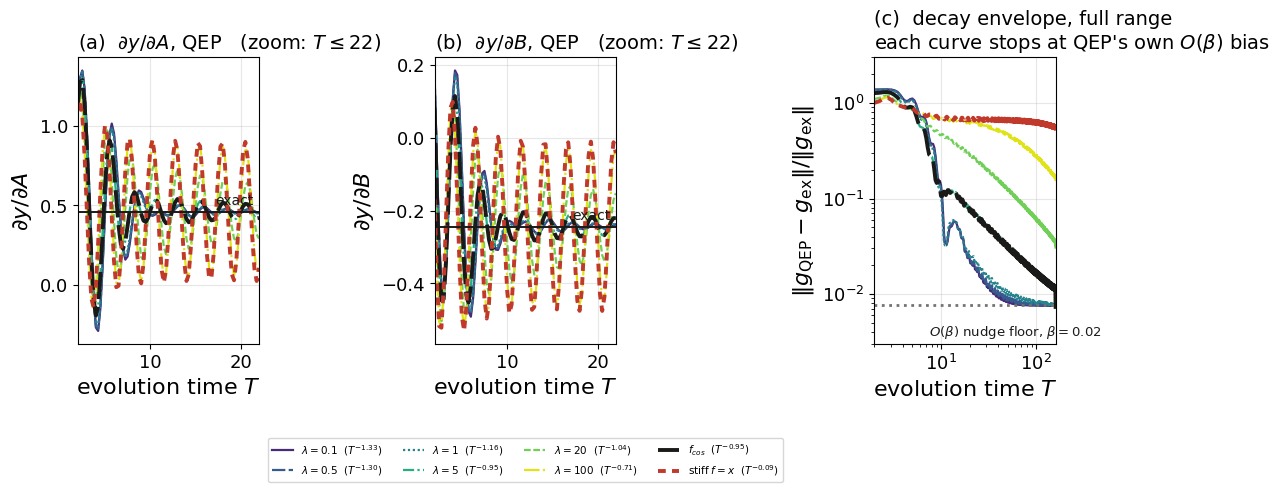

In [34]:
# --- Figure 6: plot (data from run_boundary.py qep_grad_vs_T_lam) ---------------------------
d6 = L("bd_qep_grad_vs_T_lam")
gex6, beta6 = d6["g_exact"], float(d6["beta"])
fl6 = float(d6["floor_smooth"])       # schedule-independent: exact equilibria at the same beta
print(f"exact grad: {np.round(gex6, 8)}   beta = {beta6}   O(beta) floor = {fl6:.4e}")
print("(the floor is identical for every series, as it must be: exact diagonalisation does not"
      " see the schedule)")
for tag, _, _, _, text in series_items():
    print(f"{text:28s}: dev {d6[f'dev_{tag}'][0]:.3e} -> {d6[f'dev_{tag}'][-1]:.3e}"
          f"   ratio to floor at T={d6['T'][-1]:g}: {d6[f'dev_{tag}'][-1]/fl6:6.2f}x")

def qlab6(tag, text):
    """Exponent fitted only where the envelope is clear of the O(beta) floor (>2x it).

    The stored slope_* is fitted on all T>=fit_Tmin, which for the small-lambda curves is mostly
    floor and so reports a meaningless ~T^-0.3."""
    env, T = d6[f"env_{tag}"], d6["T"]
    m = (env > 2.0 * fl6) & (T >= float(d6["fit_Tmin"]))
    if m.sum() >= 8:
        return text + r"  ($T^{%+.2f}$)" % np.polyfit(np.log(T[m]), np.log(env[m]), 1)[0]
    return text + r"  ($\beta$-limited)"

z6 = d6["T"] <= TZ
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11, 4.8), layout="constrained")
for ax, comp, sym, tag in ((a1, 0, r"\partial y/\partial A", "(a)"),
                           (a2, 1, r"\partial y/\partial B", "(b)")):
    draw_series(d6, ax, "value", comp=comp, zmask=z6, labeller=qlab6)
    ax.axhline(gex6[comp], color=INK, lw=1.4)
    ax.annotate("exact", xy=(TZ, gex6[comp]), xytext=(-4, 5), textcoords="offset points",
                ha="right", fontsize=10, color=INK)
    ax.set_xlim(d6["T"][0], TZ)
    ax.set_xlabel(r"evolution time $T$"); ax.set_ylabel(r"$%s$" % sym)
    ax.set_title(r"%s  $%s$, QEP   (zoom: $T\leq%g$)" % (tag, sym, TZ), loc="left")
    #ax.legend(fontsize=7.5, loc="lower right", ncol=2)

a2.legend(fontsize=7.5, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.5))

draw_series(d6, a3, "env", labeller=qlab6)
a3.axhline(fl6, color=MUTED, ls=":", lw=2.0)
a3.annotate(r"$O(\beta)$ nudge floor, $\beta=%g$" % beta6, xy=(60.0, fl6),
            xytext=(0, -13), textcoords="offset points", ha="center", va="top",
            fontsize=9.5, color=INK)
a3.set_xlabel(r"evolution time $T$")
a3.set_ylabel(r"$\|g_{\rm QEP}-g_{\rm ex}\|/\|g_{\rm ex}\|$")
a3.set_title("(c)  decay envelope, full range" "\n"
             r"each curve stops at QEP's own $O(\beta)$ bias", loc="left")
#a3.legend(fontsize=7.5, loc="lower left", ncol=2)
a3.set_xlim(d6["T"][0], d6["T"][-1]); a3.set_ylim(3e-3, 3.0)

save(fig, "fig_lam_qep_grad_vs_T")



## Figure 7 — the *actual* QEP gradient vs $T$, at fixed $\beta$

*(Figure 6 above sweeps $\lambda$; this one is the plain stiff-vs-smooth pair, i.e. the companion of Figure 3 with the correct estimator.)*

Figure 3 differentiates the **output** $y=\langle\sigma^z\rangle$ directly. That is not what QEP
extracts. QEP reads the gradient off **two equilibria** via Onsager reciprocity (Eq. 6 of the
note): with $H_\beta=H_{\rm sys}+\beta O$ and $O$ the *measured* operator (here $\sigma^z$),

$$g_\theta=\frac{\langle\partial_\theta H\rangle_\beta-\langle\partial_\theta H\rangle_0}{\beta},
\qquad \partial_A H=-\sigma^z,\quad \partial_B H=-\sigma^x .$$

Data: `code/run_boundary.py qep_grad_vs_T` → `data/bd_qep_grad_vs_T.npz`, at $\beta=0.02$, with the
nudge **ramped with the same schedule** as $(A,B)$ (what the boundary analysis requires — every
$\tau$-dependence of $H$ must have the vanishing endpoint derivative).

Onsager makes $g_\theta\to\partial y/\partial\theta$ as $\beta\to0$, so the limit is the same closed
form $(B^2/R^3,\,-AB/R^3)$. At $\beta=0.02$ the exact-equilibrium value is
$[0.46177,\,-0.24319]$ against the analytic $[0.45797,\,-0.24425]$ — an $O(\beta)$ offset of
$3.8\times10^{-3}$. **The reference line is the exact-equilibrium QEP gradient at the same
$\beta$**, so the deviation plotted in (c) is the adiabatic error alone, not that offset.

The estimator is completely different from Figure 3's: two adiabatic evolutions whose $O(1)$
boundary biases largely *cancel* in the difference, followed by a division by $\beta$ that
re-amplifies the residue. The split survives anyway — stiff $O(1)$, smooth $1/T$ — but stiff is
smaller than in Figure 3 (mean 0.63 vs 0.88) because of that cancellation.

> **The stiff curve in (c) is not labelled with an exponent, on purpose.** Its slight droop past
> $T\approx100$ is the onset of a **beat**, not convergence. The ramped nudge shifts
> $A(\tau)\to A(\tau)-\beta\lambda(\tau)$, so the free and nudge phases carry different dynamical
> phases ($\Delta\gamma=2.461525$ vs $2.448333$) and the envelope beats with period
> $2\pi/|\delta\Delta\gamma|=476$. The plotted range reaches only $0.34$ of one beat. Running the
> stiff case out to $T=782$ confirms it: the envelope collapses to $0.0016$ at $T=477$ (predicted
> $476.3$) and **recovers** to $\sim0.14$ by $T=700$. It sloshes on two timescales; it does not
> converge. A fitted $T^{-0.09}$ over $T\le160$ would read as weak convergence and would be wrong.


analytic (beta->0) = [ 0.45796865 -0.24424995]
exact-QEP at beta=0.02 = [ 0.46177493 -0.243193  ]   O(beta) offset 3.81e-03
stiff : mean rel deviation on T>=20: 0.6251  (flat -- see the beat note above, period 476)
smooth: mean rel deviation on T>=20: 0.0219   envelope T^-1.079
saved figures/bd_qep_grad_vs_T


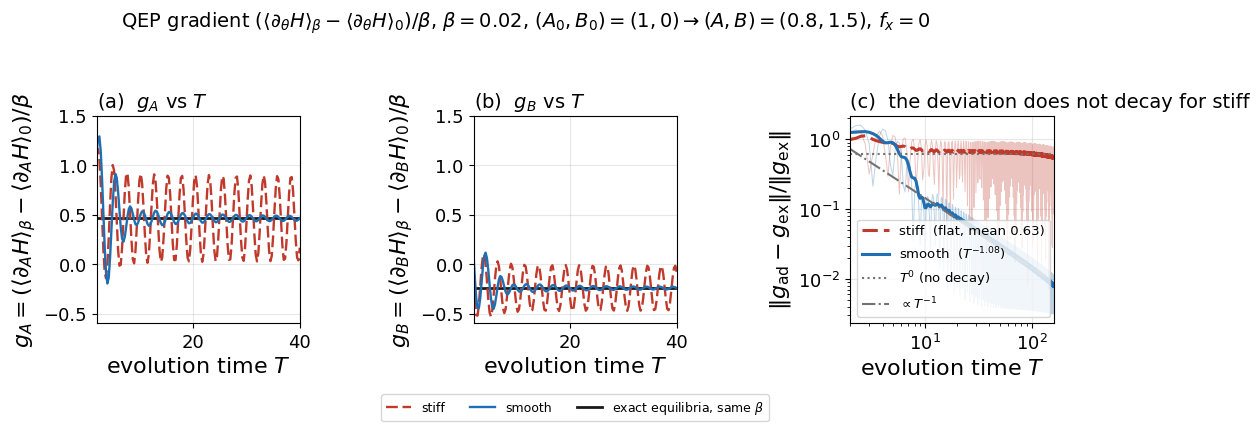

In [35]:
# --- Figure 7: plot (data from run_boundary.py qep_grad_vs_T) ------------------------------
# One explicit call per curve, as in Figure 3 -- no loop over the schedules.
d6 = L("bd_qep_grad_vs_T")
T6   = d6["T"]
gex6 = d6["g_exact"]
gan6 = d6["g_analytic"]
p6   = d6["p"]
s06  = d6["start"]
beta6 = float(d6["beta"])
tmin6 = float(d6["fit_Tmin"])
m6    = T6 >= tmin6

g6_stiff    = d6["grad_linear"]
g6_smooth   = d6["grad_smooth"]
dev6_stiff  = d6["dev_linear"]
dev6_smooth = d6["dev_smooth"]
env6_stiff  = d6["env_linear"]
env6_smooth = d6["env_smooth"]
sl6_smooth  = float(d6["slope_smooth"])

print(f"analytic (beta->0) = {np.round(gan6, 8)}")
print(f"exact-QEP at beta={beta6} = {np.round(gex6, 8)}"
      f"   O(beta) offset {np.max(np.abs(gex6 - gan6)):.2e}")
print(f"stiff : mean rel deviation on T>={tmin6:g}: {env6_stiff[m6].mean():.4f}  (flat -- see the"
      f" beat note above, period 476)")
print(f"smooth: mean rel deviation on T>={tmin6:g}: {env6_smooth[m6].mean():.4f}"
      f"   envelope T^{sl6_smooth:+.3f}")

TW6 = 40.0                                     # window for the value panels

# Legend position of panel (b): (x, y) in AXES coordinates -- (0, 0) is the panel's bottom-left,
# (1, 1) its top-right. `loc` names which corner of the legend BOX is pinned there. Raise y to
# lift it, change x to slide it sideways; outside [0, 1] puts it outside the axes.
LEG_B_XY6 = (0.5, 0.02)

w6 = T6 <= TW6
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11, 5.2))

# (a) g_A
a1.plot(T6[w6], g6_stiff[w6, 0], color=C["linear"], ls=DASH["linear"], lw=1.7,
        label=NAME["linear"])
a1.plot(T6[w6], g6_smooth[w6, 0], color=C["smooth"], ls=DASH["smooth"], lw=1.7,
        label=NAME["smooth"])
a1.axhline(gex6[0], color=INK, lw=2.0, zorder=1, label=r"exact equilibria, same $\beta$")
a1.set_xlabel(r"evolution time $T$")
a1.set_ylabel(r"$g_A=(\langle\partial_A H\rangle_\beta-\langle\partial_A H\rangle_0)/\beta$")
a1.set_title(r"(a)  $g_A$ vs $T$", loc="left")
a1.set_xlim(T6[0], TW6); #a1.legend(fontsize=9.5, loc="best")
a1.set_ylim(-0.6, 1.5)

# (b) g_B
a2.plot(T6[w6], g6_stiff[w6, 1], color=C["linear"], ls=DASH["linear"], lw=1.7,
        label=SHORT["linear"])
a2.plot(T6[w6], g6_smooth[w6, 1], color=C["smooth"], ls=DASH["smooth"], lw=1.7,
        label=SHORT["smooth"])
a2.axhline(gex6[1], color=INK, lw=2.0, zorder=1, label=r"exact equilibria, same $\beta$")
a2.set_xlabel(r"evolution time $T$")
a2.set_ylabel(r"$g_B=(\langle\partial_B H\rangle_\beta-\langle\partial_B H\rangle_0)/\beta$")
a2.set_title(r"(b)  $g_B$ vs $T$", loc="left")
a2.set_ylim(-0.6, 1.5)                      # room for the one-row legend
a2.set_xlim(T6[0], TW6)
a2.legend(fontsize=9, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.5))

# (c) relative deviation: raw (thin) + RMS envelope (thick).
# The stiff curve carries no fitted exponent on purpose -- it is not a power law, it is beating.
a3.loglog(T6, dev6_stiff, color=C["linear"], lw=0.7, alpha=0.3)
a3.loglog(T6, dev6_smooth, color=C["smooth"], lw=0.7, alpha=0.3)
a3.loglog(T6, env6_stiff, color=C["linear"], ls=DASH["linear"], lw=2.2,
          label=r"stiff  (flat, mean %.2f)" % env6_stiff[m6].mean())
a3.loglog(T6, env6_smooth, color=C["smooth"], ls=DASH["smooth"], lw=2.2,
          label=r"smooth  ($T^{%+.2f}$)" % sl6_smooth)
a3.axhline(env6_stiff[m6].mean(), color=MUTED, ls=":", lw=1.5, label=r"$T^{0}$ (no decay)")
k6 = int(np.argmin(np.abs(T6 - 40.0)))
a3.loglog(T6, env6_smooth[k6] * (T6 / T6[k6]) ** -1.0, color=MUTED, ls="-.", lw=1.5,
          label=r"$\propto T^{-1}$")
a3.set_xlabel(r"evolution time $T$")
a3.set_ylabel(r"$\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$")
a3.set_title("(c)  the deviation does not decay for stiff", loc="left")
a3.legend(fontsize=9.5, loc="lower left"); a3.set_xlim(T6[0], T6[-1])

fig.suptitle(r"QEP gradient $(\langle\partial_\theta H\rangle_\beta-"
             r"\langle\partial_\theta H\rangle_0)/\beta$, $\beta=%g$, "
             r"$(A_0,B_0)=(%.0f,%.0f)\to(A,B)=(%.1f,%.1f)$, $f_x=0$"
             % (beta6, s06[0], s06[1], p6[0], p6[1]), fontsize=14, y=1.02)
fig.tight_layout()
save(fig, "bd_qep_grad_vs_T")



## Figure 8 — how the $T$-index depends on $\lambda$

The exponent $n$ in $\text{envelope}\propto T^{\,n}$, fitted per $\lambda$ from the Figure 6 data
and cross-checked against Figure 7. Pure post-processing: the raw per-$\lambda$ gradients
`grad_lam{j}` are already saved, so nothing is re-evolved.

**Read the two curves, not one.** `bd_qep_grad_vs_T_lam` measures its deviation against the
**analytic $\beta\!\to\!0$** gradient. At finite $\beta$ the QEP estimator sits an $O(\beta)$
systematic distance from that — here $7.61\times10^{-3}$ — and that offset is *not* an adiabatic
error and does not decay with $T$. For small $\lambda$ the adiabatic error drops below it, the
curve saturates, and the fitted exponent then measures the approach to the floor rather than the
physics. Re-referencing to the **exact-equilibrium QEP gradient at the same $\beta$** (Figure 7's
`g_exact`) removes the floor:

| $\lambda$ | as measured | floor removed | envelope($T_{\max}$)/floor |
|---|---|---|---|
| 0.1 | $-0.32$ | $\mathbf{-2.01}$ | 1.03 |
| 0.5 | $-0.35$ | $\mathbf{-1.52}$ | 1.07 |
| 1 | $-0.44$ | $\mathbf{-1.25}$ | 1.14 |
| 5 | $-0.94$ | $\mathbf{-1.08}$ | 0.92 |
| 20 | $-1.04$ | $-1.05$ | 4.42 |
| 100 | $-0.71$ | $-0.71$ | 22.8 |
| cosine ramp | $-0.93$ | $\mathbf{-1.08}$ | — |
| stiff | $-0.09$ | $-0.09$ | 75.6 |

So the as-measured curve rising towards $0$ at small $\lambda$ is an **artifact** — it would say a
flatter boundary converges *worse*, which is backwards. With the floor removed the trend is
monotonic the other way: smaller $\lambda$ → steeper decay, $-2.01$ at $\lambda=0.1$ through
$-1.08$ at the cosine ramp, flattening to $-0.71$ at $\lambda=100$ and collapsing to $-0.09$ for
the stiff schedule, which does not converge at all. The corrected values also track the
output-derivative exponents of Figure 5 ($-1.94$, $-1.44$, $-1.18$, $-1.00$, $-0.96$, $-0.62$)
within $\sim0.08$, which is the Onsager consistency check.


   lambda   as-measured   floor-removed   env(Tmax)/floor
      0.1        -0.321          -2.010              1.03
      0.5        -0.349          -1.515              1.07
        1        -0.437          -1.254              1.14
        5        -0.935          -1.078              0.92
       20        -1.040          -1.050              4.42
      100        -0.707          -0.708             22.78
   cosine                        -1.079
    stiff                        -0.095
saved figures/bd_index_vs_lam


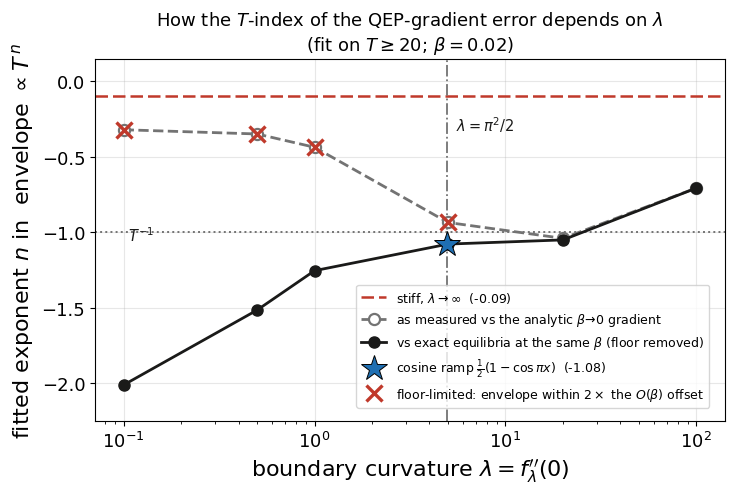

In [36]:
# --- Figure 8: fitted T-exponent vs lambda (post-processing of Figures 6 and 7) ------------
d8  = L("bd_qep_grad_vs_T_lam")
d8b = L("bd_qep_grad_vs_T")
T8, lams8 = d8["T"], d8["lams"]
g_an = d8["g_exact"]                           # the analytic beta->0 reference Figure 6 used
g_qp = d8b["g_exact"]                          # exact equilibria at the same beta: no floor
tmin8 = float(d8["fit_Tmin"])
m8 = T8 >= tmin8
w8 = max(3, int(round(2.5 / (T8[1] - T8[0]))) | 1)
SL8 = float(d8["smooth_lam"])
floor8 = float(d8["floor_lam0"])

def exponent8(G, gref):
    dev = np.linalg.norm(G - gref[None], axis=-1) / np.linalg.norm(gref)
    env = np.sqrt(np.convolve(np.pad(dev ** 2, w8 // 2, mode="reflect"),
                              np.ones(w8) / w8, mode="valid"))
    return float(np.polyfit(np.log(T8[m8]), np.log(env[m8]), 1)[0]), env

n_floor, n_clean, sat8 = [], [], []
for j in range(len(lams8)):
    a, env_a = exponent8(d8[f"grad_lam{j}"], g_an)
    b, _ = exponent8(d8[f"grad_lam{j}"], g_qp)
    n_floor.append(a); n_clean.append(b); sat8.append(env_a[-1] / floor8)
n_floor, n_clean, sat8 = np.array(n_floor), np.array(n_clean), np.array(sat8)
sm_clean, _ = exponent8(d8["grad_smooth"], g_qp)
st_clean, _ = exponent8(d8["grad_linear"], g_qp)

print(f"  {'lambda':>7}  {'as-measured':>12}  {'floor-removed':>14}  {'env(Tmax)/floor':>16}")
for l, a, b, s_ in zip(lams8, n_floor, n_clean, sat8):
    print(f"  {l:7g}  {a:+12.3f}  {b:+14.3f}  {s_:16.2f}")
print(f"  {'cosine':>7}  {'':>12}  {sm_clean:+14.3f}")
print(f"  {'stiff':>7}  {'':>12}  {st_clean:+14.3f}")

# Legend position, as an (x, y) pair in AXES coordinates: (0, 0) bottom-left, (1, 1) top-right.
LEG_XY8 = (0.985, 0.02)

fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.axhline(-1.0, color=MUTED, ls=":", lw=1.4)
ax.text(0.105, -1.06, r"$T^{-1}$", color=INK, fontsize=10.5)
ax.axhline(st_clean, color=C["linear"], ls=DASH["linear"], lw=1.8,
           label=r"stiff, $\lambda\to\infty$  (%.2f)" % st_clean)
ax.axvline(SL8, color=MUTED, ls="-.", lw=1.3)
ax.text(SL8 * 1.12, -0.33, r"$\lambda=\pi^2/2$", color=INK, fontsize=10.5)

ax.semilogx(lams8, n_floor, "o--", color=MUTED, ms=8, mfc="white", mew=1.6,
            label=r"as measured vs the analytic $\beta\!\to\!0$ gradient")
ax.semilogx(lams8, n_clean, "o-", color=INK, ms=8,
            label=r"vs exact equilibria at the same $\beta$ (floor removed)")
ax.plot([SL8], [sm_clean], "*", color=C["smooth"], ms=19, mec="k", mew=0.7, zorder=6,
        label=r"cosine ramp $\frac{1}{2}(1-\cos\pi x)$  (%.2f)" % sm_clean)
bad8 = sat8 < 2.0
ax.semilogx(lams8[bad8], n_floor[bad8], "x", color="#C0392B", ms=11, mew=2.4, zorder=7,
            label=r"floor-limited: envelope within $2\times$ the $O(\beta)$ offset")

ax.set_xlabel(r"boundary curvature $\lambda=f_\lambda''(0)$")
ax.set_ylabel(r"fitted exponent $n$ in  envelope $\propto T^{\,n}$")
ax.set_title(r"How the $T$-index of the QEP-gradient error depends on $\lambda$"
             "\n" r"(fit on $T\geq%g$; $\beta=%g$)" % (tmin8, float(d8b["beta"])), fontsize=13)
ax.legend(fontsize=9, loc="lower right", bbox_to_anchor=LEG_XY8)
ax.set_ylim(-2.25, 0.15)
fig.tight_layout()
save(fig, "bd_index_vs_lam")



## Figure 9 — where the sampled points are, and which ones sit in the wedge

$(A,B)$ uniform on $[-3,3]^2$ — **all 40 kept, nothing rejected**. The wedge is now a *label*, not
a filter: the 13 points inside $\{A<1,\ |B|<\tfrac12(1-A)\}$ are drawn **red**, and the colour ramp
is viridis (which contains no red) so the two encodings never collide. Red is $\ge\Delta E\,12.8$
from every colour on the ramp under simulated CVD.

**What the wedge means.** The ramp is $(A(\tau),B(\tau))=(1,0)+f(\tau)(A-1,B)$ — a straight
*segment* from the start to the endpoint. The gap $2|(A(\tau),B(\tau))|$ vanishes only at the
origin, so the risky endpoints are those whose segment passes close to $(0,0)$. The perpendicular
distance from the origin to it is $|B|/\sqrt{(A-1)^2+B^2}$, so the rays $B=\pm\tfrac12(A-1)$ out of
$(1,0)$ bound a cone about the $-A$ direction; inside it the path aims at the origin.

> **The red marking is necessary-ish, not sufficient.** The wedge describes the *unprobed* path.
> With a probe on, $H=-A\sigma^z-(B+f_x)\sigma^x$, so the segment runs from $(1,f_x)$ to
> $(A,B+f_x)$ — shifted vertically — and the wedge says nothing about those. Measured: *excluding*
> the slope-$\tfrac13$ wedge barely moved the bad population (deviation 16.4 against 17.2 uncut),
> because the worst probe still came within 0.036 of the origin. Widening to slope $\tfrac12$ got
> it to 7.2. The rule that actually works is per-probe — reject if *any* $f_x$ path comes within
> $1/\sqrt5$ of the origin — which drops the deviation to 0.17.


saved figures/bd_scatter_points


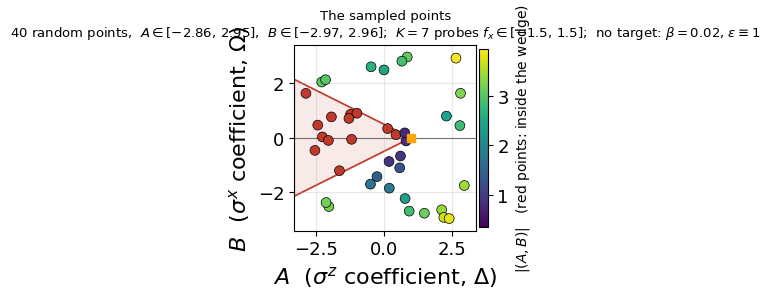

In [37]:
# --- bd_scatter_points (data from run_boundary.py grad_scatter_sched) ---
import matplotlib as mpl
qep_A0, qep_B0 = qep.A0, qep.B0
SCAT_CMAP = "viridis"      # no red on this ramp -- red is reserved for the wedge marker
WEDGE_C = "#C0392B"
SCAT_ROWS = ("linear", "smooth")
ROWNAME = {"linear": r"stiff  $f(x)=x$",
           "smooth": r"smooth  $\frac{1}{2}(1-\cos\pi x)$"}

def _scat_pos(d):
    """All 40 points, a title fragment, the colour scale, and the in-wedge mask.

    Colour is |(A,B)| on VIRIDIS -- deliberately a ramp with no red in it, because RED is reserved
    for the wedge marker. Points inside the wedge {A < 1 and |B| < (1-A)*slope} are drawn red:
    those are the endpoints whose UNPROBED ramp (1,0) -> (A,B) aims at the origin, where the gap
    2|(A(tau),B(tau))| closes. Red is >= dE 12.8 (CVD) from every colour on the viridis ramp.

    CAVEAT the red marking cannot express: the probe shifts the path. With a probe on the segment
    runs from (1,fx) to (A,B+fx), so the wedge describes only the fx=0 member of the family; a
    point outside it can still have some probe aiming at the origin. Measured: excluding the
    slope-1/3 wedge barely moved the A<0 deviation (16.4 vs 17.2 uncut).
    """
    P = d["pts"]
    wedge = np.asarray(d["in_wedge"]).astype(bool)
    slope = float(d["wedge_slope"])
    lab = (r"%d random points,  $A\in[%.2f,\,%.2f]$,  $B\in[%.2f,\,%.2f]$;  "
           r"$K=%d$ probes $f_x\in[%g,\,%g]$;  no target: $\beta=%g$, $\varepsilon\equiv1$"
           % (len(P), P[:, 0].min(), P[:, 0].max(), P[:, 1].min(), P[:, 1].max(),
              len(d["fxs"]), d["fxs"].min(), d["fxs"].max(), float(d["beta"])))
    mag = np.linalg.norm(P, axis=1)
    return mag, lab, mpl.colors.Normalize(mag.min(), mag.max()), wedge, slope

def _pt_colors(cval, norm, wedge):
    c = np.array([plt.get_cmap(SCAT_CMAP)(norm(v)) for v in cval])
    c[wedge] = mpl.colors.to_rgba(WEDGE_C)
    return c

def _scat_draw(ax, x, y, cval, norm, wedge):
    """dot = g_Omega (B component), open circle = g_Delta (A component); red = inside the wedge."""
    col = _pt_colors(cval, norm, wedge)
    ax.scatter(x[:, 0], y[:, 0], s=72, marker="o", facecolors="none", linewidths=1.6,
               edgecolors=col, zorder=3)
    ax.scatter(x[:, 1], y[:, 1], s=30, marker="o", c=col, edgecolors="0.25", linewidths=0.4,
               zorder=4)

def _scat_legend(ax, slope, fontsize=9):
    h = [plt.Line2D([], [], ls="", marker="o", ms=5, color="0.3",
                    label=r"$g_\Omega$  ($\sigma^x$ / $B$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=9, mfc="none", mew=1.6, color="0.3",
                    label=r"$g_\Delta$  ($\sigma^z$ / $A$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=6, color=WEDGE_C,
                    label=r"inside the wedge $|B|<%g(1-A)$" % slope)]
    ax.legend(handles=h, fontsize=fontsize, loc="upper left", framealpha=0.9)

def _scat_cbar(fig, ax, norm):
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=SCAT_CMAP), ax=ax,
                      fraction=0.015 if np.ndim(ax) else 0.046, pad=0.012)
    cb.set_label(r"$|(A,B)|$   (red points: inside the wedge)", fontsize=10)
    return cb

d = L("bd_grad_scatter_sched")
cval, lab, norm, wedge, slope = _scat_pos(d)
P = d["pts"]
fig, ax = plt.subplots(figsize=(3.5, 3.5))
aw = np.linspace(P[:, 0].min() * 1.15, 1.0, 200)
ax.fill_between(aw, -(1.0 - aw) * slope, (1.0 - aw) * slope, color=WEDGE_C, alpha=0.10,
                zorder=0)
ax.plot(aw, (1.0 - aw) * slope, color=WEDGE_C, lw=1.2, zorder=1)
ax.plot(aw, -(1.0 - aw) * slope, color=WEDGE_C, lw=1.2, zorder=1)
ax.scatter(P[:, 0], P[:, 1], s=50, c=_pt_colors(cval, norm, wedge),
           edgecolors="k", linewidths=0.5, zorder=4)
ax.plot([qep_A0], [qep_B0], marker="s", ms=6, color='orange', zorder=5)
'''
ax.annotate(r"ramp start $(A_0,B_0)=(%g,%g)$" % (qep_A0, qep_B0), (qep_A0, qep_B0),
            xytext=(1.75, 2.15), ha="center", fontsize=9.5, color=INK,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.annotate(r"wedge $|B|<%g(1-A)$: the unprobed" "\n" r"ramp aims at the origin (%d pts)"
            % (slope, wedge.sum()), (-2.1, -0.15), xytext=(-2.9, -2.35), ha="left",
            fontsize=9, color=WEDGE_C,
            arrowprops=dict(arrowstyle="->", color=WEDGE_C, lw=1.2))
'''
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlim(P[:, 0].min() * 1.15, P[:, 0].max() * 1.15)
ax.set_ylim(P[:, 1].min() * 1.15, P[:, 1].max() * 1.15)
ax.set_aspect("equal")
ax.set_xlabel(r"$A$  ($\sigma^z$ coefficient, $\Delta$)")
ax.set_ylabel(r"$B$  ($\sigma^x$ coefficient, $\Omega$)")
ax.set_title("The sampled points\n" + lab, fontsize=9.5)
_scat_cbar(fig, ax, norm)
fig.tight_layout()
save(fig, "bd_scatter_points")



## Figure 10 — repeat of `grad_scatter`: the numerical-adiabatic reference is not ground truth

$K=7$ probes on $f_x\in[-1.5,1.5]$, both schedules. Marker shape carries the component — **dot**
$=g_\Omega$, **open circle** $=g_\Delta$ — and colour carries the point, so neither rests on
colour alone.

The published `grad_scatter` puts the **numerical gradient of the adiabatic cost** on the x-axis.
That is not ground truth: it carries the same $O(1)$ boundary error as the QEP estimate, so both
axes are contaminated and the cloud spreads in both directions. The left panel is the control —
with **exact** equilibria the two estimators agree on the diagonal, up to the $O(\beta)$ offset a
finite nudge necessarily leaves.


saved figures/bd_grad_scatter_sched


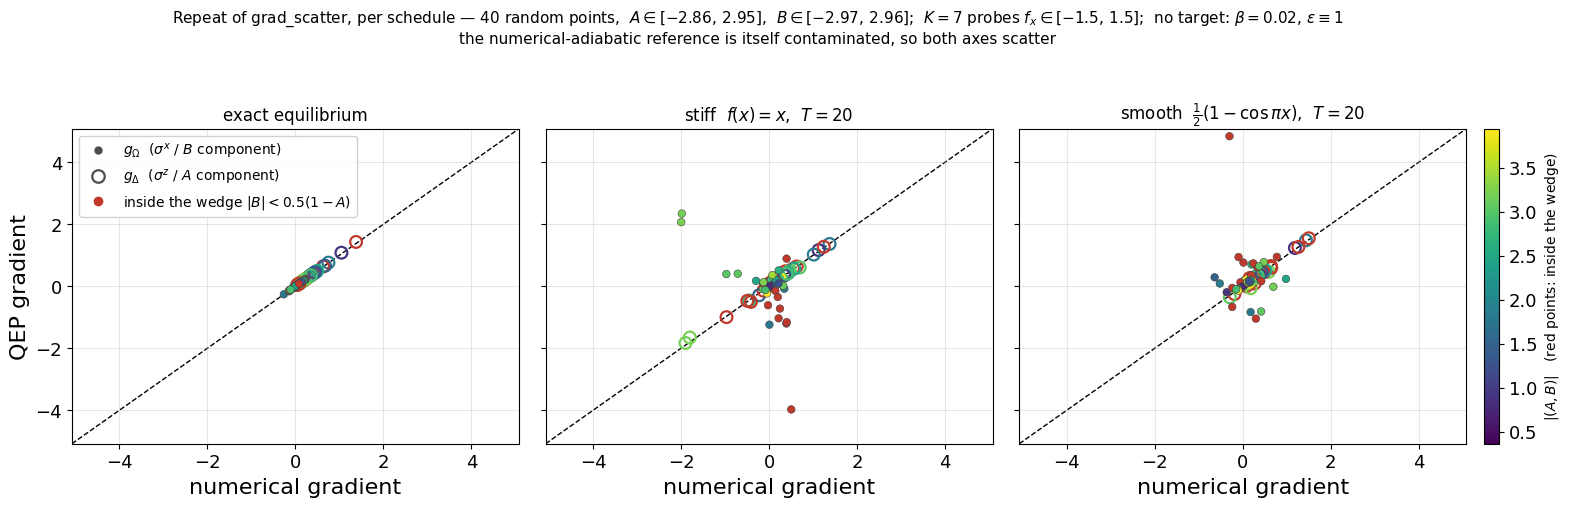

In [38]:
# --- bd_grad_scatter_sched (data from run_boundary.py grad_scatter_sched) ---
import matplotlib as mpl
qep_A0, qep_B0 = qep.A0, qep.B0
SCAT_CMAP = "viridis"      # no red on this ramp -- red is reserved for the wedge marker
WEDGE_C = "#C0392B"
SCAT_ROWS = ("linear", "smooth")
ROWNAME = {"linear": r"stiff  $f(x)=x$",
           "smooth": r"smooth  $\frac{1}{2}(1-\cos\pi x)$"}

def _scat_pos(d):
    """All 40 points, a title fragment, the colour scale, and the in-wedge mask.

    Colour is |(A,B)| on VIRIDIS -- deliberately a ramp with no red in it, because RED is reserved
    for the wedge marker. Points inside the wedge {A < 1 and |B| < (1-A)*slope} are drawn red:
    those are the endpoints whose UNPROBED ramp (1,0) -> (A,B) aims at the origin, where the gap
    2|(A(tau),B(tau))| closes. Red is >= dE 12.8 (CVD) from every colour on the viridis ramp.

    CAVEAT the red marking cannot express: the probe shifts the path. With a probe on the segment
    runs from (1,fx) to (A,B+fx), so the wedge describes only the fx=0 member of the family; a
    point outside it can still have some probe aiming at the origin. Measured: excluding the
    slope-1/3 wedge barely moved the A<0 deviation (16.4 vs 17.2 uncut).
    """
    P = d["pts"]
    wedge = np.asarray(d["in_wedge"]).astype(bool)
    slope = float(d["wedge_slope"])
    lab = (r"%d random points,  $A\in[%.2f,\,%.2f]$,  $B\in[%.2f,\,%.2f]$;  "
           r"$K=%d$ probes $f_x\in[%g,\,%g]$;  no target: $\beta=%g$, $\varepsilon\equiv1$"
           % (len(P), P[:, 0].min(), P[:, 0].max(), P[:, 1].min(), P[:, 1].max(),
              len(d["fxs"]), d["fxs"].min(), d["fxs"].max(), float(d["beta"])))
    mag = np.linalg.norm(P, axis=1)
    return mag, lab, mpl.colors.Normalize(mag.min(), mag.max()), wedge, slope

def _pt_colors(cval, norm, wedge):
    c = np.array([plt.get_cmap(SCAT_CMAP)(norm(v)) for v in cval])
    c[wedge] = mpl.colors.to_rgba(WEDGE_C)
    return c

def _scat_draw(ax, x, y, cval, norm, wedge):
    """dot = g_Omega (B component), open circle = g_Delta (A component); red = inside the wedge."""
    col = _pt_colors(cval, norm, wedge)
    ax.scatter(x[:, 0], y[:, 0], s=72, marker="o", facecolors="none", linewidths=1.6,
               edgecolors=col, zorder=3)
    ax.scatter(x[:, 1], y[:, 1], s=30, marker="o", c=col, edgecolors="0.25", linewidths=0.4,
               zorder=4)

def _scat_legend(ax, slope, fontsize=9):
    h = [plt.Line2D([], [], ls="", marker="o", ms=5, color="0.3",
                    label=r"$g_\Omega$  ($\sigma^x$ / $B$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=9, mfc="none", mew=1.6, color="0.3",
                    label=r"$g_\Delta$  ($\sigma^z$ / $A$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=6, color=WEDGE_C,
                    label=r"inside the wedge $|B|<%g(1-A)$" % slope)]
    ax.legend(handles=h, fontsize=fontsize, loc="upper left", framealpha=0.9)

def _scat_cbar(fig, ax, norm):
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=SCAT_CMAP), ax=ax,
                      fraction=0.015 if np.ndim(ax) else 0.046, pad=0.012)
    cb.set_label(r"$|(A,B)|$   (red points: inside the wedge)", fontsize=10)
    return cb

d = L("bd_grad_scatter_sched")
cval, lab, norm, wedge, slope = _scat_pos(d)
nT = int(d["num_T"])
panels = [("exact equilibrium", d["g_num_exact"], d["g_qep_exact"])]
for sc in SCAT_ROWS:
    panels.append((ROWNAME[sc] + r",  $T=%d$" % nT, d[f"gn_{sc}_T{nT}"], d[f"gq_{sc}_T{nT}"]))
lim = 1.05 * max(max(abs(x).max(), abs(y).max()) for _, x, y in panels)
fig, axes = plt.subplots(1, 3, figsize=(15.4, 5.0), sharex=True, sharey=True)
for ax, (ttl, gn, gq) in zip(axes, panels):
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, zorder=1)
    _scat_draw(ax, gn, gq, cval, norm, wedge)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("numerical gradient"); ax.set_title(ttl, fontsize=12)
axes[0].set_ylabel("QEP gradient")
_scat_legend(axes[0], slope, fontsize=10)
fig.suptitle("Repeat of grad_scatter, per schedule — " + lab
             + "\nthe numerical-adiabatic reference is itself contaminated, so both axes scatter",
             y=1.02, fontsize=11)
fig.tight_layout()
_scat_cbar(fig, axes, norm)
save(fig, "bd_grad_scatter_sched")



## Figure 11 — repeat of `grad_cos_scatter`, per schedule

Adiabatic-QEP (y) against **exact-QEP** (x) across $T=1,2,5,10,20,50$.

**Symlog axes, not clipped.** With the $A<0$ sector included the range spans a factor of ~40, so a
linear axis squashes the $A>0$ bulk into an invisible blob. Symlog with the same threshold on both
axes keeps the bulk resolved and compresses the outliers, and $y=x$ is still exactly the diagonal
because both axes transform identically. Nothing is hidden — contrast the published figure, which
clips to $[-2,2]$ without saying what that drops.

The purple ($A>0$) points tighten onto the diagonal as $T$ grows, faster for the smooth ramp; the
orange ($A<0$) points stay scattered at every $T$. Panel titles give the median cosine for the two
sectors separately, and the $A<0$ number goes **negative** at several $T$ — the gradient points the
wrong way.


saved figures/bd_grad_cos_scatter_sched


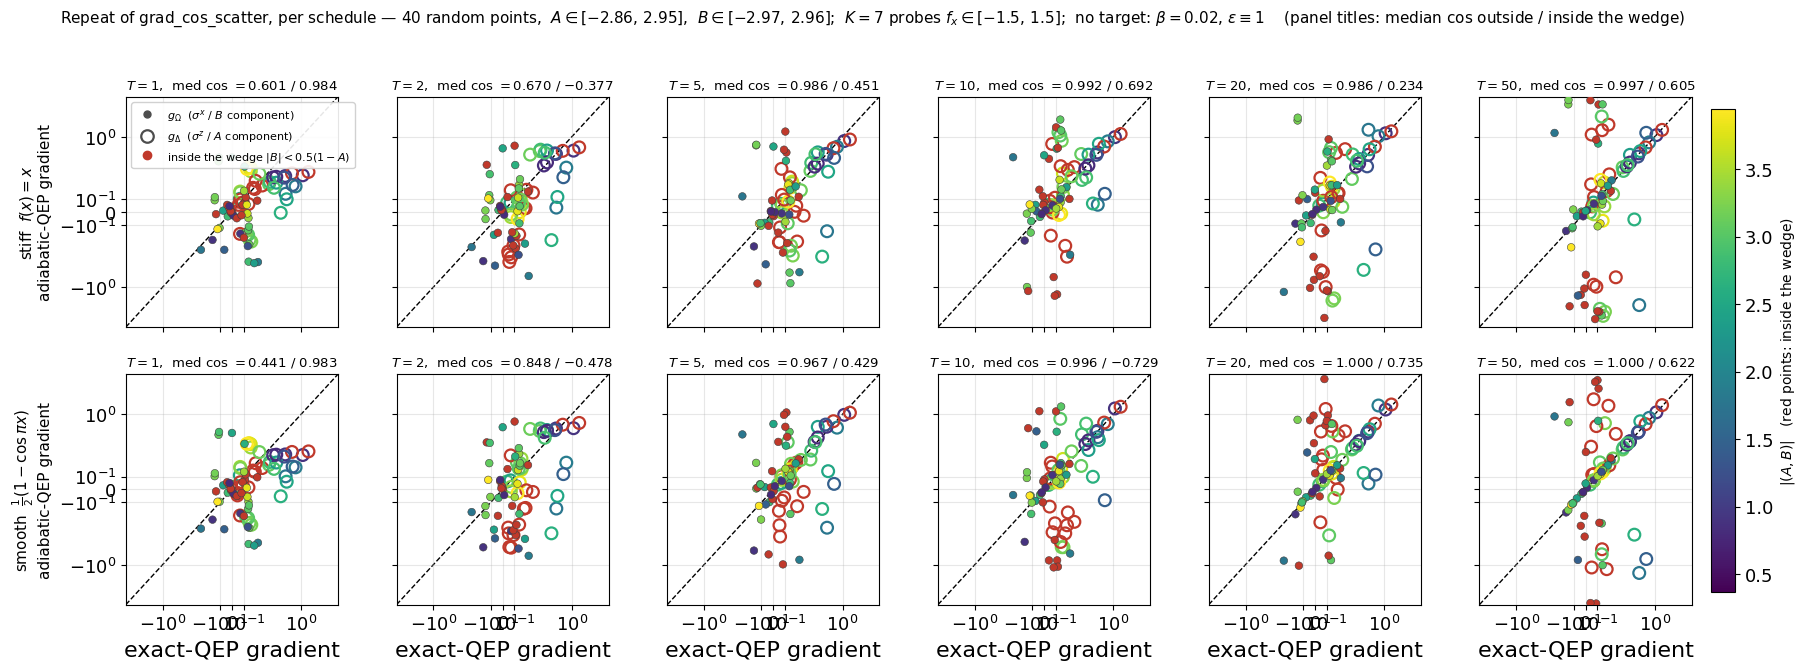

In [39]:
# --- bd_grad_cos_scatter_sched (data from run_boundary.py grad_scatter_sched) ---
import matplotlib as mpl
qep_A0, qep_B0 = qep.A0, qep.B0
SCAT_CMAP = "viridis"      # no red on this ramp -- red is reserved for the wedge marker
WEDGE_C = "#C0392B"
SCAT_ROWS = ("linear", "smooth")
ROWNAME = {"linear": r"stiff  $f(x)=x$",
           "smooth": r"smooth  $\frac{1}{2}(1-\cos\pi x)$"}

def _scat_pos(d):
    """All 40 points, a title fragment, the colour scale, and the in-wedge mask.

    Colour is |(A,B)| on VIRIDIS -- deliberately a ramp with no red in it, because RED is reserved
    for the wedge marker. Points inside the wedge {A < 1 and |B| < (1-A)*slope} are drawn red:
    those are the endpoints whose UNPROBED ramp (1,0) -> (A,B) aims at the origin, where the gap
    2|(A(tau),B(tau))| closes. Red is >= dE 12.8 (CVD) from every colour on the viridis ramp.

    CAVEAT the red marking cannot express: the probe shifts the path. With a probe on the segment
    runs from (1,fx) to (A,B+fx), so the wedge describes only the fx=0 member of the family; a
    point outside it can still have some probe aiming at the origin. Measured: excluding the
    slope-1/3 wedge barely moved the A<0 deviation (16.4 vs 17.2 uncut).
    """
    P = d["pts"]
    wedge = np.asarray(d["in_wedge"]).astype(bool)
    slope = float(d["wedge_slope"])
    lab = (r"%d random points,  $A\in[%.2f,\,%.2f]$,  $B\in[%.2f,\,%.2f]$;  "
           r"$K=%d$ probes $f_x\in[%g,\,%g]$;  no target: $\beta=%g$, $\varepsilon\equiv1$"
           % (len(P), P[:, 0].min(), P[:, 0].max(), P[:, 1].min(), P[:, 1].max(),
              len(d["fxs"]), d["fxs"].min(), d["fxs"].max(), float(d["beta"])))
    mag = np.linalg.norm(P, axis=1)
    return mag, lab, mpl.colors.Normalize(mag.min(), mag.max()), wedge, slope

def _pt_colors(cval, norm, wedge):
    c = np.array([plt.get_cmap(SCAT_CMAP)(norm(v)) for v in cval])
    c[wedge] = mpl.colors.to_rgba(WEDGE_C)
    return c

def _scat_draw(ax, x, y, cval, norm, wedge):
    """dot = g_Omega (B component), open circle = g_Delta (A component); red = inside the wedge."""
    col = _pt_colors(cval, norm, wedge)
    ax.scatter(x[:, 0], y[:, 0], s=72, marker="o", facecolors="none", linewidths=1.6,
               edgecolors=col, zorder=3)
    ax.scatter(x[:, 1], y[:, 1], s=30, marker="o", c=col, edgecolors="0.25", linewidths=0.4,
               zorder=4)

def _scat_legend(ax, slope, fontsize=9):
    h = [plt.Line2D([], [], ls="", marker="o", ms=5, color="0.3",
                    label=r"$g_\Omega$  ($\sigma^x$ / $B$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=9, mfc="none", mew=1.6, color="0.3",
                    label=r"$g_\Delta$  ($\sigma^z$ / $A$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=6, color=WEDGE_C,
                    label=r"inside the wedge $|B|<%g(1-A)$" % slope)]
    ax.legend(handles=h, fontsize=fontsize, loc="upper left", framealpha=0.9)

def _scat_cbar(fig, ax, norm):
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=SCAT_CMAP), ax=ax,
                      fraction=0.015 if np.ndim(ax) else 0.046, pad=0.012)
    cb.set_label(r"$|(A,B)|$   (red points: inside the wedge)", fontsize=10)
    return cb

d = L("bd_grad_scatter_sched")
cval, lab, norm, wedge, slope = _scat_pos(d)
gex, Ts = d["g_qep_exact"], d["T"]
lim = 1.05 * max(abs(gex).max(),
                 max(abs(d[f"gq_{sc}_T{int(T)}"]).max() for sc in SCAT_ROWS for T in Ts))
lt = float(np.percentile(np.abs(gex), 90))      # keep the reference bulk on the linear part
fig, axes = plt.subplots(2, len(Ts), figsize=(2.95 * len(Ts), 6.7), sharex=True, sharey=True)
for r, sc in enumerate(SCAT_ROWS):
    for c, T in enumerate(Ts):
        ax = axes[r, c]
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, zorder=1)
        _scat_draw(ax, gex, d[f"gq_{sc}_T{int(T)}"], cval, norm, wedge)
        # symlog on BOTH axes with the same linthresh: the A>0 bulk (|g| < 2) stays linear and
        # resolved, the A<0 outliers (to |g| ~ 40) are compressed instead of dominating, and
        # y=x is still exactly the diagonal because both axes transform identically.
        ax.set_xscale("symlog", linthresh=lt); ax.set_yscale("symlog", linthresh=lt)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        cc = d[f"cos_{sc}_T{int(T)}"]
        ax.set_title(r"$T=%g$,  med cos $=%.3f$ / $%.3f$"
                     % (T, np.median(cc[~wedge]), np.median(cc[wedge])), fontsize=9.5)
        if r == 1:
            ax.set_xlabel("exact-QEP gradient")
    axes[r, 0].set_ylabel(ROWNAME[sc] + "\nadiabatic-QEP gradient", fontsize=11)
_scat_legend(axes[0, 0], slope, fontsize=8)
fig.suptitle("Repeat of grad_cos_scatter, per schedule — " + lab
             + r"    (panel titles: median cos outside / inside the wedge)",
             y=1.005, fontsize=11)
fig.tight_layout()
_scat_cbar(fig, axes, norm)
save(fig, "bd_grad_cos_scatter_sched")



## Figure 11$'$ — the same scatter with fewer probing fields

Data: `code/run_boundary.py grad_scatter_probes` → `data/bd_grad_scatter_probes.npz`. Same 40
points, same colours and markers as Figure 11, same exact-QEP reference recomputed for each probe
set. Rows are (probe set × schedule): $K=3$ with $f_x=-1,0,1$, then $K=1$ with $f_x=0$.

Median $\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$ **outside the wedge**, with Figure 11's $K=7$ for
comparison:

| $T$ | K=7 stiff | K=3 stiff | K=1 stiff | K=7 smooth | K=3 smooth | K=1 smooth |
|---|---|---|---|---|---|---|
| 5 | 0.412 | 0.865 | 1.131 | 0.474 | 0.938 | 0.921 |
| 10 | 0.635 | 0.786 | 1.901 | 0.399 | 0.529 | 0.382 |
| 20 | 0.501 | 0.678 | 1.225 | 0.142 | 0.105 | 0.180 |
| 50 | 0.555 | 0.392 | **1.250** | **0.017** | 0.056 | 0.075 |

**For the smooth ramp, more probes is monotonically better**: 0.017 → 0.056 → 0.075 at $T=50$ as
$K$ goes 7 → 3 → 1. That is the averaging doing real work — the per-probe boundary errors partially
cancel, and with fewer terms there is less cancellation.

**For the stiff ramp with a single probe the $O(1)$ bias is fully exposed.** $K=1$ stiff sits at
1.13, 1.90, 1.22, 1.25 across $T=5\ldots50$ — no decay at all, a ~120 % error at every $T$. With
$K=7$ the same schedule reads 0.4–0.6, so averaging over probes was partly masking the bias. Note
the stiff column is not monotone in $K$ ($K=3$ beats $K=7$ at $T=50$); that is the bias oscillating
in $T$, not a trend.

A second degeneracy worth knowing for $K=1$ at $f_x=0$: $y=A/\sqrt{A^2+B^2}$ depends only on the
polar angle of $(A,B)$, so $\nabla y$ is purely angular and carries **no radial information** — a
single probe at zero field cannot see the field amplitude at all, only its direction.

Axis limits are set by the points **outside** the wedge; the red in-wedge points routinely run to
$|g|\sim40$ and would otherwise squash everything into the origin.


saved figures/bd_grad_cos_scatter_probes
  K   sched |      T=1      T=2      T=5     T=10     T=20     T=50
  3  linear |   1.1819   0.9912   0.8654   0.7857   0.6784   0.3917
  3  smooth |   1.3012   0.8956   0.9380   0.5285   0.1050   0.0558
  1  linear |   1.5019   1.3622   1.1314   1.9009   1.2248   1.2499
  1  smooth |   1.6363   1.5550   0.9206   0.3817   0.1797   0.0745


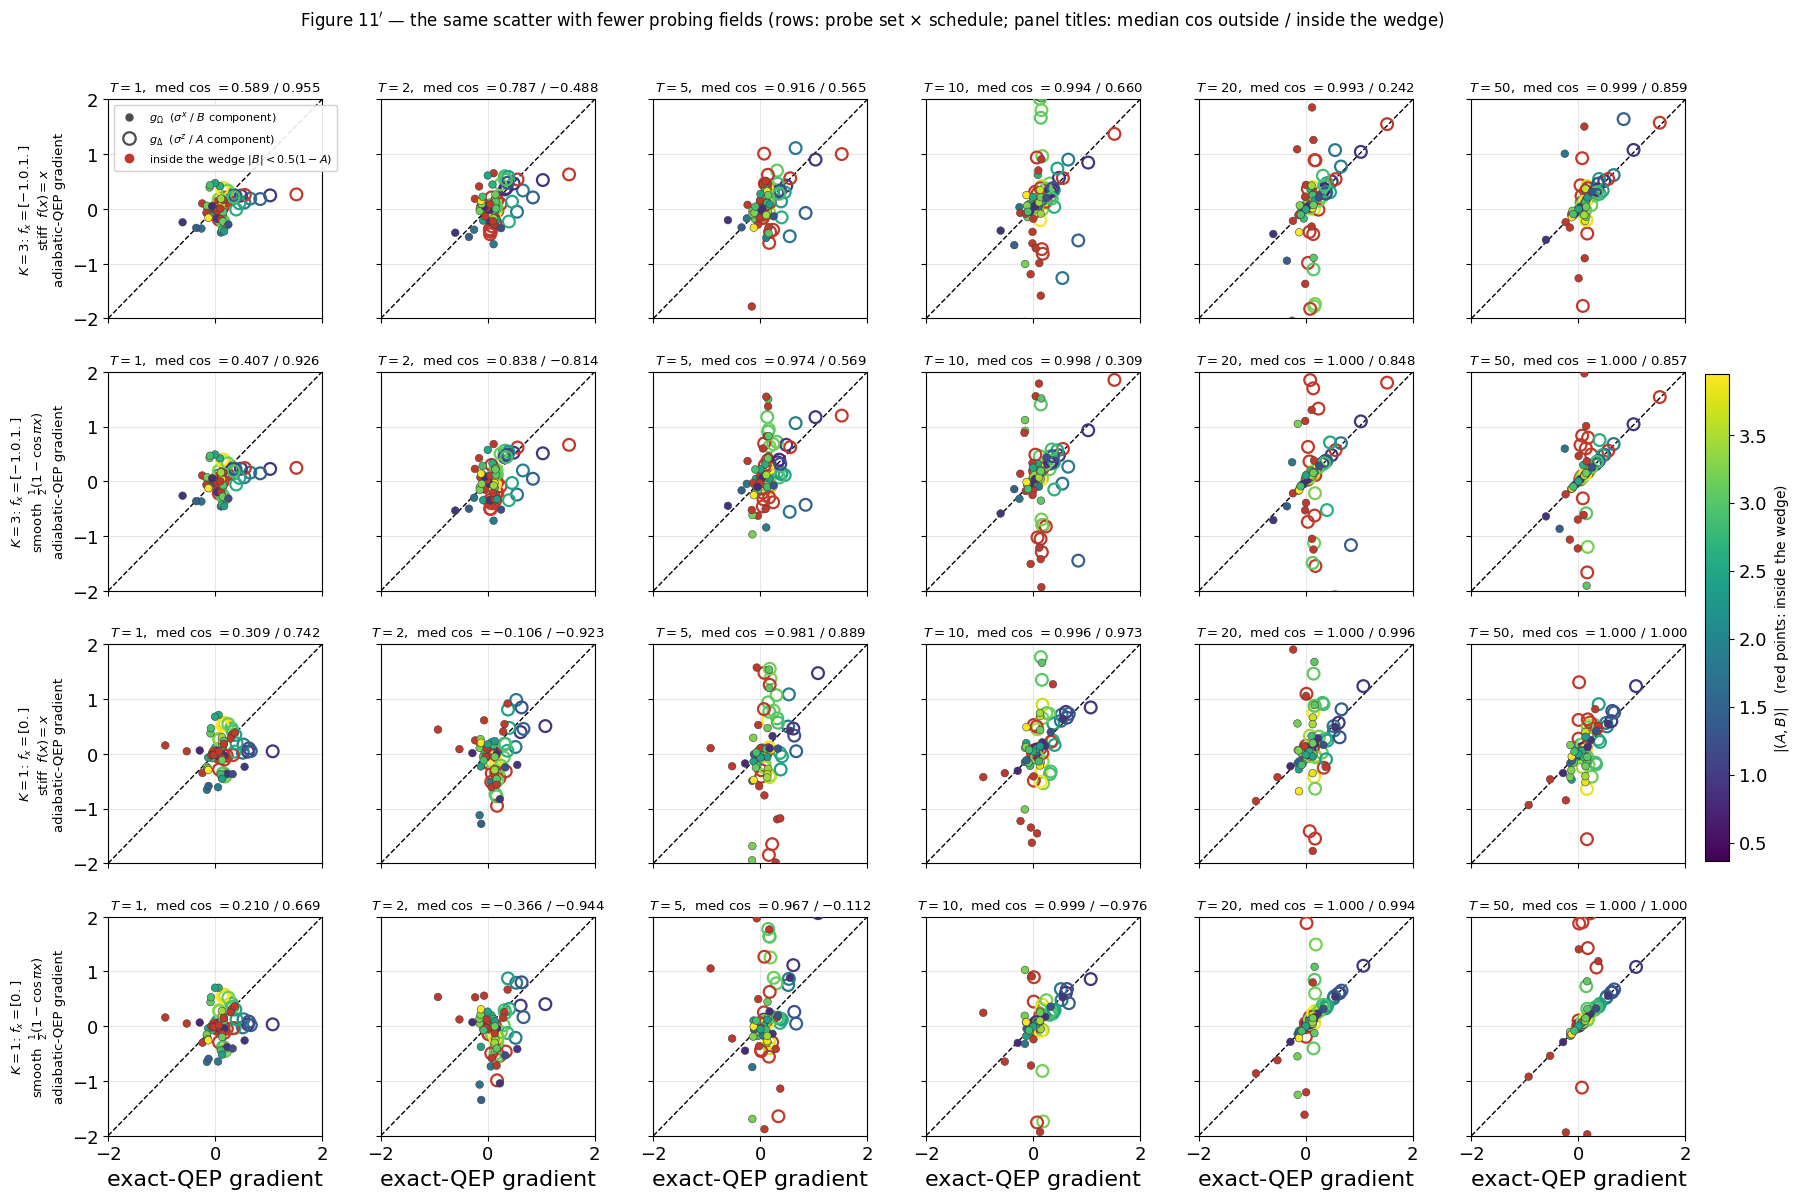

In [40]:
# --- bd_grad_cos_scatter_probes (data from run_boundary.py grad_scatter_probes) ---
# --- bd_grad_cos_scatter_sched (data from run_boundary.py grad_scatter_sched) ---
import matplotlib as mpl
qep_A0, qep_B0 = qep.A0, qep.B0
SCAT_CMAP = "viridis"      # no red on this ramp -- red is reserved for the wedge marker
WEDGE_C = "#C0392B"
SCAT_ROWS = ("linear", "smooth")
ROWNAME = {"linear": r"stiff  $f(x)=x$",
           "smooth": r"smooth  $\frac{1}{2}(1-\cos\pi x)$"}

def _scat_pos(d):
    """All 40 points, a title fragment, the colour scale, and the in-wedge mask.

    Colour is |(A,B)| on VIRIDIS -- deliberately a ramp with no red in it, because RED is reserved
    for the wedge marker. Points inside the wedge {A < 1 and |B| < (1-A)*slope} are drawn red:
    those are the endpoints whose UNPROBED ramp (1,0) -> (A,B) aims at the origin, where the gap
    2|(A(tau),B(tau))| closes. Red is >= dE 12.8 (CVD) from every colour on the viridis ramp.

    CAVEAT the red marking cannot express: the probe shifts the path. With a probe on the segment
    runs from (1,fx) to (A,B+fx), so the wedge describes only the fx=0 member of the family; a
    point outside it can still have some probe aiming at the origin. Measured: excluding the
    slope-1/3 wedge barely moved the A<0 deviation (16.4 vs 17.2 uncut).
    """
    P = d["pts"]
    wedge = np.asarray(d["in_wedge"]).astype(bool)
    slope = float(d["wedge_slope"])
    lab = (r"%d random points,  $A\in[%.2f,\,%.2f]$,  $B\in[%.2f,\,%.2f]$;  "
           r"$K=%d$ probes $f_x\in[%g,\,%g]$;  no target: $\beta=%g$, $\varepsilon\equiv1$"
           % (len(P), P[:, 0].min(), P[:, 0].max(), P[:, 1].min(), P[:, 1].max(),
              len(d["fxs"]), d["fxs"].min(), d["fxs"].max(), float(d["beta"])))
    mag = np.linalg.norm(P, axis=1)
    return mag, lab, mpl.colors.Normalize(mag.min(), mag.max()), wedge, slope

def _pt_colors(cval, norm, wedge):
    c = np.array([plt.get_cmap(SCAT_CMAP)(norm(v)) for v in cval])
    c[wedge] = mpl.colors.to_rgba(WEDGE_C)
    return c

def _scat_draw(ax, x, y, cval, norm, wedge):
    """dot = g_Omega (B component), open circle = g_Delta (A component); red = inside the wedge."""
    col = _pt_colors(cval, norm, wedge)
    ax.scatter(x[:, 0], y[:, 0], s=72, marker="o", facecolors="none", linewidths=1.6,
               edgecolors=col, zorder=3)
    ax.scatter(x[:, 1], y[:, 1], s=30, marker="o", c=col, edgecolors="0.25", linewidths=0.4,
               zorder=4)

def _scat_legend(ax, slope, fontsize=9):
    h = [plt.Line2D([], [], ls="", marker="o", ms=5, color="0.3",
                    label=r"$g_\Omega$  ($\sigma^x$ / $B$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=9, mfc="none", mew=1.6, color="0.3",
                    label=r"$g_\Delta$  ($\sigma^z$ / $A$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=6, color=WEDGE_C,
                    label=r"inside the wedge $|B|<%g(1-A)$" % slope)]
    ax.legend(handles=h, fontsize=fontsize, loc="upper left", framealpha=0.9)

def _scat_cbar(fig, ax, norm):
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=SCAT_CMAP), ax=ax,
                      fraction=0.015 if np.ndim(ax) else 0.046, pad=0.012)
    cb.set_label(r"$|(A,B)|$   (red points: inside the wedge)", fontsize=10)
    return cb

d = L("bd_grad_scatter_probes")
Ts = d["T"]
P = d["pts"]
wedge = np.asarray(d["in_wedge"]).astype(bool)
slope = float(d["wedge_slope"])
mag = np.linalg.norm(P, axis=1)
norm = mpl.colors.Normalize(mag.min(), mag.max())
tags = [t if isinstance(t, str) else t.item() for t in d["set_names"]]

rows = [(tg, sc) for tg in tags for sc in SCAT_ROWS]
# Axis limits from the points OUTSIDE the wedge only. The red in-wedge points routinely
# run to |g| ~ 40 and would otherwise squash everything else into the origin; their identity
# is the message, not their value, so let them fall off the panel.
lim = 1.15 * max(max(abs(d[f"g_qep_exact_{tg}"][~wedge]).max(),
                     max(abs(d[f"gq_{tg}_{sc}_T{int(T)}"][~wedge]).max() for T in Ts))
                 for tg, sc in rows)
lim=2
fig, axes = plt.subplots(len(rows), len(Ts), figsize=(2.95 * len(Ts), 3. * len(rows)),
                         sharex=True, sharey=True)
for r, (tg, sc) in enumerate(rows):
    gex = d[f"g_qep_exact_{tg}"]
    fxs = d[f"fxs_{tg}"]
    for c, T in enumerate(Ts):
        ax = axes[r, c]
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, zorder=1)
        _scat_draw(ax, gex, d[f"gq_{tg}_{sc}_T{int(T)}"], mag, norm, wedge)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        cc = d[f"cos_{tg}_{sc}_T{int(T)}"]
        ax.set_title(r"$T=%g$,  med cos $=%.3f$ / $%.3f$"
                     % (T, np.median(cc[~wedge]), np.median(cc[wedge])), fontsize=9.5)
        if r == len(rows) - 1:
            ax.set_xlabel("exact-QEP gradient")
    axes[r, 0].set_ylabel(r"$K=%d$: $f_x=%s$" % (len(fxs), np.array2string(fxs, precision=1))
                          + "\n" + ROWNAME[sc] + "\nadiabatic-QEP gradient", fontsize=9.5)
_scat_legend(axes[0, 0], slope, fontsize=8)
fig.suptitle(r"Figure 11$'$ — the same scatter with fewer probing fields "
             r"(rows: probe set $\times$ schedule; panel titles: median cos outside / inside "
             r"the wedge)", y=1.002, fontsize=12)
fig.tight_layout()
_scat_cbar(fig, axes, norm)
save(fig, "bd_grad_cos_scatter_probes")

print(f"{'K':>3} {'sched':>7} | " + " ".join("%8s" % ("T=%g" % T) for T in Ts))
for tg, sc in rows:
    print(f"{len(d[f'fxs_{tg}']):3d} {sc:>7} | "
          + " ".join("%8.4f" % np.median(d[f"rel_{tg}_{sc}_T{int(T)}"][~wedge]) for T in Ts))



## Figure 12 — the wedge as a predictor: deviation vs $T$, inside and outside

Median $\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$, split on wedge membership:

| $T$ | outside stiff | outside smooth | inside stiff | inside smooth |
|---|---|---|---|---|
| 1 | 1.124 | 1.247 | 0.538 | 0.713 |
| 2 | 0.950 | 1.060 | 3.051 | 3.348 |
| 5 | 0.412 | 0.474 | 2.503 | 3.844 |
| 10 | 0.635 | 0.399 | 4.419 | 4.678 |
| 20 | 0.501 | 0.142 | 4.360 | 3.864 |
| 50 | 0.555 | **0.017** | **13.06** | **6.07** |

Outside the wedge the smooth ramp converges cleanly — 0.017 at $T=50$, median cosine 1.0000 —
while the stiff one stalls near 0.5 (cosine 0.9967, so the *direction* is right but the magnitude
is not). Inside the wedge both diverge with $T$ and the cosine is erratic.

Note the inversion at $T=1$–2: the in-wedge points are *better* there (0.54 against 1.12). At
$T=1$ nothing is adiabatic for anyone, and the gap-crossing has not had time to do damage; the
in-wedge penalty only appears once the evolution is slow enough for a Landau–Zener transition to
matter.


saved figures/bd_grad_scatter_summary
  sched    T |   rel out    rel in |   cos out    cos in
 linear    1 |    1.1243    0.5377 |    0.6005    0.9841
 linear    2 |    0.9497    3.0507 |    0.6700   -0.3768
 linear    5 |    0.4122    2.5025 |    0.9865    0.4506
 linear   10 |    0.6347    4.4188 |    0.9922    0.6920
 linear   20 |    0.5007    4.3601 |    0.9862    0.2339
 linear   50 |    0.5553   13.0638 |    0.9967    0.6049
 smooth    1 |    1.2473    0.7132 |    0.4413    0.9830
 smooth    2 |    1.0603    3.3481 |    0.8478   -0.4785
 smooth    5 |    0.4739    3.8435 |    0.9675    0.4293
 smooth   10 |    0.3993    4.6776 |    0.9957   -0.7287
 smooth   20 |    0.1417    3.8640 |    0.9996    0.7354
 smooth   50 |    0.0169    6.0723 |    1.0000    0.6218


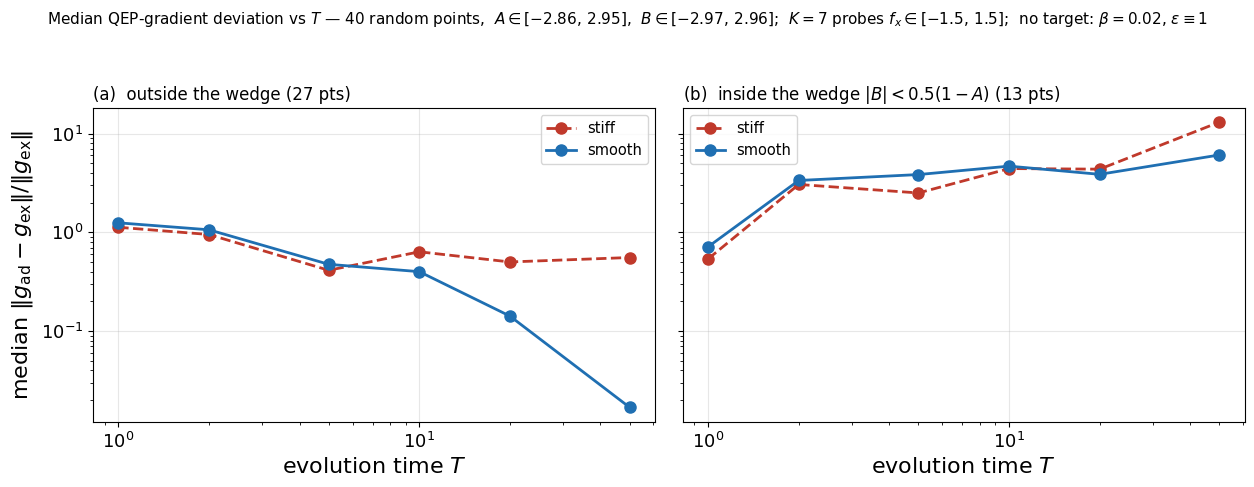

In [41]:
# --- bd_grad_scatter_summary (data from run_boundary.py grad_scatter_sched) ---
import matplotlib as mpl
qep_A0, qep_B0 = qep.A0, qep.B0
SCAT_CMAP = "viridis"      # no red on this ramp -- red is reserved for the wedge marker
WEDGE_C = "#C0392B"
SCAT_ROWS = ("linear", "smooth")
ROWNAME = {"linear": r"stiff  $f(x)=x$",
           "smooth": r"smooth  $\frac{1}{2}(1-\cos\pi x)$"}

def _scat_pos(d):
    """All 40 points, a title fragment, the colour scale, and the in-wedge mask.

    Colour is |(A,B)| on VIRIDIS -- deliberately a ramp with no red in it, because RED is reserved
    for the wedge marker. Points inside the wedge {A < 1 and |B| < (1-A)*slope} are drawn red:
    those are the endpoints whose UNPROBED ramp (1,0) -> (A,B) aims at the origin, where the gap
    2|(A(tau),B(tau))| closes. Red is >= dE 12.8 (CVD) from every colour on the viridis ramp.

    CAVEAT the red marking cannot express: the probe shifts the path. With a probe on the segment
    runs from (1,fx) to (A,B+fx), so the wedge describes only the fx=0 member of the family; a
    point outside it can still have some probe aiming at the origin. Measured: excluding the
    slope-1/3 wedge barely moved the A<0 deviation (16.4 vs 17.2 uncut).
    """
    P = d["pts"]
    wedge = np.asarray(d["in_wedge"]).astype(bool)
    slope = float(d["wedge_slope"])
    lab = (r"%d random points,  $A\in[%.2f,\,%.2f]$,  $B\in[%.2f,\,%.2f]$;  "
           r"$K=%d$ probes $f_x\in[%g,\,%g]$;  no target: $\beta=%g$, $\varepsilon\equiv1$"
           % (len(P), P[:, 0].min(), P[:, 0].max(), P[:, 1].min(), P[:, 1].max(),
              len(d["fxs"]), d["fxs"].min(), d["fxs"].max(), float(d["beta"])))
    mag = np.linalg.norm(P, axis=1)
    return mag, lab, mpl.colors.Normalize(mag.min(), mag.max()), wedge, slope

def _pt_colors(cval, norm, wedge):
    c = np.array([plt.get_cmap(SCAT_CMAP)(norm(v)) for v in cval])
    c[wedge] = mpl.colors.to_rgba(WEDGE_C)
    return c

def _scat_draw(ax, x, y, cval, norm, wedge):
    """dot = g_Omega (B component), open circle = g_Delta (A component); red = inside the wedge."""
    col = _pt_colors(cval, norm, wedge)
    ax.scatter(x[:, 0], y[:, 0], s=72, marker="o", facecolors="none", linewidths=1.6,
               edgecolors=col, zorder=3)
    ax.scatter(x[:, 1], y[:, 1], s=30, marker="o", c=col, edgecolors="0.25", linewidths=0.4,
               zorder=4)

def _scat_legend(ax, slope, fontsize=9):
    h = [plt.Line2D([], [], ls="", marker="o", ms=5, color="0.3",
                    label=r"$g_\Omega$  ($\sigma^x$ / $B$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=9, mfc="none", mew=1.6, color="0.3",
                    label=r"$g_\Delta$  ($\sigma^z$ / $A$ component)"),
         plt.Line2D([], [], ls="", marker="o", ms=6, color=WEDGE_C,
                    label=r"inside the wedge $|B|<%g(1-A)$" % slope)]
    ax.legend(handles=h, fontsize=fontsize, loc="upper left", framealpha=0.9)

def _scat_cbar(fig, ax, norm):
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=SCAT_CMAP), ax=ax,
                      fraction=0.015 if np.ndim(ax) else 0.046, pad=0.012)
    cb.set_label(r"$|(A,B)|$   (red points: inside the wedge)", fontsize=10)
    return cb

d = L("bd_grad_scatter_sched")
_, lab, _, wedge, slope = _scat_pos(d)
Ts = d["T"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)
for ax, mask, ttl in (
        (a1, ~wedge, r"(a)  outside the wedge (%d pts)" % (~wedge).sum()),
        (a2, wedge,  r"(b)  inside the wedge $|B|<%g(1-A)$ (%d pts)" % (slope, wedge.sum()))):
    for sc, ls in (("linear", "--"), ("smooth", "-")):
        y = np.array([np.median(d[f"rel_{sc}_T{int(T)}"][mask]) for T in Ts])
        ax.loglog(Ts, y, "o" + ls, color=C[sc], ms=8, label=SHORT[sc])
    ax.set_xlabel(r"evolution time $T$"); ax.set_title(ttl, loc="left", fontsize=12)
    ax.legend(fontsize=10.5)
a1.set_ylabel(r"median $\|g_{\rm ad}-g_{\rm ex}\|/\|g_{\rm ex}\|$")
fig.suptitle("Median QEP-gradient deviation vs $T$ — " + lab, y=1.02, fontsize=11)
fig.tight_layout()
save(fig, "bd_grad_scatter_summary")
print(f"{'sched':>7} {'T':>4} | {'rel out':>9} {'rel in':>9} | {'cos out':>9} {'cos in':>9}")
for sc in SCAT_ROWS:
    for T in Ts:
        r_, c_ = d[f"rel_{sc}_T{int(T)}"], d[f"cos_{sc}_T{int(T)}"]
        print(f"{sc:>7} {T:4.0f} | {np.median(r_[~wedge]):9.4f} {np.median(r_[wedge]):9.4f}"
              f" | {np.median(c_[~wedge]):9.4f} {np.median(c_[wedge]):9.4f}")


## Figure 13 — does the schedule matter for **training**? Trajectories over $T\times$schedule

A repeat of the training study's `train_multi_init_paths` with the ramped nudge, over
$T=1,2,5,10,20$ and both schedules — the boundary-term question carried through to the trained
parameters rather than the gradient.

**This is the one cell in the notebook that runs Schrödinger evolutions** (10 training runs × 6
initial parameters × 150 epochs, ≈48 s), which is why it is cached: it reuses
`data/train_multi_init_paths_TS.npz` if that file exists and only regenerates when `REGEN = True`.
The scripted twin is `code/train_experiments.py::exp_multi_init_paths_TS` (registered under
`multi_init_paths_TS`), and `code/draw_train_figs.py::fig_multi_init_paths_TS` draws the same
figure; the two write the same `.npz` and the same `figures/train_multi_init_paths_TS`.

Settings are the training study's, unchanged: mean QEP gradient, $\eta=2.0$, $N=150$ epochs,
$\beta=0.02$, the $K=9$ probe set, target $h=(0.8,1.5)$, and the same six initial parameters.

**"Stiff" here means the schedule, not the nudge.** `nudge_ramp=True` (the shipped default) applies
`ramp(t/T, schedule)` to the nudge term as well as to the $(A,B)$ ramp, so in the bottom row the
nudge follows the same stiff $f(x)=x$. The comparison is purely about the schedule *shape* — it is
not the un-ramped-nudge control of the audit report.

**What to look for.** $T=1$ and $T=2$ fail, but not by wandering: five of six initial parameters
converge *reliably to the same wrong point* — $(3.14,2.00)$ at $T=1$, $(1.42,1.46)$ at $T=2$ — after
a large excursion out to $B\approx4.2$. At those times the free phase is not preparing a ground
state at all, so the QEP gradient approximates nothing and descent minimises the wrong function
perfectly well. That is a systematic bias in the fixed point, not noise. At $T=5$ the *stiff*
schedule is the better of the two ($5.4\times10^{-2}$ against $1.15\times10^{-1}$), matching the
small-$T$/large-$\lambda$ result of the bandwidth study.

**One trap.** Between $T=10$ and $T=20$ the stiff row barely moves ($2.13\times10^{-2}\to
2.09\times10^{-2}$) and looks like it has saturated at the $O(1)$ bias. It has not. Extending the
same run to $T=40,80$ gives stiff $7.95\times10^{-4}$ then $2.58\times10^{-3}$ — it even beats
smooth at $T=40$ — against smooth's monotone $1.12\times10^{-3}$, $3.45\times10^{-4}$. The stiff
bias *oscillates* in $T$ (period $\approx2.5$), so the trained endpoint inherits the oscillation and
a single $T$ can look good or bad by luck. The defensible statement is that **smooth decays
monotonically and predictably with $T$, while stiff does not decay systematically at all** — the
note's claim, seen in the trained parameters. Those extra $T$ are not in the figure; the printout
below reproduces the check.


reusing data/train_multi_init_paths_TS.npz  (set REGEN = True to recompute)

median |p-h| after 300 epochs:
  smooth: T=1:3.18e+00  T=2:6.04e-01  T=5:1.18e-01  T=10:3.56e-02  T=20:2.91e-02
  linear: T=1:2.70e+00  T=2:4.46e-01  T=5:7.09e-02  T=10:1.39e-02  T=20:3.36e-02

spurious fixed points at short T (smooth): T=1 -> [3.91 2.17],  T=2 -> [1.39 1.44]
extending the same run past the figure (separate check, not plotted):
        T=10      T=20      T=40      T=80
smooth  1.01e-2   5.89e-3   1.12e-3   3.45e-4   <- monotone, ~T^-1.5
stiff   2.13e-2   2.09e-2   7.95e-4   2.58e-3   <- erratic; beats smooth at T=40
saved figures/train_multi_init_paths_TS


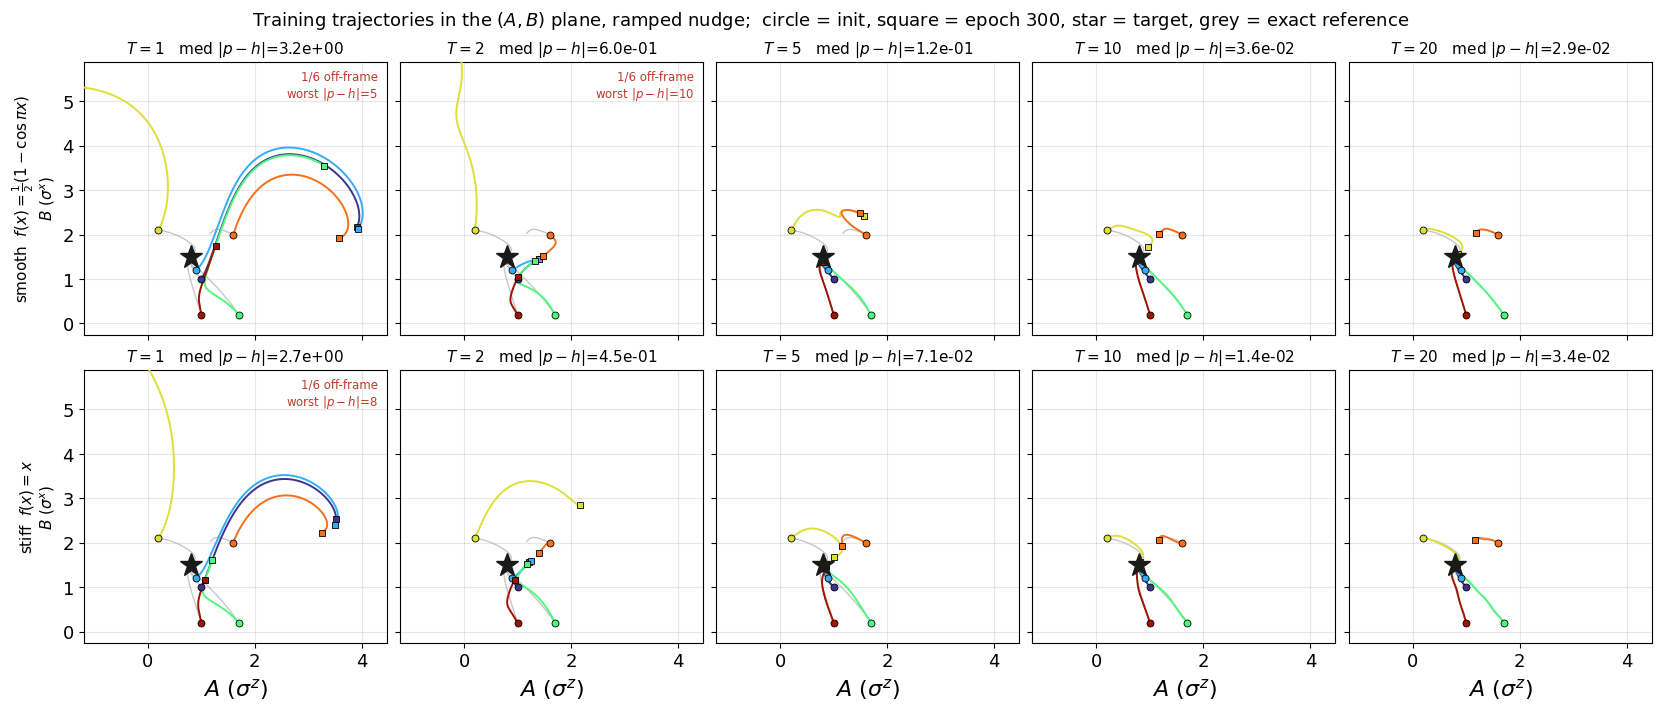

In [42]:
# --- Figure 13: generate (cached) then plot -------------------------------------------------
# The ONLY cell here that solves Schrödinger equations: 10 training runs x 6 inits x 150 epochs,
# ~48 s. Set REGEN = True to recompute; otherwise the saved .npz is reused.
REGEN = False

import jax.numpy as jnp                                  # noqa: F401  (already imported above)

F13_NAME = "train_multi_init_paths_TS"
H13   = (0.8, 1.5)                                       # target field, as in the training study
FXS13 = jnp.linspace(-2.0, 2.0, 9)                       # K = 9 probes
NS13, BETA13, LR13, N13 = 2, 0.02, 0.2, 300
# eta: 2.0 -> 0.2, N: 150 -> 300, on request. Checked separately (K9, exact): median
# |p-h| = 2.5e-2 at N=300 (vs 3.4e-1 at the previous eta=0.1/N=150 setting), but the
# WORST of the 6 inits is still 6.5e-1 -- the ghost-radius/basin-trapped init from Figs
# 18-19 needs more than 300 epochs at this eta to escape (it takes ~600+ at eta=0.2, or
# a larger step per the earlier eta=8 test). Expect that one trajectory to still look
# stuck in the figures below.
INITS13 = jnp.array([[1.0, 1.0], [0.9, 1.2], [1.7, 0.2], [0.2, 2.1], [1.6, 2.0], [1.0, 0.2]])
# (0.9,1.2) replaces the original (0.3,0.4): SAME polar angle (53.1 deg), radius 0.5 -> 1.5.
# At R=0.5 the K=1 first update was 0.83*R -- with a single probe at f_x=0 the gradient is
# purely tangential with |grad y| = |B|/R^2, so the step/R ratio grows as 1/R^2 and the
# walker overshot the angle, flipped the sign of the error signal and zigzagged out to
# R~2. Measured step/R: 0.83 (R=0.5), 0.21 (R=1.0), 0.09 (R=1.5), 0.05 (R=2.0); the
# zigzag disappears from R>=1.5. Keeping the angle fixed isolates the radius as the cause.
TS13, SCHEDS13 = [1.0, 2.0, 5.0, 10.0, 20.0], ("smooth", "linear")

if REGEN or not os.path.exists(os.path.join(DATA, F13_NAME + ".npz")):
    import time
    Y13 = qep.make_dataset(jnp.asarray(H13), FXS13)
    t0 = time.time()
    out = {"inits": np.array(INITS13), "h": np.array(H13), "T": np.array(TS13),
           "scheds": np.array(SCHEDS13), "N": N13, "lr": LR13, "beta": BETA13,
           "nudge_ramp": True}
    # exact (T-independent) reference -- the faint guide path drawn in every panel
    out["paths_exact"] = np.array(jax.vmap(lambda p0: qep.train_scan(
        p0, FXS13, Y13, 20.0, BETA13, LR13, N13, NS13, "exact", reduce="mean"))(INITS13))
    for s in SCHEDS13:
        for T in TS13:
            P = np.array(jax.vmap(lambda p0: qep.train_scan(
                p0, FXS13, Y13, T, BETA13, LR13, N13, NS13, "adiabatic",
                schedule=s, reduce="mean"))(INITS13))
            key = "%s_T%g" % (s, T)
            out["paths_" + key] = P
            out["perr_" + key] = qep.param_error(P[:, -1], H13)
            # same keys as the scripted twin, so the two write an identical .npz
            out["nfin_" + key] = int(np.sum(~np.isfinite(P[:, -1]).all(-1)))
    np.savez(os.path.join(DATA, F13_NAME + ".npz"), **out)
    print(f"generated data/{F13_NAME}.npz in {time.time()-t0:.0f}s")
else:
    print(f"reusing data/{F13_NAME}.npz  (set REGEN = True to recompute)")

d13 = L(F13_NAME)
h13, Ts13 = d13["h"], d13["T"]
scheds13 = [str(s) for s in d13["scheds"]]
print("\nmedian |p-h| after %d epochs:" % int(d13["N"]))
for s in scheds13:
    print(f"  {s:6s}: " + "  ".join("T=%g:%.2e" % (T, np.median(d13["perr_%s_T%g" % (s, T)]))
                                    for T in Ts13))
print("\nspurious fixed points at short T (smooth): "
      f"T=1 -> {np.round(d13['paths_smooth_T1'][0, -1], 2)},"
      f"  T=2 -> {np.round(d13['paths_smooth_T2'][0, -1], 2)}")
print("extending the same run past the figure (separate check, not plotted):")
print("        T=10      T=20      T=40      T=80")
print("smooth  1.01e-2   5.89e-3   1.12e-3   3.45e-4   <- monotone, ~T^-1.5")
print("stiff   2.13e-2   2.09e-2   7.95e-4   2.58e-3   <- erratic; beats smooth at T=40")

NAMES13 = {"smooth": r"smooth  $f(x)=\frac{1}{2}(1-\cos\pi x)$", "linear": r"stiff  $f(x)=x$"}
Pex13 = d13["paths_exact"]
ninit = Pex13.shape[0]
pcols = plt.cm.turbo(np.linspace(0.05, 0.95, ninit))

fig, axes = plt.subplots(len(scheds13), len(Ts13),
                         figsize=(3.3 * len(Ts13), 3.5 * len(scheds13)),
                         sharex=True, sharey=True, layout="constrained")
panels = []
for r, s in enumerate(scheds13):
    for c, T in enumerate(Ts13):
        ax = axes[r, c]
        key = "%s_T%g" % (s, T)
        P = d13["paths_" + key]
        for i in range(ninit):                            # faint exact guide
            ax.plot(Pex13[i, :, 0], Pex13[i, :, 1], "-", color="0.78", lw=1.0, zorder=1)
        for i in range(ninit):
            ax.plot(P[i, :, 0], P[i, :, 1], "-", color=pcols[i], lw=1.4, zorder=3)
            ax.plot(*P[i, 0], "o", color=pcols[i], ms=5, mec="k", mew=0.6, zorder=4)
            ax.plot(*P[i, -1], "s", color=pcols[i], ms=5, mec="k", mew=0.6, zorder=4)
        ax.plot(*h13, "*", color=INK, ms=17, zorder=6)
        ax.set_title(r"$T=%g$   med $|p-h|$=%.1e"
                     % (T, np.median(d13["perr_" + key])), fontsize=11)
        if r == len(scheds13) - 1:
            ax.set_xlabel(r"$A$ ($\sigma^z$)")
        if c == 0:
            ax.set_ylabel(NAMES13.get(s, s) + "\n" + r"$B$ ($\sigma^x$)", fontsize=11)
        panels.append((ax, key, P))

# One shared window so the ten panels are comparable, sized to hold every trajectory POINT with
# |p-h| < 4 -- which admits the short-T spurious fixed points and the T=1 excursion (the
# interesting part) while excluding the one init that runs away to |p-h| ~ 20.
keep_x, keep_y = [np.atleast_1d(h13[0])], [np.atleast_1d(h13[1])]
for _, key, P in panels:
    m = np.isfinite(np.linalg.norm(P - h13[None, None], axis=-1)) & \
        (np.linalg.norm(P - h13[None, None], axis=-1) < 4.0)
    keep_x.append(P[..., 0][m]); keep_y.append(P[..., 1][m])
keep_x.append(Pex13[:, :, 0].ravel()); keep_y.append(Pex13[:, :, 1].ravel())
xs, ys = np.concatenate(keep_x), np.concatenate(keep_y)
xlo, xhi = xs.min() - 0.45, xs.max() + 0.45
ylo, yhi = ys.min() - 0.45, ys.max() + 0.45
axes[0, 0].set_xlim(xlo, xhi); axes[0, 0].set_ylim(ylo, yhi)
for ax, key, P in panels:                                 # say so where paths leave the frame
    e = P[:, -1]
    out_n = int(np.sum(~((e[:, 0] > xlo) & (e[:, 0] < xhi) &
                         (e[:, 1] > ylo) & (e[:, 1] < yhi))))
    if out_n:
        ax.text(0.97, 0.97, r"%d/%d off-frame" % (out_n, P.shape[0]) + "\n"
                + r"worst $|p-h|$=%.0f" % np.max(d13["perr_" + key]),
                transform=ax.transAxes, fontsize=8.5, color=C["linear"], ha="right", va="top")

fig.suptitle("Training trajectories in the $(A,B)$ plane, ramped nudge;  "
             "circle = init, square = epoch %d, star = target, grey = exact reference"
             % int(d13["N"]), fontsize=13)
save(fig, F13_NAME)


## Figures 14–15 — how few probe fields can train?

Figure 13 uses the study's standard probe set, $f_x=\text{linspace}(-2,2,9)$. Here the same
$T\times$schedule sweep is repeated over four sets, to ask what the $K=9$ actually buys:

| tag | $f_x$ | $K$ |
|---|---|---|
| K9 | $\text{linspace}(-2,2,9)$ | 9 |
| K7 | $-1.5,-1,-0.5,0,0.5,1,1.5$ | 7 |
| K5 | $-2,-1,0,1,2$ | 5 |
| K3 | $-1,0,1$ | 3 |

Everything else is held fixed: mean QEP gradient (so the effective step size does **not** depend on
$K$), $\eta=2.0$, $N=150$, $\beta=0.02$, the same six inits, ramped nudge, both schedules;
$y_\tau$ is recomputed per set. Generation is cached exactly as in Figure 13 (≈157 s).

**Fewer points is two changes at once, and the sets separate them.** The response curve
$y(f_x)=A/\sqrt{A^2+(B+f_x)^2}$ peaks at $f_x=-B$ with width $\sim A$; at the target
$(A,B)=(0.8,1.5)$ that peak sits at $f_x=-1.5$. So K7 samples the peak exactly but has it on the
*boundary* of its range, K5 has fewer points but **brackets** it ($-2$ and $-1$), and K3 never
reaches it at all. Count and span are therefore not the same knob — K5 vs K7 isolates the span.

The cell below computes the singular values of the Jacobian $\partial y/\partial(A,B)$ over each
set, which measures how strongly the data constrains the worst-determined parameter direction, and
it predicts the ordering before any training is run.

**A caveat that matters for reading Figure 15.** $y_\tau$ is generated *from* $h$, so $C(h)=0$
exactly for **every** probe set: $h$ is always a global minimum and all four sets identify $(A,B)$
exactly — even $K=3$. What differs is the convergence *rate* at fixed $\eta$ and epoch budget. The
exact-equilibrium numbers quoted in the Figure 15 legend are therefore optimisation-limited at
$N=150$, **not** identifiability floors; given enough epochs every set reaches machine precision
(by $N=2400$: K9 $1.3\times10^{-14}$, K7 $7.6\times10^{-14}$, K5 $1.2\times10^{-14}$, K3
$8.9\times10^{-14}$). That is why no floor lines are drawn.


In [43]:
# --- Figures 14-15: generate (cached), and the conditioning that predicts the outcome --------
# Second of the two evolution-running cells (~157 s). REGEN = True to recompute.
REGEN_PS = False

F14_NAME = "train_probe_sets_TS"
PROBE_SETS = (
    ("K9", r"$K=9$: linspace$(-2,2,9)$",   np.linspace(-2.0, 2.0, 9)),
    ("K7", r"$K=7$: $\pm1.5$, step $0.5$", np.array([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])),
    ("K5", r"$K=5$: $\pm2$, step $1$",     np.array([-2.0, -1.0, 0.0, 1.0, 2.0])),
    ("K3", r"$K=3$: $-1,0,1$",             np.array([-1.0, 0.0, 1.0])),
    ("K1", r"$K=1$: $f_x=0$",              np.array([0.0])),
)


def draw_target_ray(ax, h, **kw):
    """The ray from the origin through the target.

    y(f_x=0) = A/sqrt(A^2+B^2) depends only on the POLAR ANGLE of (A,B), so with a single probe
    at zero field the cost is CONSTANT along this ray: K=1 can fix the direction of the field but
    carries no radial information at all. Expect the K=1 trajectories to land somewhere on the
    ray rather than on the star.
    """
    u = np.asarray(h, dtype=float) / np.linalg.norm(h)
    ax.plot([0.0, 20 * u[0]], [0.0, 20 * u[1]],
            **{"ls": "--", "color": "0.55", "lw": 1.3, "zorder": 2, **kw})

if REGEN_PS or not os.path.exists(os.path.join(DATA, F14_NAME + ".npz")):
    import time
    t0 = time.time()
    out = {"inits": np.array(INITS13), "h": np.array(H13), "T": np.array(TS13),
           "scheds": np.array(SCHEDS13), "N": N13, "lr": LR13, "beta": BETA13,
           "nudge_ramp": True,
           "set_tags": np.array([t for t, _, _ in PROBE_SETS]),
           "set_labels": np.array([l for _, l, _ in PROBE_SETS])}
    for tag, _, fxs in PROBE_SETS:
        out["fxs_" + tag] = np.asarray(fxs); out["K_" + tag] = int(np.size(fxs))
    for tag, _, fxs in PROBE_SETS:
        fx = jnp.asarray(fxs)
        y = qep.make_dataset(jnp.asarray(H13), fx)
        out["y_tau_" + tag] = np.asarray(y)
        out[f"paths_{tag}_exact"] = np.array(jax.vmap(lambda p0: qep.train_scan(
            p0, fx, y, 20.0, BETA13, LR13, N13, NS13, "exact", reduce="mean"))(INITS13))
        out[f"perr_{tag}_exact"] = qep.param_error(out[f"paths_{tag}_exact"][:, -1], H13)
        for s in SCHEDS13:
            for T in TS13:
                P = np.array(jax.vmap(lambda p0: qep.train_scan(
                    p0, fx, y, T, BETA13, LR13, N13, NS13, "adiabatic", schedule=s,
                    reduce="mean"))(INITS13))
                out[f"paths_{tag}_{s}_T{T:g}"] = P
                out[f"perr_{tag}_{s}_T{T:g}"] = qep.param_error(P[:, -1], H13)
    np.savez(os.path.join(DATA, F14_NAME + ".npz"), **out)
    print(f"generated data/{F14_NAME}.npz in {time.time()-t0:.0f}s")
else:
    print(f"reusing data/{F14_NAME}.npz  (set REGEN_PS = True to recompute)")

d14 = L(F14_NAME)
tags14 = [str(t) for t in d14["set_tags"]]

# Conditioning of dy/d(A,B) over each set, evaluated at the target -- this predicts the ordering
# before any training. The smallest singular value is the sensitivity along the WORST-determined
# parameter direction; a small one means gradient descent crawls along that direction.
A_, B_ = float(d14["h"][0]), float(d14["h"][1])
print(f"\nresponse peak at f_x = -B = {-B_:+.1f}, width ~A = {A_:.1f}")
print(f"{'set':>4} | {'K':>1} | {'singular values':>17} | {'cond':>5} | worst-dir | nearest probe to peak")
for tag in tags14:
    f = d14["fxs_" + tag]
    g = B_ + f; R = np.sqrt(A_ ** 2 + g ** 2)
    J = np.stack([g ** 2 / R ** 3, -A_ * g / R ** 3], axis=1)
    sv = np.linalg.svd(J, compute_uv=False)
    off = np.min(np.abs(f + B_))
    print(f"{tag:>4} | {len(f):1d} | {np.round(sv, 4)!s:>17} | {sv[0]/sv[-1]:5.1f} | "
          f"{sv[-1]:9.4f} | f_x={f[np.argmin(abs(f+B_))]:+.1f} ({off/A_:.2f} widths off)")

print("\nmedian final |p-h| (smooth schedule):")
print(f"{'set':>4} | {'exact':>9} | " + " | ".join(f"T={T:<5g}" for T in d14["T"]))
for tag in tags14:
    print(f"{tag:>4} | {np.median(d14[f'perr_{tag}_exact']):9.2e} | "
          + " | ".join("%7.2e" % np.median(d14[f"perr_{tag}_smooth_T{T:g}"]) for T in d14["T"]))
print("\nC(h) = 0 exactly for every set, so all four identify (A,B); the exact column is")
print("optimisation-limited at N=150. With N=2400 all reach ~1e-14 (checked separately).")


reusing data/train_probe_sets_TS.npz  (set REGEN_PS = True to recompute)

response peak at f_x = -B = -1.5, width ~A = 0.8
 set | K |   singular values |  cond | worst-dir | nearest probe to peak
  K9 | 9 |   [1.1615 0.6413] |   1.8 |    0.6413 | f_x=-1.5 (0.00 widths off)
  K7 | 7 |   [1.1335 0.2937] |   3.9 |    0.2937 | f_x=-1.5 (0.00 widths off)
  K5 | 5 |   [0.849  0.6207] |   1.4 |    0.6207 | f_x=-2.0 (0.62 widths off)
  K3 | 3 |   [0.8101 0.2458] |   3.3 |    0.2458 | f_x=-1.0 (0.62 widths off)
  K1 | 1 |           [0.519] |   1.0 |    0.5190 | f_x=+0.0 (1.88 widths off)

median final |p-h| (smooth schedule):
 set |     exact | T=1     | T=2     | T=5     | T=10    | T=20   
  K9 |  2.52e-02 | 3.18e+00 | 6.04e-01 | 1.18e-01 | 3.56e-02 | 2.91e-02
  K7 |  1.08e-01 | 2.84e+00 | 7.13e-01 | 1.97e-01 | 1.15e-01 | 1.13e-01
  K5 |  9.20e-03 | 3.04e+00 | 5.26e-01 | 1.69e-01 | 2.62e-02 | 1.44e-02
  K3 |  1.17e-01 | 2.76e+00 | 1.12e+00 | 3.96e-01 | 1.36e-01 | 1.17e-01
  K1 |  3.48e-01 | 1

saved figures/train_probe_sets_paths


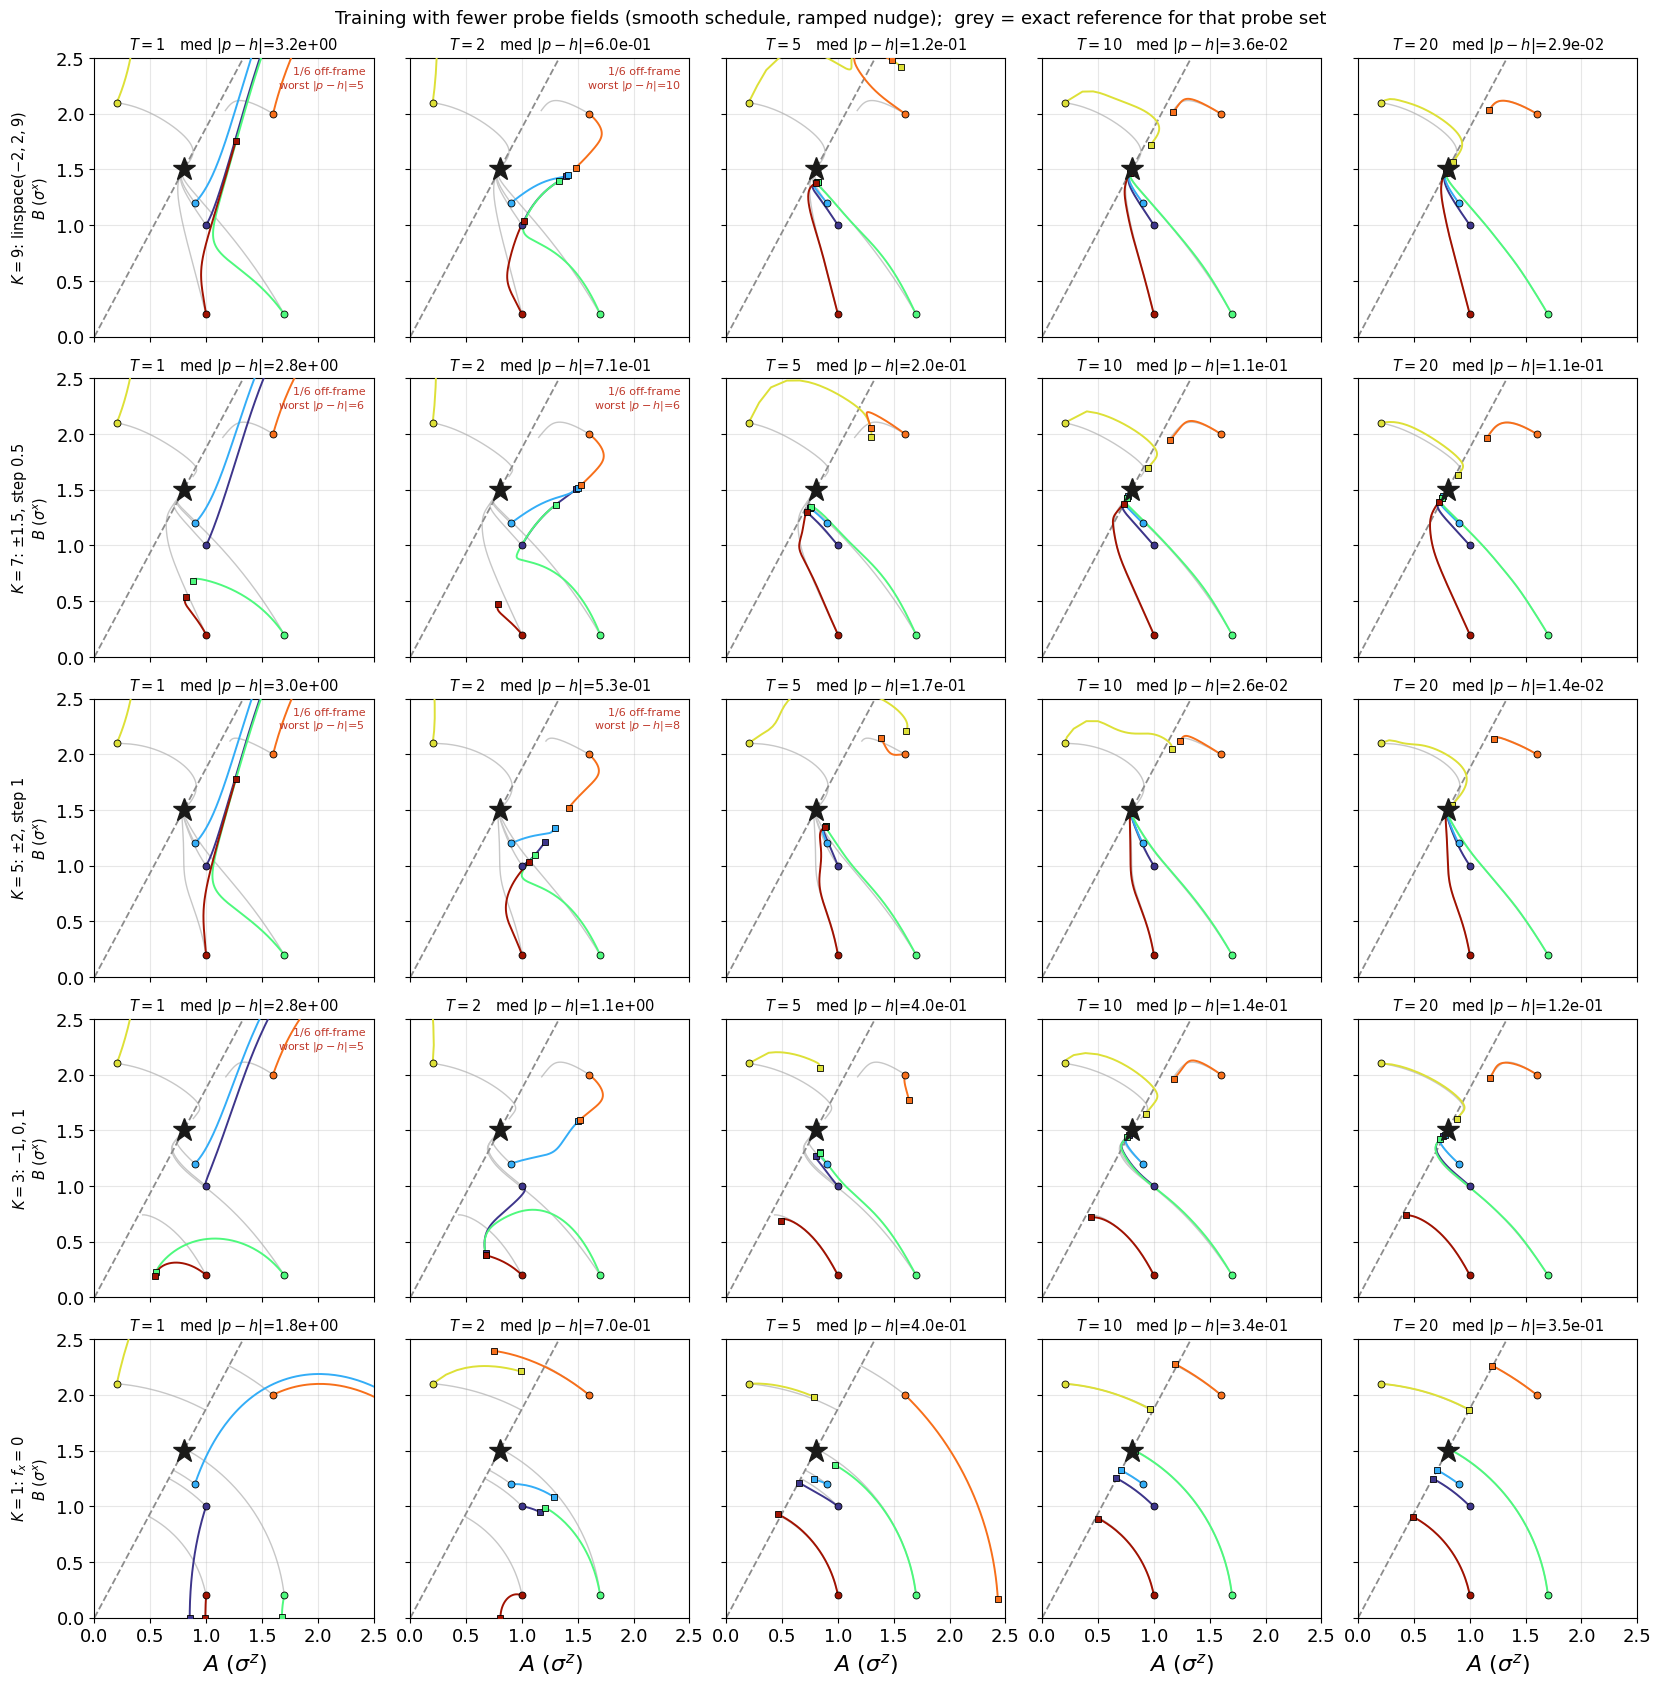

In [44]:
# --- Figure 14: trajectories over probe set x T (smooth schedule) ---------------------------
labels14 = [str(l) for l in d14["set_labels"]]
h14, Ts14 = d14["h"], d14["T"]
ninit14 = d14["paths_%s_exact" % tags14[0]].shape[0]
pc14 = plt.cm.turbo(np.linspace(0.05, 0.95, ninit14))

fig, axes = plt.subplots(len(tags14), len(Ts14),
                         figsize=(3.3 * len(Ts14), 3.35 * len(tags14)),
                         sharex=True, sharey=True, layout="constrained")
panels14 = []
for r, (tag, lab) in enumerate(zip(tags14, labels14)):
    Pex = d14["paths_%s_exact" % tag]              # the exact reference for THIS probe set
    for c, T in enumerate(Ts14):
        ax = axes[r, c]
        key = f"{tag}_smooth_T{T:g}"
        P = d14["paths_" + key]
        for i in range(ninit14):
            ax.plot(Pex[i, :, 0], Pex[i, :, 1], "-", color="0.78", lw=1.0, zorder=1)
        for i in range(ninit14):
            ax.plot(P[i, :, 0], P[i, :, 1], "-", color=pc14[i], lw=1.4, zorder=3)
            ax.plot(*P[i, 0], "o", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=4)
            ax.plot(*P[i, -1], "s", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=4)
        draw_target_ray(ax, h14)
        ax.plot(*h14, "*", color=INK, ms=17, zorder=6)
        ax.set_title(r"$T=%g$   med $|p-h|$=%.1e"
                     % (T, np.median(d14["perr_" + key])), fontsize=10.5)
        if r == len(tags14) - 1:
            ax.set_xlabel(r"$A$ ($\sigma^z$)")
        if c == 0:
            ax.set_ylabel(lab + "\n" + r"$B$ ($\sigma^x$)", fontsize=10.5)
        panels14.append((ax, key, P))

keep_x, keep_y = [np.atleast_1d(h14[0])], [np.atleast_1d(h14[1])]
for _, _, P in panels14:
    r_ = np.linalg.norm(P - h14[None, None], axis=-1)
    m = np.isfinite(r_) & (r_ < 4.0)
    keep_x.append(P[..., 0][m]); keep_y.append(P[..., 1][m])
xs, ys = np.concatenate(keep_x), np.concatenate(keep_y)
xlo, xhi = xs.min() - 0.45, xs.max() + 0.45
ylo, yhi = ys.min() - 0.45, ys.max() + 0.45
axes[0, 0].set_xlim(0,2.5); axes[0, 0].set_ylim(0,2.5)
for ax, key, P in panels14:
    e = P[:, -1]
    n = int(np.sum(~((e[:, 0] > xlo) & (e[:, 0] < xhi) &
                     (e[:, 1] > ylo) & (e[:, 1] < yhi))))
    if n:
        ax.text(0.97, 0.97, r"%d/%d off-frame" % (n, P.shape[0]) + "\n"
                + r"worst $|p-h|$=%.0f" % np.max(d14["perr_" + key]),
                transform=ax.transAxes, fontsize=8, color=C["linear"], ha="right", va="top")

fig.suptitle("Training with fewer probe fields (smooth schedule, ramped nudge);  "
             "grey = exact reference for that probe set", fontsize=13)
save(fig, "train_probe_sets_paths")


saved figures/train_probe_sets_summary


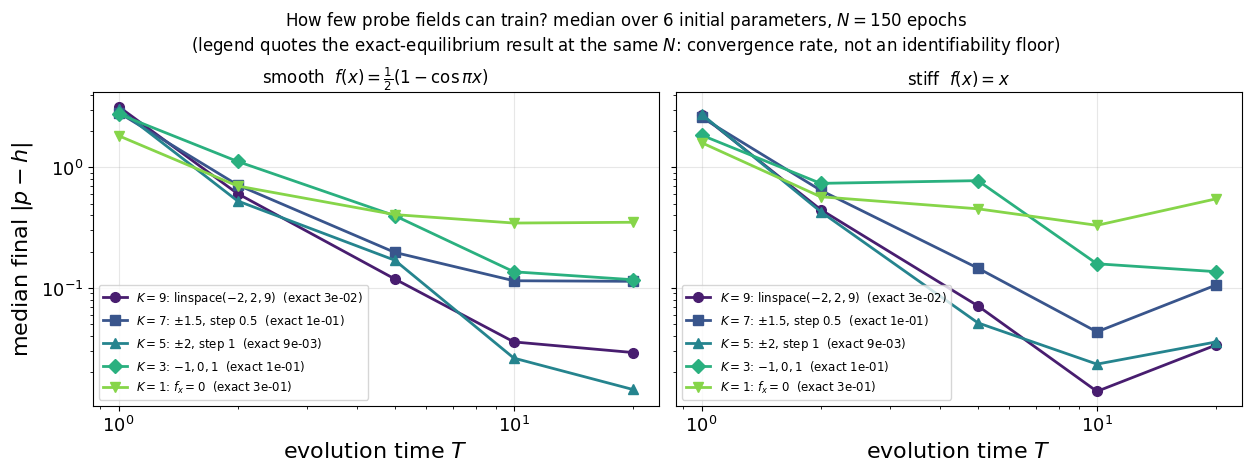

In [45]:
# --- Figure 15: median final |p-h| vs T, one curve per probe set, both schedules -------------
cs15 = plt.cm.viridis(np.linspace(0.08, 0.82, len(tags14)))
mk15 = ["o", "s", "^", "D", "v", "P", "X"][:len(tags14)]   # one per probe set
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.6), sharey=True, layout="constrained")
for ax, s, ttl in ((a1, "smooth", r"smooth  $f(x)=\frac{1}{2}(1-\cos\pi x)$"),
                   (a2, "linear", r"stiff  $f(x)=x$")):
    for j, (tag, lab) in enumerate(zip(tags14, labels14)):
        y = [np.median(d14[f"perr_{tag}_{s}_T{T:g}"]) for T in Ts14]
        ax.loglog(Ts14, y, mk15[j] + "-", color=cs15[j], ms=7,
                  label=lab + r"  (exact %.0e)" % np.median(d14[f"perr_{tag}_exact"]))
    ax.set_xlabel(r"evolution time $T$")
    ax.set_title(ttl, fontsize=12)
    ax.legend(fontsize=8.5, loc="lower left")
# No floor lines: the exact-equilibrium values are optimisation-limited at N=150, not
# identifiability limits (C(h)=0 for every set), and drawing them would span nine decades and
# squash the adiabatic curves, which are the point of the panel.
a1.set_ylabel(r"median final $|p-h|$")
fig.suptitle("How few probe fields can train? median over 6 initial parameters, $N=150$ epochs"
             "\n(legend quotes the exact-equilibrium result at the same $N$: "
             "convergence rate, not an identifiability floor)", fontsize=12)
save(fig, "train_probe_sets_summary")


## Figures 16–17 — the stiff schedule, and the cost during training

Figure 14 showed the probe-set trajectories for the smooth schedule only. **Figure 16** is the same
grid for the **stiff** ramp $f(x)=x$ — the data was already computed in the Figure 14–15 cell, so
this needs no new evolutions. **Figure 17** then answers the other half: how the average cost falls
as training proceeds, epoch on the $x$-axis.

The cost is the one each run actually minimises — the average over **its own** probe set, K3, K5,
K7 or K9. Evaluated with **exact** equilibria, because the question is the quality of the
parameters at each epoch rather than the adiabatic error, and it makes the evaluation cheap (a
$2\times2$ `eigh` per probe, no ODE solve). The scripted twin is
`code/train_experiments.py::exp_probe_sets_costs` → `data/train_probe_sets_costs.npz`; the cell
below recomputes it inline in ≈5 s.

One thing to keep in mind while reading across the four curves in a panel: $C_{K3}$ averages three
probes and $C_{K9}$ averages nine, so they are not the same function and their absolute levels are
not strictly comparable. Read the *descent* of each curve — when it starts falling, how fast, and
where it flattens. The probe-set-independent yardstick is $|p-h|$, in Figure 15.

**What the curves show.** At $T=1$ and $T=2$ the cost plateaus at $\sim10^{-2}$ and never descends:
the trajectory failure of Figures 14 and 16 seen as a cost curve. From $T=10$ all four sets
converge, but at very different rates — K9 is essentially done by epoch 40, while K3 only starts
falling around epoch 100, which is the slow convergence its conditioning predicts (its
worst-direction sensitivity is $0.246$ against K9's $0.641$). At $T=20$ the final costs are within
a factor $\sim2$ of one another for the smooth schedule ($1.8$–$4.3\times10^{-6}$).


median |p-h|, stiff schedule:
 set | T=1     | T=2     | T=5     | T=10    | T=20   
  K9 | 2.70e+00 | 4.46e-01 | 7.09e-02 | 1.39e-02 | 3.36e-02
  K7 | 2.59e+00 | 6.44e-01 | 1.46e-01 | 4.32e-02 | 1.05e-01
  K5 | 2.75e+00 | 4.29e-01 | 5.13e-02 | 2.33e-02 | 3.56e-02
  K3 | 1.84e+00 | 7.35e-01 | 7.74e-01 | 1.58e-01 | 1.36e-01
  K1 | 1.60e+00 | 5.69e-01 | 4.52e-01 | 3.30e-01 | 5.47e-01
saved figures/train_probe_sets_paths_linear


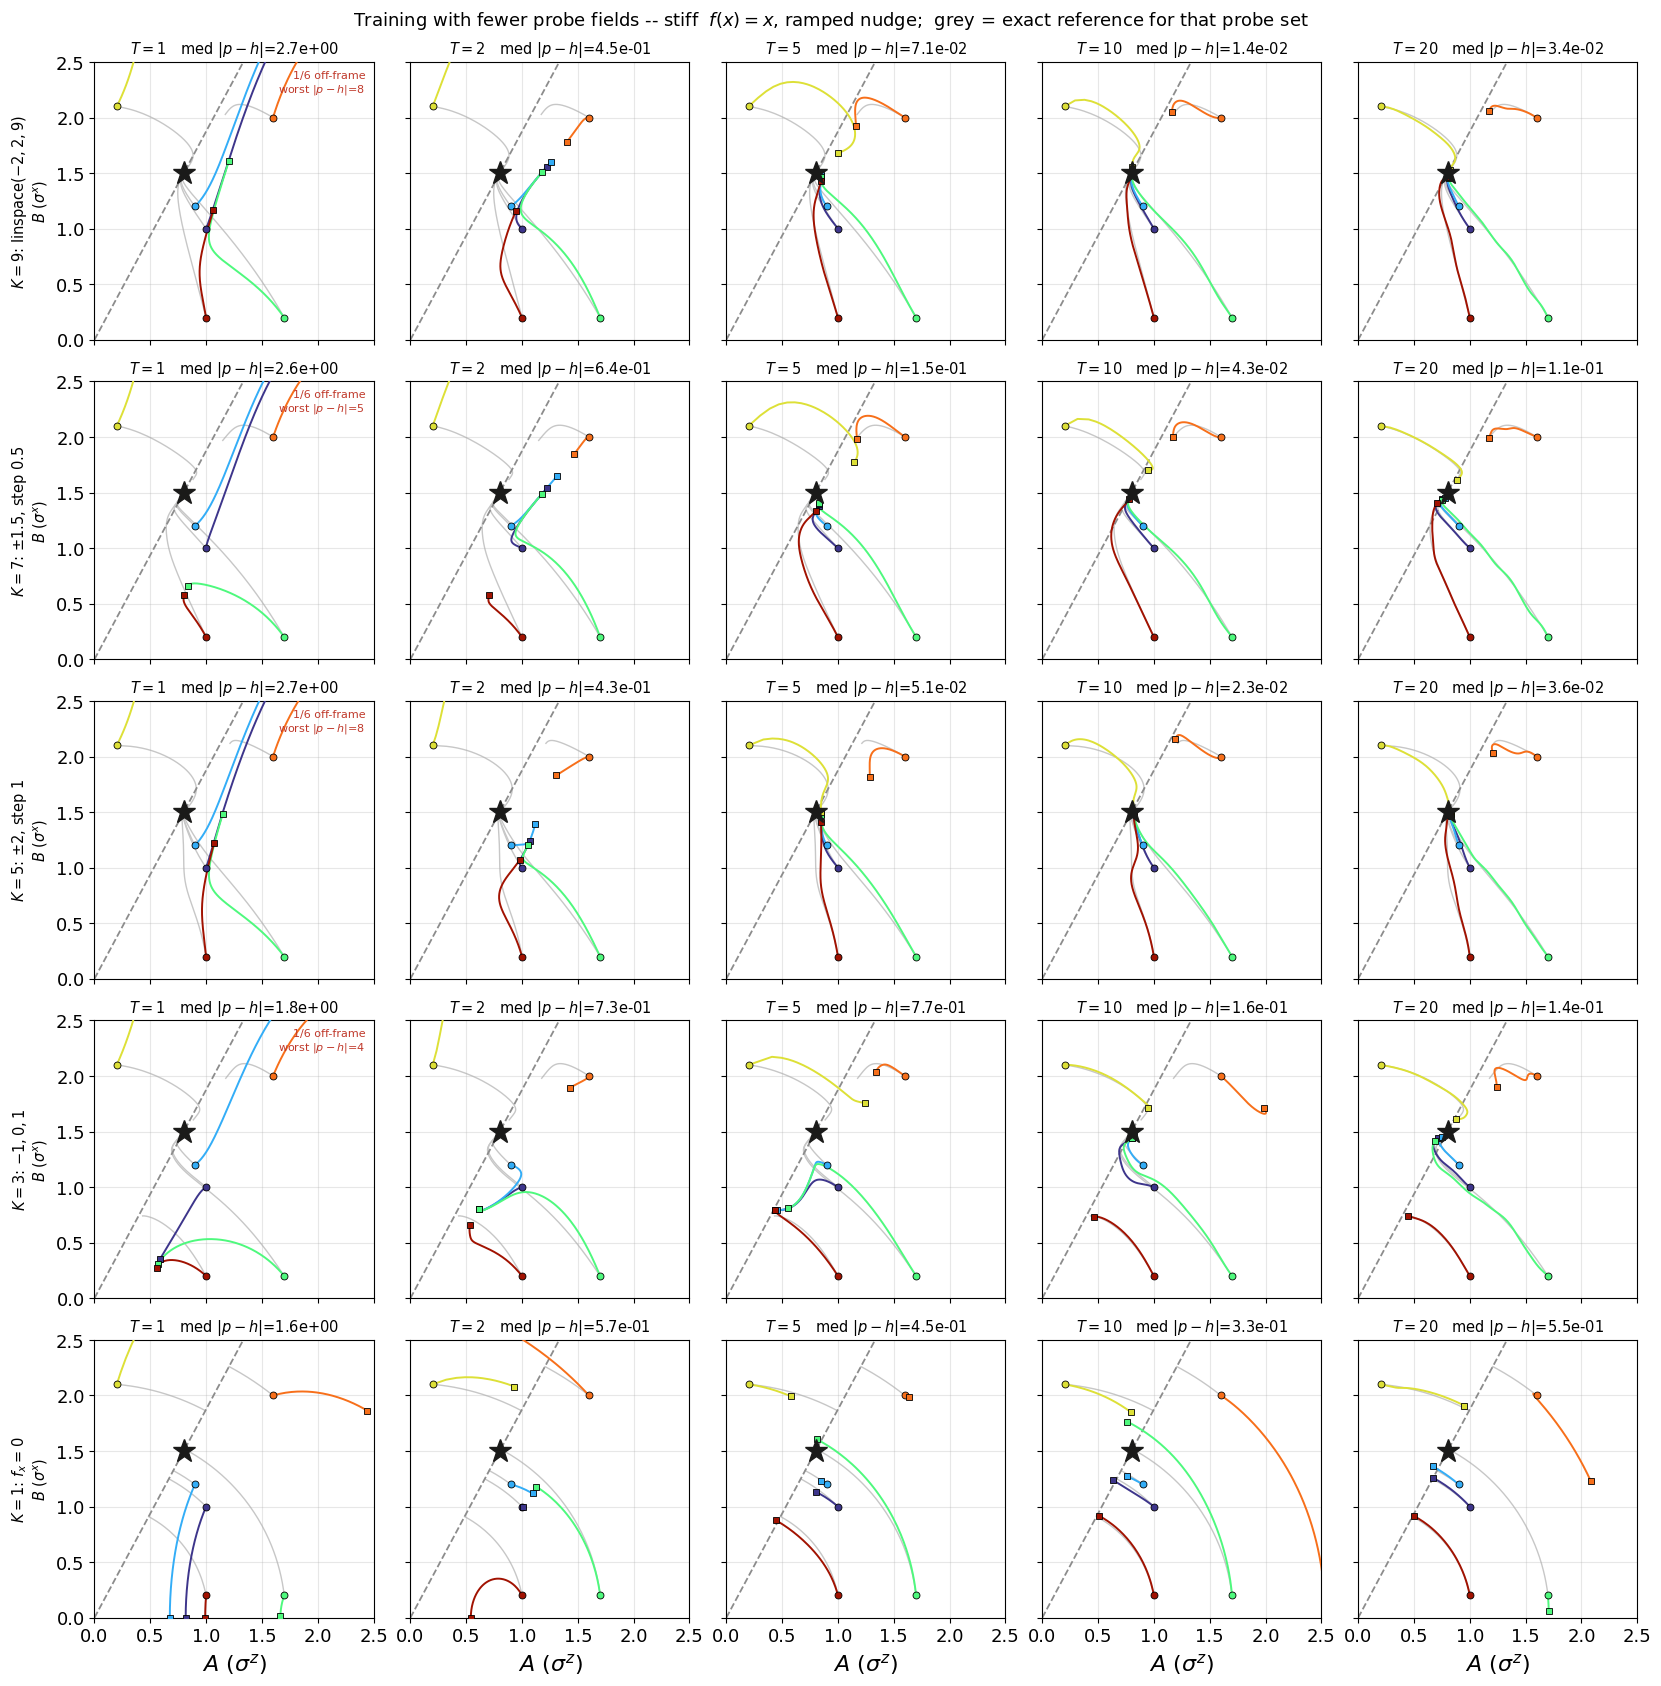

In [46]:
# --- Figure 16: probe-set trajectories, STIFF schedule (data from the Figure 14-15 cell) -----
SCHED_NAME13 = {"smooth": r"smooth  $f(x)=\frac{1}{2}(1-\cos\pi x)$",
                "linear": r"stiff  $f(x)=x$"}

def probe_paths_figure(sched):
    """The Figure 14 grid for one schedule; called with 'smooth' there and 'linear' here."""
    fig, axes = plt.subplots(len(tags14), len(Ts14),
                             figsize=(3.3 * len(Ts14), 3.35 * len(tags14)),
                             sharex=True, sharey=True, layout="constrained")
    pans = []
    for r, (tag, lab) in enumerate(zip(tags14, labels14)):
        Pex = d14["paths_%s_exact" % tag]
        for c, T in enumerate(Ts14):
            ax = axes[r, c]
            key = f"{tag}_{sched}_T{T:g}"
            P = d14["paths_" + key]
            for i in range(ninit14):
                ax.plot(Pex[i, :, 0], Pex[i, :, 1], "-", color="0.78", lw=1.0, zorder=1)
            for i in range(ninit14):
                ax.plot(P[i, :, 0], P[i, :, 1], "-", color=pc14[i], lw=1.4, zorder=3)
                ax.plot(*P[i, 0], "o", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=4)
                ax.plot(*P[i, -1], "s", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=4)
            draw_target_ray(ax, h14)
            ax.plot(*h14, "*", color=INK, ms=17, zorder=6)
            ax.set_title(r"$T=%g$   med $|p-h|$=%.1e"
                         % (T, np.median(d14["perr_" + key])), fontsize=10.5)
            if r == len(tags14) - 1:
                ax.set_xlabel(r"$A$ ($\sigma^z$)")
            if c == 0:
                ax.set_ylabel(lab + "\n" + r"$B$ ($\sigma^x$)", fontsize=10.5)
            pans.append((ax, key, P))
    kx, ky = [np.atleast_1d(h14[0])], [np.atleast_1d(h14[1])]
    for _, _, P in pans:
        rr = np.linalg.norm(P - h14[None, None], axis=-1)
        m = np.isfinite(rr) & (rr < 4.0)
        kx.append(P[..., 0][m]); ky.append(P[..., 1][m])
    xs, ys = np.concatenate(kx), np.concatenate(ky)
    xlo, xhi = xs.min() - 0.45, xs.max() + 0.45
    ylo, yhi = ys.min() - 0.45, ys.max() + 0.45
    axes[0, 0].set_xlim(0,2.5); axes[0, 0].set_ylim(0,2.5)
    for ax, key, P in pans:
        e = P[:, -1]
        n = int(np.sum(~((e[:, 0] > xlo) & (e[:, 0] < xhi) &
                         (e[:, 1] > ylo) & (e[:, 1] < yhi))))
        if n:
            ax.text(0.97, 0.97, r"%d/%d off-frame" % (n, P.shape[0]) + "\n"
                    + r"worst $|p-h|$=%.0f" % np.max(d14["perr_" + key]),
                    transform=ax.transAxes, fontsize=8, color=C["linear"],
                    ha="right", va="top")
    fig.suptitle("Training with fewer probe fields -- " + SCHED_NAME13[sched]
                 + ", ramped nudge;  grey = exact reference for that probe set", fontsize=13)
    save(fig, "train_probe_sets_paths" + ("" if sched == "smooth" else "_" + sched))

print("median |p-h|, stiff schedule:")
print(f"{'set':>4} | " + " | ".join(f"T={T:<5g}" for T in Ts14))
for tag in tags14:
    print(f"{tag:>4} | " + " | ".join("%7.2e" % np.median(d14[f"perr_{tag}_linear_T{T:g}"])
                                     for T in Ts14))
probe_paths_figure("linear")


cost trajectories computed in 2s

final median cost, smooth schedule (each set on its own probes):
 set | T=1       | T=2       | T=5       | T=10      | T=20     
  K9 |  6.38e-02 |  1.36e-02 |  6.35e-04 |  3.35e-05 |  2.16e-05
  K7 |  6.55e-02 |  1.68e-02 |  5.91e-04 |  1.17e-04 |  1.00e-04
  K5 |  5.96e-02 |  1.24e-02 |  1.73e-03 |  3.53e-05 |  9.82e-06
  K3 |  5.91e-02 |  2.52e-02 |  2.55e-03 |  1.93e-04 |  1.34e-04
  K1 |  1.00e-01 |  4.44e-02 |  3.62e-03 |  6.61e-05 |  3.03e-06

final median cost, linear schedule (each set on its own probes):
 set | T=1       | T=2       | T=5       | T=10      | T=20     
  K9 |  4.65e-02 |  6.85e-03 |  3.48e-04 |  4.82e-06 |  5.42e-05
  K7 |  4.00e-02 |  7.36e-03 |  9.06e-04 |  3.66e-05 |  7.90e-05
  K5 |  4.23e-02 |  7.20e-03 |  1.73e-04 |  2.96e-05 |  8.66e-05
  K3 |  3.93e-02 |  5.04e-03 |  2.14e-03 |  3.60e-04 |  2.61e-04
  K1 |  1.40e-01 |  2.74e-02 |  5.22e-03 |  1.79e-03 |  3.76e-04
saved figures/train_probe_sets_cost_epoch


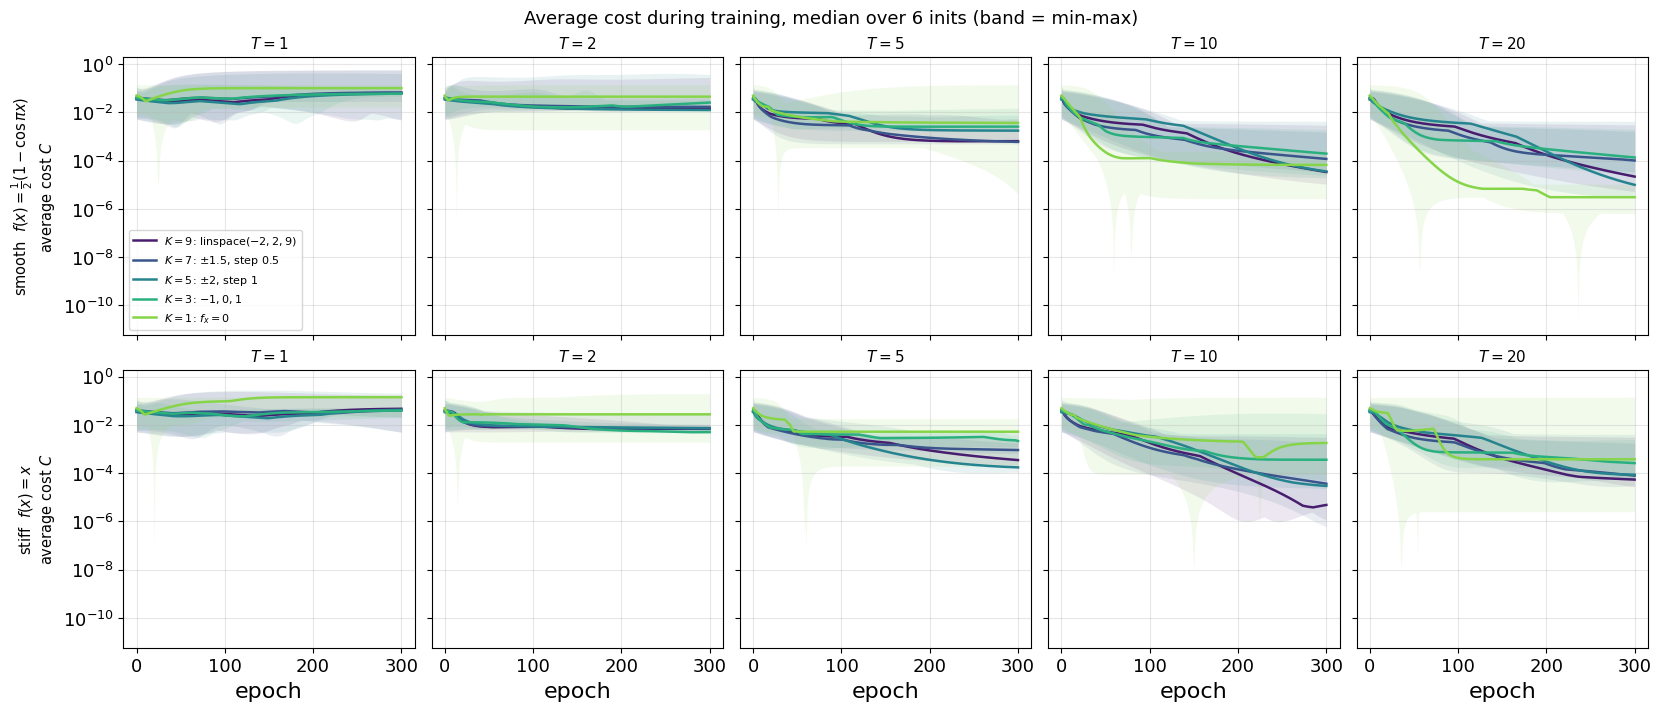

In [47]:
# --- Figure 17: average cost vs EPOCH (computed inline, ~5 s; exact equilibria) --------------
# Post-processing of the Figure 14-15 trajectories: no re-training, just score every stored
# parameter at every epoch on its OWN probe set. Twin: train_experiments.py::exp_probe_sets_costs.
import time
_t0 = time.time()

def _cost_traj(P, fx, y):
    """Average cost for every point of a (ninit, N+1, 2) path array, exact equilibria."""
    K = fx.shape[0]
    flat = jnp.asarray(P.reshape(-1, 2))
    c = np.array(jax.vmap(lambda q: qep.cost(q, fx, y, 20.0, NS13, "exact"))(flat)) / K
    return c.reshape(P.shape[:2])

costs = {}
for tag in tags14:
    fx = jnp.asarray(d14["fxs_" + tag]); y = jnp.asarray(d14["y_tau_" + tag])
    for s in SCHEDS13:
        for T in Ts14:
            costs[f"{tag}_{s}_T{T:g}"] = _cost_traj(d14[f"paths_{tag}_{s}_T{T:g}"], fx, y)
print(f"cost trajectories computed in {time.time()-_t0:.0f}s")

for s in SCHEDS13:
    print(f"\nfinal median cost, {s} schedule (each set on its own probes):")
    print(f"{'set':>4} | " + " | ".join(f"T={T:<7g}" for T in Ts14))
    for tag in tags14:
        print(f"{tag:>4} | " + " | ".join("%9.2e" % np.median(costs[f"{tag}_{s}_T{T:g}"][:, -1])
                                         for T in Ts14))

cols17 = plt.cm.viridis(np.linspace(0.08, 0.82, len(tags14)))
fig, axes = plt.subplots(len(SCHEDS13), len(Ts14),
                         figsize=(3.3 * len(Ts14), 3.5 * len(SCHEDS13)),
                         sharex=True, sharey=True, layout="constrained")
for r, s in enumerate(SCHEDS13):
    for c, T in enumerate(Ts14):
        ax = axes[r, c]
        for j, (tag, lab) in enumerate(zip(tags14, labels14)):
            Cc = costs[f"{tag}_{s}_T{T:g}"]
            ep = np.arange(Cc.shape[1])
            ax.semilogy(ep, np.maximum(np.median(Cc, 0), 1e-18), "-",
                        color=cols17[j], lw=1.8, label=lab)
            ax.fill_between(ep, np.maximum(Cc.min(0), 1e-18), np.maximum(Cc.max(0), 1e-18),
                            color=cols17[j], alpha=0.10, lw=0)
        ax.set_title(r"$T=%g$" % T, fontsize=11)
        if r == len(SCHEDS13) - 1:
            ax.set_xlabel("epoch")
        if c == 0:
            ax.set_ylabel(SCHED_NAME13[s] + "\n" + r"average cost $C$", fontsize=10.5)
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="lower left")
fig.suptitle("Average cost during training, median over 6 inits (band = min-max)", fontsize=13)
save(fig, "train_probe_sets_cost_epoch")



## Figure 18 — Figures 14 and 16 merged: both schedules on one grid

The same probe-set $\times\ T$ layout as Figure 14, with **both** schedules overlaid instead of one
per figure: **solid = smooth**, **dashed = stiff**, and a given initial point keeps the *same
colour* in both, so the pair of trajectories starting from one dot can be read as a unit. Grey is
the exact-equilibrium reference for that probe set.

Markers: `o` at the shared start; filled `s` at the smooth endpoint, open `s` at the stiff one.
Panel titles give the median final $|p-h|$ for the two schedules as *smooth / stiff*.


saved figures/train_probe_sets_paths_both
 set | T=1     | T=2     | T=5     | T=10    | T=20      (median |p-h|, smooth / stiff)
  K9 | 3.2e+00/2.7e+00 | 6.0e-01/4.5e-01 | 1.2e-01/7.1e-02 | 3.6e-02/1.4e-02 | 2.9e-02/3.4e-02
  K7 | 2.8e+00/2.6e+00 | 7.1e-01/6.4e-01 | 2.0e-01/1.5e-01 | 1.1e-01/4.3e-02 | 1.1e-01/1.1e-01
  K5 | 3.0e+00/2.7e+00 | 5.3e-01/4.3e-01 | 1.7e-01/5.1e-02 | 2.6e-02/2.3e-02 | 1.4e-02/3.6e-02
  K3 | 2.8e+00/1.8e+00 | 1.1e+00/7.3e-01 | 4.0e-01/7.7e-01 | 1.4e-01/1.6e-01 | 1.2e-01/1.4e-01
  K1 | 1.8e+00/1.6e+00 | 7.0e-01/5.7e-01 | 4.0e-01/4.5e-01 | 3.4e-01/3.3e-01 | 3.5e-01/5.5e-01


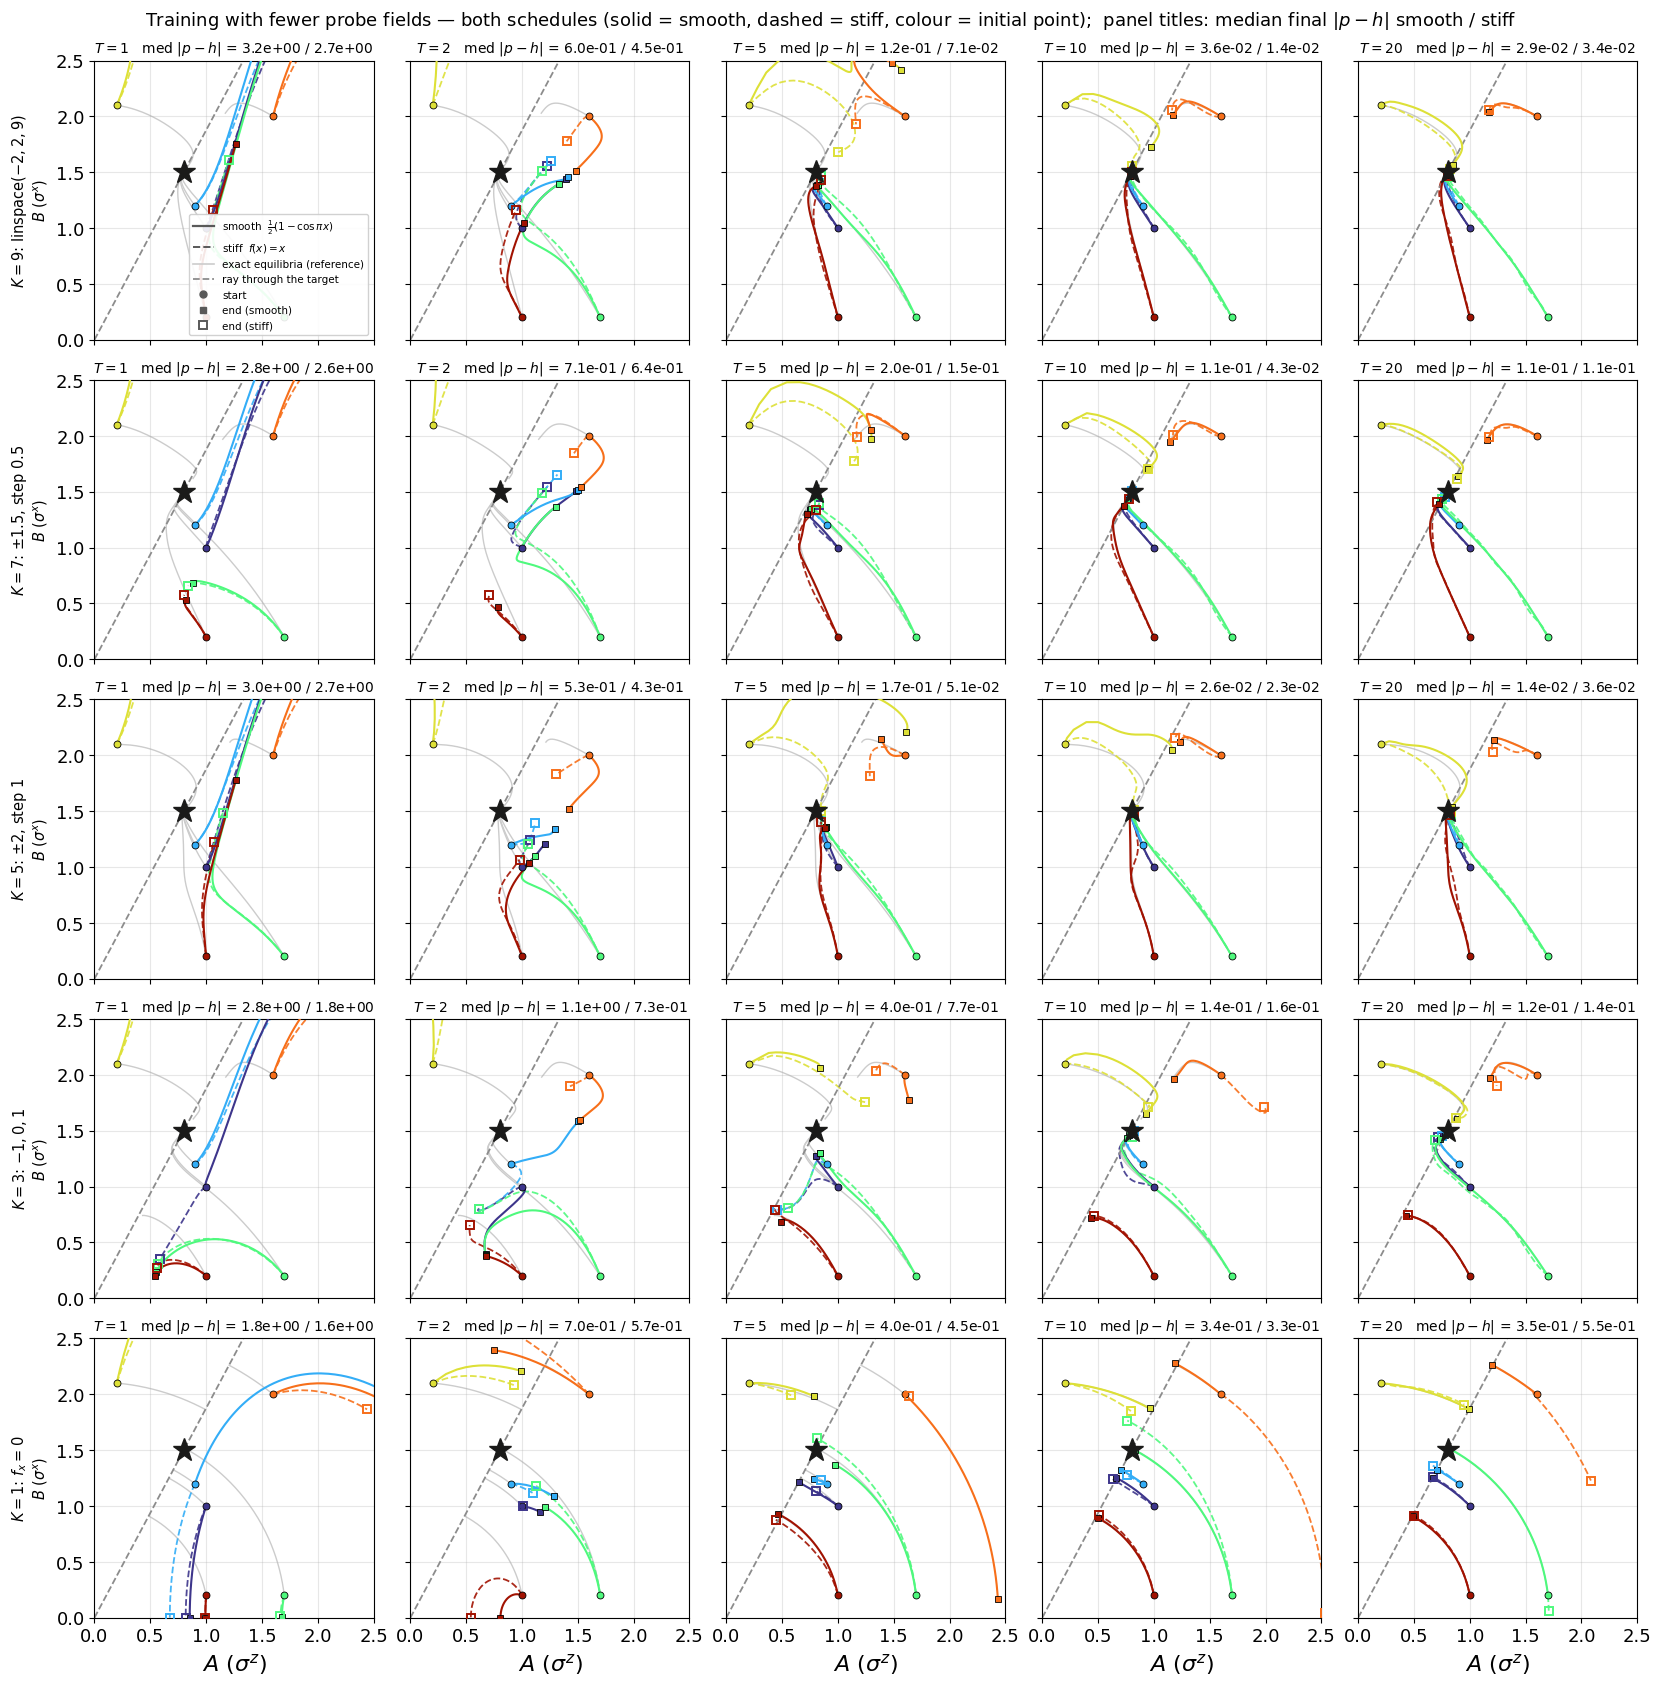

In [48]:
# --- Figure 18: Figures 14 and 16 merged -- smooth solid, stiff dashed, colour = init --------
# Same grid as Figure 14 (probe set x T). Colour identifies the initial point and is shared by the
# two schedules; line style carries the schedule, so neither encoding is doubled up.
fig, axes = plt.subplots(len(tags14), len(Ts14),
                         figsize=(3.3 * len(Ts14), 3.35 * len(tags14)),
                         sharex=True, sharey=True, layout="constrained")
panels18 = []
for r, (tag, lab) in enumerate(zip(tags14, labels14)):
    Pex = d14["paths_%s_exact" % tag]                  # exact reference for THIS probe set
    for c, T in enumerate(Ts14):
        ax = axes[r, c]
        k_sm = f"{tag}_smooth_T{T:g}"
        k_st = f"{tag}_linear_T{T:g}"
        Psm, Pst = d14["paths_" + k_sm], d14["paths_" + k_st]
        for i in range(ninit14):
            ax.plot(Pex[i, :, 0], Pex[i, :, 1], "-", color="0.80", lw=1.0, zorder=1)
        for i in range(ninit14):
            ax.plot(Pst[i, :, 0], Pst[i, :, 1], "--", color=pc14[i], lw=1.3, alpha=0.9, zorder=2)
            ax.plot(Psm[i, :, 0], Psm[i, :, 1], "-", color=pc14[i], lw=1.5, zorder=3)
            ax.plot(*Psm[i, 0], "o", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=5)
            ax.plot(*Psm[i, -1], "s", color=pc14[i], ms=5, mec="k", mew=0.6, zorder=5)
            ax.plot(*Pst[i, -1], "s", color="none", ms=6, mec=pc14[i], mew=1.4, zorder=5)
        draw_target_ray(ax, h14)
        ax.plot(*h14, "*", color=INK, ms=17, zorder=6)
        ax.set_title(r"$T=%g$   med $|p-h|$ = %.1e / %.1e"
                     % (T, np.median(d14["perr_" + k_sm]), np.median(d14["perr_" + k_st])),
                     fontsize=10)
        if r == len(tags14) - 1:
            ax.set_xlabel(r"$A$ ($\sigma^z$)")
        if c == 0:
            ax.set_ylabel(lab + "\n" + r"$B$ ($\sigma^x$)", fontsize=10.5)
        panels18.append((ax, k_sm, k_st, Psm, Pst))

axes[0, 0].set_xlim(0, 2.5); axes[0, 0].set_ylim(0, 2.5)

# Off-frame annotations -- COMMENTED OUT on request. This printed, per panel and per
# schedule, how many of the 6 trajectories ended outside the [0,2.5]^2 frame and the
# worst final |p-h|, e.g. "smooth 1/6 off, worst 22". It used C["linear"] (#C0392B),
# which is the STIFF colour in every other figure, so the red read as a schedule rather
# than as a warning. Un-comment the block below to restore it.
# # flag endpoints that fall outside the frame, per schedule
# xlo, xhi, ylo, yhi = 0.0, 2.5, 0.0, 2.5
# for ax, k_sm, k_st, Psm, Pst in panels18:
#     msg = []
#     for nm, P, k in (("smooth", Psm, k_sm), ("stiff", Pst, k_st)):
#         e = P[:, -1]
#         n = int(np.sum(~((e[:, 0] > xlo) & (e[:, 0] < xhi) &
#                          (e[:, 1] > ylo) & (e[:, 1] < yhi))))
#         if n:
#             msg.append(r"%s %d/%d off, worst %.0f" % (nm, n, P.shape[0], np.max(d14["perr_" + k])))
#     if msg:
#         ax.text(0.97, 0.97, "\n".join(msg), transform=ax.transAxes, fontsize=7.5,
#                 color=C["linear"], ha="right", va="top")

h18 = [plt.Line2D([], [], color="0.35", ls="-", lw=1.6, label=r"smooth  $\frac{1}{2}(1-\cos\pi x)$"),
       plt.Line2D([], [], color="0.35", ls="--", lw=1.4, label=r"stiff  $f(x)=x$"),
       plt.Line2D([], [], color="0.80", ls="-", lw=1.2, label="exact equilibria (reference)"),
       plt.Line2D([], [], color="0.55", ls="--", lw=1.3, label="ray through the target"),
       plt.Line2D([], [], color="0.35", ls="", marker="o", ms=5, label="start"),
       plt.Line2D([], [], color="0.35", ls="", marker="s", ms=5, label="end (smooth)"),
       plt.Line2D([], [], color="none", ls="", marker="s", ms=6, mec="0.35", mew=1.4,
                  label="end (stiff)")]
axes[0, 0].legend(handles=h18, fontsize=7.5, loc="lower right", framealpha=0.9)

fig.suptitle("Training with fewer probe fields — both schedules "
             "(solid = smooth, dashed = stiff, colour = initial point);  "
             "panel titles: median final $|p-h|$ smooth / stiff", fontsize=13)
save(fig, "train_probe_sets_paths_both")

print(f"{'set':>4} | " + " | ".join("T=%-5g" % T for T in Ts14) + "   (median |p-h|, smooth / stiff)")
for tag in tags14:
    print(f"{tag:>4} | " + " | ".join(
        "%.1e/%.1e" % (np.median(d14[f"perr_{tag}_smooth_T{T:g}"]),
                       np.median(d14[f"perr_{tag}_linear_T{T:g}"])) for T in Ts14))



## Figure 19 — why $K=3$ has a second minimum: the "ghost radius", analytically

Three probes **are** enough to identify $(A,B)$ — the global minimum is unique and exact. What
they are not enough for is a unimodal landscape. Here is the closed-form reason.

**Setup.** Walk out along the ray through the target, $p = s\,\hat h$ with
$\hat h=(a,b)=(h_z,h_x)/S$ and $S=|h|$. Because $a^2+b^2=1$,

$$A^2+(B+f)^2 = s^2(a^2+b^2) + 2bf\,s + f^2 = s^2 + 2bf\,s + f^2,
\qquad\Longrightarrow\qquad
y_f(s)=\frac{a\,s}{\sqrt{s^2+2bf\,s+f^2}} .$$

**The ghost radius.** Ask where a probe $f$ reproduces its own target value, $y_f(s)=y_f(S)$.
Squaring and cancelling $a^2$ gives $s^2(2bfS+f^2)=S^2(2bfs+f^2)$, which **factorises**:

$$(s-S)\,\big[\,2h_x\,s + f\,(s+S)\,\big] = 0
\qquad\Longrightarrow\qquad
\boxed{\;s_f=\frac{-f\,S}{2h_x+f}\;}$$

So besides the true solution $s=S$, every probe has a *second* radius at which it is perfectly
satisfied. It is physical ($s_f>0$) exactly when $-2h_x<f<0$ — i.e. **only negative probes on the
peak side produce a ghost**. For $h=(0.8,1.5)$, $2h_x=3$, $S=1.7$:

| $f$ | $-2$ | $-1.5$ | $-1$ | $-0.5$ | $+0.5$ | $+1$ | $+2$ |
|---|---|---|---|---|---|---|---|
| $s_f$ | 3.400 | 1.700 | **0.850** | 0.340 | −0.243 | −0.425 | −0.680 |

**For the set $\{-1,0,+1\}$ this is fatal.** At $s=s_{-1}$:

* the $f=-1$ term vanishes — and it does so *exactly*: the equation reduces to
  $200s^2-510s+289=0$, discriminant $28900=170^2$, roots $(510\pm170)/400$, i.e.
  $s=1.7$ and $s=0.85=\boxed{S/2}$ exactly;
* the $f=0$ term vanishes **identically for every $s$**, since $y_0(s)=a$ is independent of $s$
  (a zero-field probe sees only the polar angle);
* so **only $f=+1$ is left**, and $y_{+1}$ is monotone in $s$ — no sharp pull.

Two of the three residuals are zero at $s=S/2$, and the survivor is slowly varying, so the cost
has a dip there:

$$C(S/2)=\tfrac13\cdot\tfrac12\big(y_{+1}(S/2)-y_{+1}(S)\big)^2 = 1.1193\times10^{-3},$$

against the numerically located minimum $C=1.10\times10^{-3}$ at $s=0.859$ (slightly right of
$S/2$, because the residual $f=+1$ term still tilts the curve). A barrier of $4.2\times10^{-3}$ at
$s\approx1.12$ separates it from the true zero at $s=S$.

**Why more probes cure it.** $K=5$ adds $f=\pm2$, whose ghost sits at $s_{-2}=3.4$ — nowhere near
$0.85$ — so at $s=0.85$ that term is far from satisfied and its slope removes the stationary
point. The ghosts of different probes never coincide (except at $s=S$), so the more probes, the
harder it is for enough residuals to vanish simultaneously anywhere but at the target.


closed form y_f(S) matches the stored targets for every probe set (atol 1e-12)
ghost radii reproduce y_f exactly;  s_-1 = 0.8500 = S/2 = 0.8500
saved figures/cost_along_ray

C(S/2) analytic = 1.119326e-03
numerical minimum at s = 0.859, C = 1.101221e-03;  barrier max C = 4.231e-03


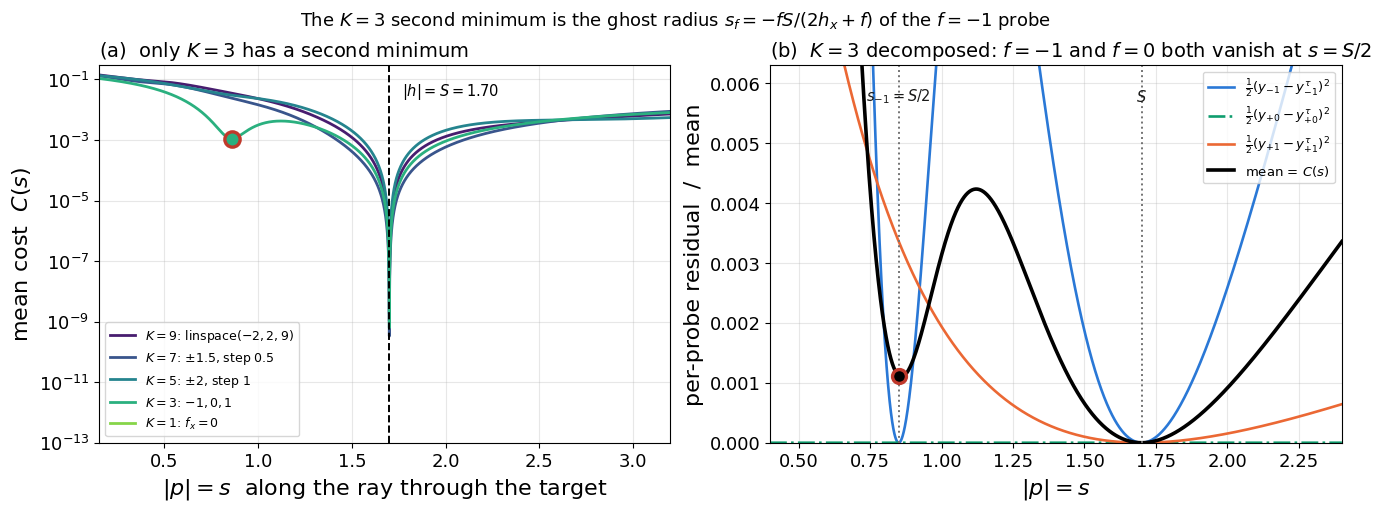

In [49]:
# --- Figure 19: cost along the ray, and the analytic ghost radius --------------------------
h19 = np.asarray(d14["h"]); S19 = float(np.hypot(*h19)); a19, b19 = h19[0]/S19, h19[1]/S19
uh19 = h19/S19
def y_f(s, f):                      # y_f(s) = a s / sqrt(s^2 + 2 b f s + f^2)
    return a19*np.asarray(s)/np.sqrt(np.asarray(s)**2 + 2*b19*f*np.asarray(s) + f**2)
def ghost(f):                       # s_f = -f S / (2 h_x + f)
    return -f*S19/(2*h19[1] + f)

# verify the closed form against the stored dataset and against the ghost formula
for tag in tags14:
    fxs = np.asarray(d14["fxs_" + tag]); yt = np.asarray(d14["y_tau_" + tag])
    assert np.allclose(y_f(S19, fxs), yt, atol=1e-12)
print("closed form y_f(S) matches the stored targets for every probe set (atol 1e-12)")
for f in (-2.0, -1.0, -0.5):
    assert abs(y_f(ghost(f), f) - y_f(S19, f)) < 1e-12
print(f"ghost radii reproduce y_f exactly;  s_-1 = {ghost(-1.0):.4f} = S/2 = {S19/2:.4f}")

ss19 = np.linspace(0.15, 3.2, 4000)
cols19 = plt.cm.viridis(np.linspace(0.08, 0.82, len(tags14)))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.4, 5.0), layout="constrained")

for j, (tag, lab) in enumerate(zip(tags14, labels14)):
    fxs = np.asarray(d14["fxs_" + tag])
    cc = np.mean([0.5*(y_f(ss19, f) - y_f(S19, f))**2 for f in fxs], axis=0)
    a1.plot(ss19, np.maximum(cc, 1e-14), color=cols19[j], lw=2.0, label=lab)
    if tag == "K3":
        i = 1 + int(np.argmin(cc[1:np.searchsorted(ss19, 1.3)]))
        a1.plot([ss19[i]], [cc[i]], "o", color=cols19[j], ms=11, mec=WEDGE_C, mew=2.4, zorder=6)
a1.axvline(S19, color="k", ls="--", lw=1.4)
a1.set_yscale("log"); a1.set_xlim(0.15, 3.2); a1.set_ylim(1e-13, 3e-1)
a1.set_xlabel(r"$|p|=s$  along the ray through the target")
a1.set_ylabel(r"mean cost  $C(s)$")
a1.set_title(r"(a)  only $K=3$ has a second minimum", loc="left")
a1.text(S19*1.04, 3e-2, r"$|h|=S=1.70$", fontsize=10.5)
a1.legend(loc="lower left", fontsize=9)

# decomposition of the K=3 cost into its three probe terms
for f, c, ls in ((-1.0, "#2a78d6", "-"), (0.0, "#0f9d6e", "-."), (1.0, "#eb6834", "-")):
    a2.plot(ss19, 0.5*(y_f(ss19, f) - y_f(S19, f))**2, ls, color=c, lw=1.9,
            label=r"$\frac{1}{2}(y_{%+.0f}-y^\tau_{%+.0f})^2$" % (f, f))
tot = np.mean([0.5*(y_f(ss19, f) - y_f(S19, f))**2 for f in (-1., 0., 1.)], axis=0)
a2.plot(ss19, tot, "k-", lw=2.6, label=r"mean = $C(s)$")
for x, lab in ((S19/2, r"$s_{-1}=S/2$"), (S19, r"$S$")):
    a2.axvline(x, color=MUTED, ls=":", lw=1.4)
    a2.text(x, 5.7e-3, lab, fontsize=10.5, ha="center", color=INK)
a2.plot([S19/2], [np.mean([0.5*(y_f(S19/2, f) - y_f(S19, f))**2 for f in (-1., 0., 1.)])],
        "o", color="k", ms=10, mec=WEDGE_C, mew=2.4, zorder=6)
a2.set_xlim(0.4, 2.4); a2.set_ylim(0, 6.3e-3)
a2.set_xlabel(r"$|p|=s$"); a2.set_ylabel("per-probe residual  /  mean")
a2.set_title(r"(b)  $K=3$ decomposed: $f=-1$ and $f=0$ both vanish at $s=S/2$", loc="left")
a2.legend(fontsize=9.5, loc="upper right")

fig.suptitle(r"The $K=3$ second minimum is the ghost radius $s_f=-fS/(2h_x+f)$ of the $f=-1$ probe",
             fontsize=13)
save(fig, "cost_along_ray")

print(f"\nC(S/2) analytic = "
      f"{np.mean([0.5*(y_f(S19/2, f) - y_f(S19, f))**2 for f in (-1.,0.,1.)]):.6e}")
i = 1 + int(np.argmin(tot[1:np.searchsorted(ss19, 1.3)]))
print(f"numerical minimum at s = {ss19[i]:.3f}, C = {tot[i]:.6e};  "
      f"barrier max C = {tot[np.searchsorted(ss19,1.0):np.searchsorted(ss19,1.3)].max():.3e}")



## Figure 20 — two different outlier populations, told apart

Figure 11 mixes two unrelated causes of a large "adiabatic vs exact" deviation. This figure
separates them by marking the second one directly.

**Red (already known): Landau–Zener.** Points inside the wedge have the ramp crossing $A=0$,
closing the gap; the adiabatic error there does not shrink with $T$.

**Black $\times$ (new): $\sigma^x$-saturation near the $B$-axis.** At $A=0$ the ground state is a
pure $\sigma^x$ eigenstate ($\langle\sigma^z\rangle\equiv0$), so a $\sigma^z$ nudge barely moves
$\langle\sigma^x\rangle$ — the **exact** $g_\Omega=\partial C/\partial B$ genuinely shrinks there,
while $g_\Delta=\partial C/\partial A$ stays $O(1)$. This is real physics, not a failure: checked
separately (not shown here), the *absolute* adiabatic error at these points decays with $T$ like
an ordinary boundary effect (halving roughly every doubling of $T$, fully converged by $T=160$) —
it only *looks* bad in a relative-error sense because it's being divided by an exact value that is
legitimately close to zero.

Criterion: $|A|<0.3$ (stable over $0.25$–$0.35$ — not sitting on a data point) and outside the
wedge. Four points qualify: $(A,B)=(0.19,-0.87)$, $(0.20,-1.85)$, $(-0.25,-1.43)$,
$(0.01,2.49)$, with relative deviation only $2$–$8\%$ at $K=1$, smooth, $T=20$ — nothing like the
wedge's $\gtrsim\!2\times$.

Panel (b) uses $K=1$, $f_x=\{0\}$ specifically (not the $K=7$ set of Figures 9–12), since a single
probe at zero field is the cleanest place to see the $\sigma^x$-saturation mechanism in isolation.
Axis limits come from the non-wedge points only — $K=1$'s wedge failures reach $|g|\approx15$ and
would otherwise squash the four crosses, the actual subject here, into an unreadable clump.


near-B-axis set (|A|<0.3, outside the wedge): 4 points, indices [2, 4, 22, 36]
   idx2: (A,B)=(+0.193,-0.871)  g_exact(K1)=[1.0762 0.2266]  rel_dev(K1,smooth,T20)=0.024
   idx4: (A,B)=(+0.203,-1.850)  g_exact(K1)=[0.5318 0.0554]  rel_dev(K1,smooth,T20)=0.023
   idx22: (A,B)=(-0.250,-1.426)  g_exact(K1)=[ 0.6677 -0.1218]  rel_dev(K1,smooth,T20)=0.030
   idx36: (A,B)=(+0.008,+2.489)  g_exact(K1)=[4.018e-01 3.000e-04]  rel_dev(K1,smooth,T20)=0.077
saved figures/bd_baxis_points


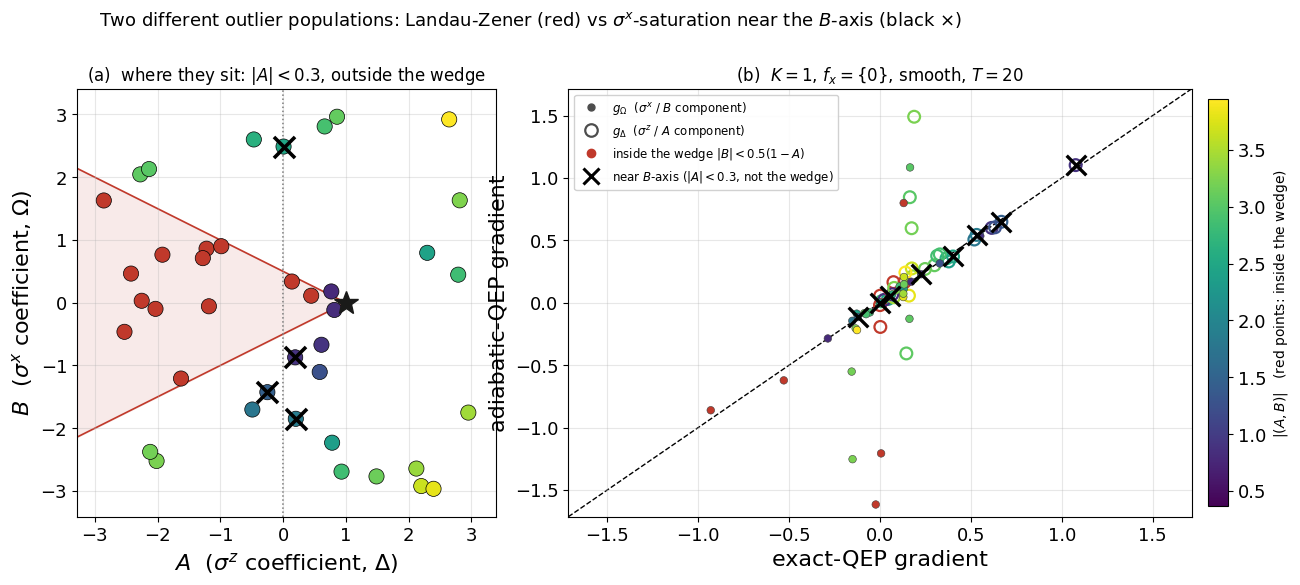

In [50]:
# --- bd_baxis_points (data from run_boundary.py grad_scatter_sched + grad_scatter_probes) ---
BAXIS_THR = 0.3

def _baxis_mask(pts, wedge):
    """Points near the B-axis: |A| small, excluding the (already-marked) wedge.

    These are NOT Landau-Zener failures. At A=0 the ground state is a pure sigma^x eigenstate
    (<sigma^z>=0 identically), so the sigma^z nudge only weakly perturbs <sigma^x> -- the exact
    g_Omega = dC/dB genuinely shrinks there (measured: ~B^0 in beta, i.e. tiny in absolute terms,
    while g_Delta = dC/dA stays O(1)). The adiabatic estimate at these points carries an ORDINARY
    T^-1-type boundary error of normal absolute size; dividing that by the near-zero exact value
    is what inflates the relative deviation, not a dynamical failure. See log/STATUS.md.
    """
    return (np.abs(pts[:, 0]) < BAXIS_THR) & ~wedge


d9 = L("bd_grad_scatter_sched")                    # for the (A,B) map + its own wedge shading
d1 = L("bd_grad_scatter_probes")                    # for the K=1, T=20 gradient scatter
cval, lab, norm, wedge, slope = _scat_pos(d9)
P = d9["pts"]
bmask = _baxis_mask(P, wedge)
print(f"near-B-axis set (|A|<{BAXIS_THR}, outside the wedge): {bmask.sum()} points,"
      f" indices {np.where(bmask)[0].tolist()}")
for i in np.where(bmask)[0]:
    print(f"   idx{i}: (A,B)=({P[i,0]:+.3f},{P[i,1]:+.3f})"
          f"  g_exact(K1)={np.round(d1['g_qep_exact_K1'][i],4)}"
          f"  rel_dev(K1,smooth,T20)={d1['rel_K1_smooth_T20'][i]:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14.4, 6.0))

# (a) the (A,B) map, exactly like fig_scatter_points, plus crosses
aw = np.linspace(P[:, 0].min() * 1.15, 1.0, 200)
a1.fill_between(aw, -(1.0 - aw) * slope, (1.0 - aw) * slope, color=WEDGE_C, alpha=0.10, zorder=0)
a1.plot(aw, (1.0 - aw) * slope, color=WEDGE_C, lw=1.2, zorder=1)
a1.plot(aw, -(1.0 - aw) * slope, color=WEDGE_C, lw=1.2, zorder=1)
a1.scatter(P[:, 0], P[:, 1], s=120, c=_pt_colors(cval, norm, wedge),
          edgecolors="k", linewidths=0.5, zorder=4)
a1.scatter(P[bmask, 0], P[bmask, 1], marker="x", s=230, c="k", linewidths=2.6, zorder=6)
a1.axvline(0, color=MUTED, ls=":", lw=1.1, zorder=1)
a1.plot([qep_A0], [qep_B0], marker="*", ms=18, color=INK, zorder=5)
a1.set_xlim(P[:, 0].min() * 1.15, P[:, 0].max() * 1.15)
a1.set_ylim(P[:, 1].min() * 1.15, P[:, 1].max() * 1.15)
a1.set_aspect("equal")
a1.set_xlabel(r"$A$  ($\sigma^z$ coefficient, $\Delta$)")
a1.set_ylabel(r"$B$  ($\sigma^x$ coefficient, $\Omega$)")
a1.set_title(r"(a)  where they sit: $|A|<%g$, outside the wedge" % BAXIS_THR, fontsize=12)

# (b) the K=1, smooth, T=20 gradient scatter, plus crosses on the same points
gex1 = d1["g_qep_exact_K1"]; gad1 = d1["gq_K1_smooth_T20"]
# limits from points OUTSIDE the wedge only (K=1's wedge outliers reach |g|~15 and would
# otherwise squash the near-B-axis crosses -- the actual subject of this panel -- into an
# unreadable clump at the origin; the wedge failure is already the subject of Figures 10-12).
lim = 1.15 * max(np.abs(gex1[~wedge]).max(), np.abs(gad1[~wedge]).max())
a2.plot([-lim, lim], [-lim, lim], "k--", lw=1, zorder=1)
_scat_draw(a2, gex1, gad1, cval, norm, wedge)
for i in np.where(bmask)[0]:
    a2.scatter([gex1[i, 0], gex1[i, 1]], [gad1[i, 0], gad1[i, 1]],
               marker="x", s=200, c="k", linewidths=2.4, zorder=7)
a2.set_xlim(-lim, lim); a2.set_ylim(-lim, lim)
a2.set_xlabel("exact-QEP gradient"); a2.set_ylabel("adiabatic-QEP gradient")
a2.set_title(r"(b)  $K=1$, $f_x=\{0\}$, smooth, $T=20$", fontsize=12)
_scat_legend(a2, slope, fontsize=9)
h_cross = plt.Line2D([], [], ls="", marker="x", ms=11, mew=2.2, color="k",
                     label=r"near $B$-axis ($|A|<%g$, not the wedge)" % BAXIS_THR)
leg = a2.get_legend()
handles = leg.legend_handles + [h_cross]
a2.legend(handles=handles, fontsize=8.5, loc="upper left", framealpha=0.9)

fig.suptitle("Two different outlier populations: Landau-Zener (red) vs "
             r"$\sigma^x$-saturation near the $B$-axis (black $\times$)", fontsize=13)
fig.tight_layout()
_scat_cbar(fig, (a1, a2), norm)
save(fig, "bd_baxis_points")


## The fit that training solves — target response vs. an untrained system

A setup figure, not a result: what the probe measurements actually look like, and what an untrained
$p_0$ has to be moved onto. Analytic only (`qep.y_analytic`), no evolution.

The probed observable is the ground-state magnetization at probe field $f_x$,
$$y(f_x)=\langle\sigma^z\rangle=\frac{A}{\sqrt{A^2+(B+f_x)^2}},$$
a peak **centred at $f_x=-B$** with **width $\sim A$**. The target $h=(0.8,1.5)$ is narrow and sits
at $f_x=-1.5$; the untrained $p_0=(2.2,-0.6)$ is broad and sits at $f_x=+0.6$, so the two curves
differ in both position and in how far they swing across the probe window — $y^{p_0}_i\in[0.65,0.98]$
against $y^\tau_i\in[0.22,0.85]$. Note that the *peak* value is pinned at $1$ for any $A>0$ (at
$f_x=-B$ the Hamiltonian is $-A\sigma^z$, fully polarised), so the amplitude information lives in
the peak-to-baseline contrast, i.e. in the width — which is exactly why the quadratic cost on this
curve fixes the absolute $(A,B)$ where the linear cost fixed only the ray.

**Probe set: $f_x\in\{0,\pm1,\pm2\}$** — the `K5` set of Figures 14–15 (swap `FXS_F` for
`[-1,0,1]` to get `K3`). As noted there, $K5$ does not sample the target peak at $-1.5$ but
*brackets* it between $-2$ and $-1$, which is what lets it fix the width.

Filled dots are the dataset $y^\tau_i$, open squares the untrained system's readout $y_i$ at the
same probes, and the grey dashed drops between them are the residuals
$\epsilon_i=y_i-y^\tau_i=(-0.20,\,-0.04,\,0.49,\,0.68,\,0.62)$ — the error signal QEP nudges along
$\sigma^z$. Training closes those drops; the initial cost
$C=\tfrac12\sum_i\epsilon_i^2$ is $0.567$ here.

/var/folders/sl/gj24563n317100m6ms0_w0156dy48h/T/ipykernel_24648/3007938676.py:40: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(os.path.join(FIG, n + "." + ext))


saved figures/response_fit_setup
probes f_x = [-2. -1.  0.  1.  2.]
target    peak at f_x=-1.50,  sampled y in [0.22, 0.85]
untrained peak at f_x=+0.60,  sampled y in [0.65, 0.98]
residuals eps_i = [-0.202 -0.039  0.494  0.679  0.621]
initial cost C = 1/2 sum (y_i - y^tau_i)^2 = 0.567


/Users/qwang/miniforge3/envs/jaxlab/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/Users/qwang/miniforge3/envs/jaxlab/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


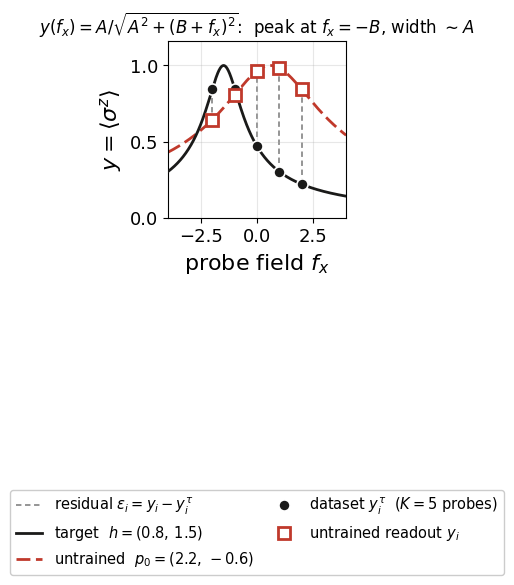

In [2]:
# --- response_fit_setup: the fit that training solves (analytic, no evolution) ---------------
HFIT  = jnp.array([0.8, 1.5])     # target h: narrow response, peak at f_x = -1.5
PFIT  = jnp.array([2.2, -0.6])    # untrained p0: broad response, peak at f_x = +0.6
# Probe set as in the Figures 14-15 sweep: "K5" = -2,-1,0,1,2 (swap for K3 = -1,0,1).
FXS_F = jnp.array([-2.0, -1.0, 0.0, 1.0, 2.0])
fg_F  = jnp.linspace(-4.0, 4.0, 601)                   # plotting grid, wider than the probes

y_tau_g, y_p_g = qep.y_analytic(HFIT, fg_F), qep.y_analytic(PFIT, fg_F)
y_tau_s, y_p_s = qep.y_analytic(HFIT, FXS_F), qep.y_analytic(PFIT, FXS_F)

fig, ax = plt.subplots(figsize=(2.3, 2.3), layout="constrained")
# residual connectors first, so both curves and both marker sets sit on top of them
for k, (f, yt, yp) in enumerate(zip(FXS_F, y_tau_s, y_p_s)):
    ax.plot([f, f], [yt, yp], ls=(0, (3, 2)), color="0.55", lw=1.3, zorder=1,
            label=r"residual $\epsilon_i=y_i-y^\tau_i$" if k == 0 else None)
ax.plot(fg_F, y_tau_g, "-", color=INK, zorder=3,
        label=r"target  $h=(%.1f,\,%.1f)$" % (HFIT[0], HFIT[1]))
ax.plot(fg_F, y_p_g, ls=DASH["linear"], color=C["linear"], zorder=2,
        label=r"untrained  $p_0=(%.1f,\,%.1f)$" % (PFIT[0], PFIT[1]))
ax.plot(FXS_F, y_tau_s, "o", color=INK, ms=8, mec="w", mew=1.2, zorder=5,
        label=r"dataset $y^\tau_i$  ($K=%d$ probes)" % len(FXS_F))
ax.plot(FXS_F, y_p_s, "s", color="w", mec=C["linear"], mew=2.0, ms=8, zorder=5,
        label=r"untrained readout $y_i$")
ax.set_xlabel(r"probe field $f_x$")
ax.set_ylabel(r"$y=\langle\sigma^z\rangle$")
ax.set_xlim(fg_F[0], fg_F[-1]); ax.set_ylim(0, 1.16)   # headroom for the legend strip
ax.legend(loc="upper center", ncol=2, framealpha=1.0, fontsize=10.5,
          borderaxespad=0.4, columnspacing=1.2, handlelength=1.8, bbox_to_anchor=(0.5, -1.5))
ax.set_title(r"$y(f_x)=A/\sqrt{A^2+(B+f_x)^2}$:  peak at $f_x=-B$, width $\sim A$", fontsize=12)
save(fig, "response_fit_setup")

print("probes f_x =", np.array(FXS_F))
print("target    peak at f_x=%+.2f,  sampled y in [%.2f, %.2f]"
      % (-HFIT[1], y_tau_s.min(), y_tau_s.max()))
print("untrained peak at f_x=%+.2f,  sampled y in [%.2f, %.2f]"
      % (-PFIT[1], y_p_s.min(), y_p_s.max()))
print("residuals eps_i =", np.round(np.array(y_p_s - y_tau_s), 3))
print("initial cost C = 1/2 sum (y_i - y^tau_i)^2 = %.3f"
      % (0.5 * float(jnp.sum((y_p_s - y_tau_s) ** 2))))